# Statistics for Michel electron candidate

# cosmic DATA 28116

### Created by Shu, 202510---

### Based on new20251205; the main difference is #opWVF>=3 instead of 4

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


import os

# ------------------------------------------------------------
# 1️⃣ Define which dates to include
# ------------------------------------------------------------
dates = ["20251205"]  # ✅ modify as needed

coinNum = []     # waveform coincidence numbers


# ------------------------------------------------------------
# 2️⃣ Read waveform coincidence counts
# ------------------------------------------------------------
for d in dates:
    fname = f"./statResult_pds/print_wvfCoin_count{d}.txt"
    if not os.path.exists(fname):
        print(f"[WARN] File not found: {fname}")
        continue

    with open(fname, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.split(":")
            if len(parts) >= 2:
                try:
                    number = int(parts[1].strip())
                    coinNum.append(number)
                except ValueError:
                    print(f"[WARN] Could not convert '{parts[1].strip()}' in {fname} to an integer.")








# ------------------------------------------------------------
# ✅ Summary
# ------------------------------------------------------------


print("Track candidates (TPC cut)  : 21773")
print("Track candidates with NO wvf: 3291")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * (88+95))



Track candidates (TPC cut)  : 21773
Track candidates with NO wvf: 3291
Number of track candidates  : 19814



Candidates with #opWvf>=4:  16120 / 19814 (81.36%)


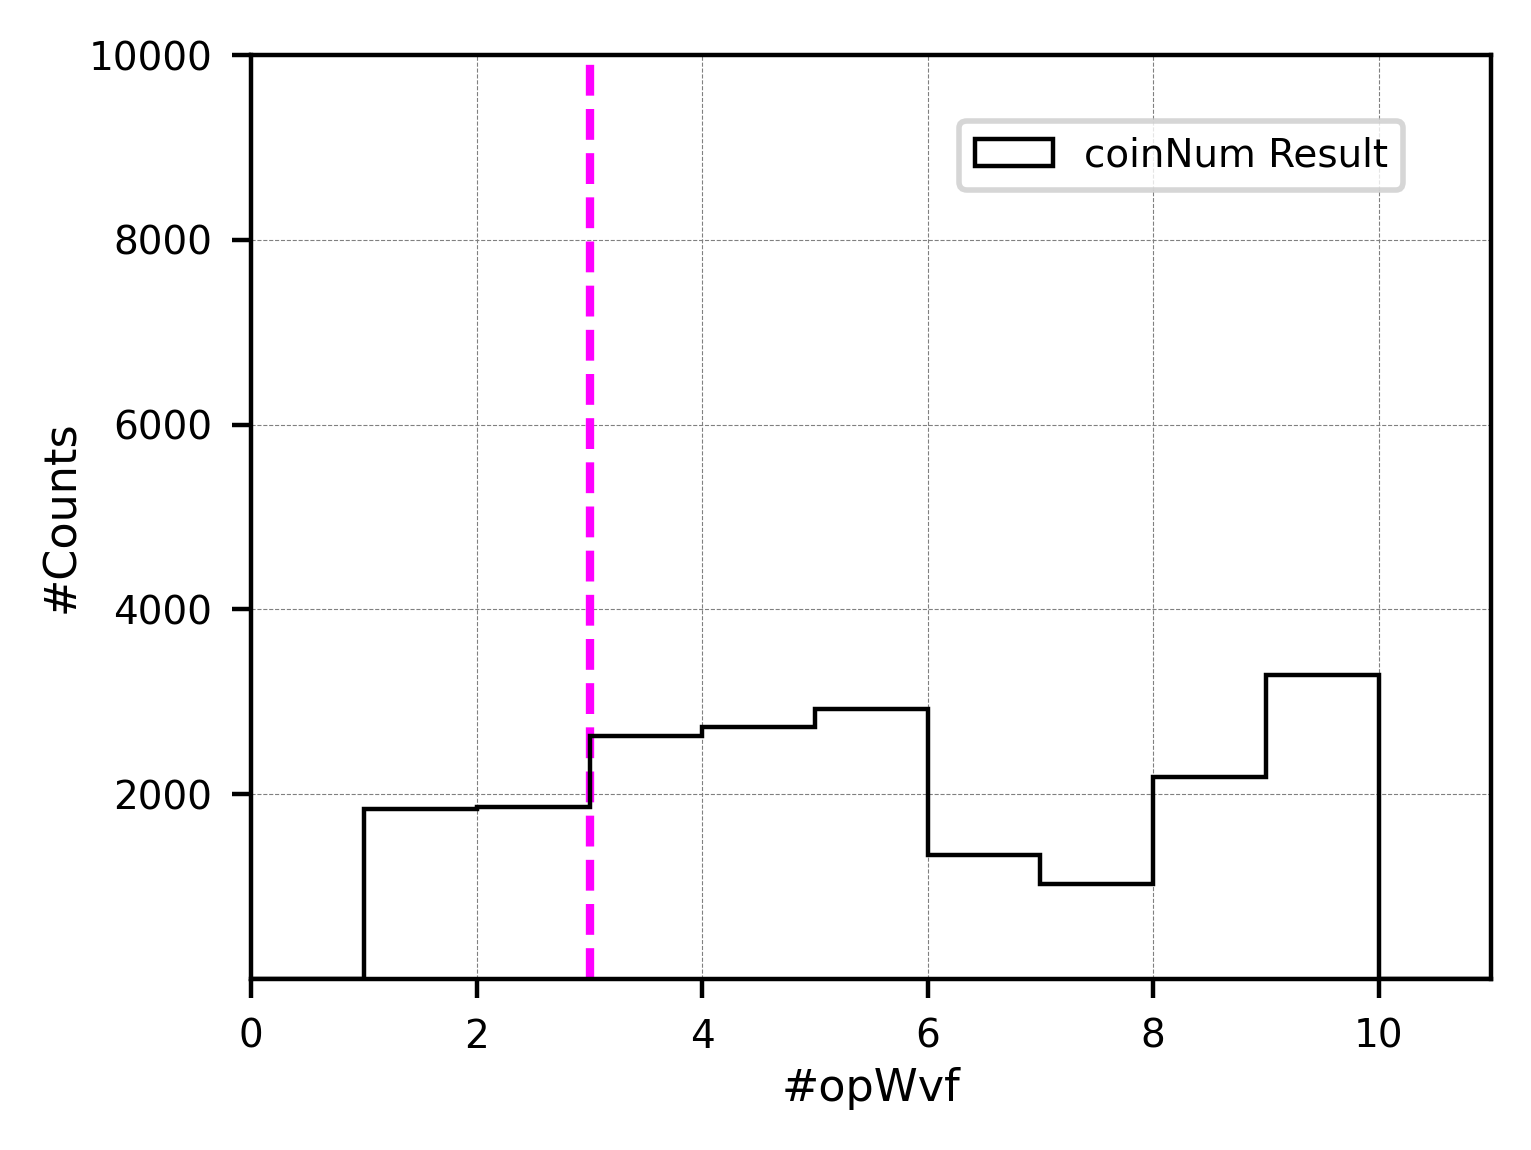

In [3]:
#Apply preliminary cut #opWvf >=3:=====================
coinNum_cut4 = []
coinNum_trueE_cut4 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]

    if coin >=3:
        coinNum_cut4.append(coin)

print("\nCandidates with #opWvf>=4: ", len(coinNum_cut4), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut4)/len(coinNum)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([3, 3], [0, 15000], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')

plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 3) (This can be taken as "PDS Cut 1")

In [4]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import re
from mpl_toolkits.mplot3d import Axes3D



# ------------------- Dataclass -------------------
@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    third_time: Optional[int] = None             # NEW
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None      # NEW
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None
    # muon
    mu_leftTurn: Optional[int] = None
    mu_rightTurn: Optional[int] = None
    mu_leftHeight: Optional[float] = None
    mu_rightHeight: Optional[float] = None
    # michel
    mi_leftTurn: Optional[int] = None
    mi_rightTurn: Optional[int] = None
    mi_leftHeight: Optional[float] = None
    mi_rightHeight: Optional[float] = None
    # third peak
    th_leftTurn: Optional[int] = None            # NEW
    th_rightTurn: Optional[int] = None           # NEW
    th_leftHeight: Optional[float] = None        # NEW
    th_rightHeight: Optional[float] = None       # NEW
    # Michel-level attributes
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None            # ✅ NEW



# ------------------- Helpers -------------------
def parse_event_track(path_str: str):
    """Extract eventID and trackID from a file path string."""
    m = re.search(r"event(\d+)_trackID(\d+)", path_str)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None



def read_total_files(files, dates, kind="muon"):
    """
    Read *_total_xxx.txt files.
    Each line: path: t, I, leftTurn, leftHeight, rightTurn, rightHeight
    """
    records = []
    for fname, date in zip(files, dates):
        try:
            with open(fname, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) < 2:
                        continue

                    path_part = parts[0].strip()
                    values = [v.strip() for v in parts[1].split(",")]
                    if len(values) < 6:
                        print(f"[WARN] Malformed line in {fname}: {line}")
                        continue

                    try:
                        time_val = int(values[0])
                        inten_val = float(values[1])
                        left_turn = int(values[2])
                        left_h = float(values[3])
                        right_turn = int(values[4])
                        right_h = float(values[5])
                    except ValueError:
                        print(f"[WARN] Could not parse numbers in {line}")
                        continue

                    evID, trID = parse_event_track(path_part)
                    rec = {"eventID": evID, "trackID": trID, "date": int(date)}

                    if kind == "muon":
                        rec.update({
                            "muon_time": time_val,
                            "muon_intensity": inten_val,
                            "mu_leftTurn": left_turn,
                            "mu_leftHeight": left_h,
                            "mu_rightTurn": right_turn,
                            "mu_rightHeight": right_h
                        })
                    elif kind == "michel":
                        rec.update({
                            "michel_time": time_val,
                            "michel_intensity": inten_val,
                            "mi_leftTurn": left_turn,
                            "mi_leftHeight": left_h,
                            "mi_rightTurn": right_turn,
                            "mi_rightHeight": right_h
                        })
                    elif kind == "third":
                        rec.update({
                            "third_time": time_val,
                            "third_intensity": inten_val,
                            "th_leftTurn": left_turn,
                            "th_leftHeight": left_h,
                            "th_rightTurn": right_turn,
                            "th_rightHeight": right_h
                        })

                    records.append(rec)
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return records




def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values



# ------------------- Load data -------------------
dates = ["20251205"]

muon_files   = [f"./statResult_pds/muon_total_{d}.txt" for d in dates]
michel_files = [f"./statResult_pds/michel_total_{d}.txt" for d in dates]
third_files  = [f"./statResult_pds/third_total_{d}.txt" for d in dates]

muon_records   = read_total_files(muon_files, dates, kind="muon")
michel_records = read_total_files(michel_files, dates, kind="michel")
third_records  = read_total_files(third_files, dates, kind="third")

# --- plain text attributes ---
posX     = read_plain_files([f"./statResult_pds/posX_extract_{d}.txt" for d in dates])
posY     = read_plain_files([f"./statResult_pds/posY_extract_{d}.txt" for d in dates])
posZ     = read_plain_files([f"./statResult_pds/posZ_extract_{d}.txt" for d in dates])
miScore  = read_plain_files([f"./statResult_pds/michelScore_extract_{d}.txt" for d in dates])
miHits   = read_plain_files([f"./statResult_pds/michelHits_extract_{d}.txt" for d in dates], cast_type=int)



# ------------------- Build dataset -------------------
events_veryInitial = []
n_events = min(
    len(muon_records), len(michel_records), len(third_records),
    len(posX), len(posY), len(posZ),
    len(miScore), len(miHits)
)

for i in range(n_events):
    rec_mu = muon_records[i]
    rec_mi = michel_records[i]
    rec_th = third_records[i]

    ev = PdsEvent(
        eventID=rec_mu.get("eventID", rec_mi.get("eventID", rec_th.get("eventID"))),
        trackID=rec_mu.get("trackID", rec_mi.get("trackID", rec_th.get("trackID"))),
        date=rec_mu.get("date", rec_mi.get("date", rec_th.get("date"))),

        # muon
        muon_time=rec_mu.get("muon_time"),
        muon_intensity=rec_mu.get("muon_intensity"),
        mu_leftTurn=rec_mu.get("mu_leftTurn"),
        mu_leftHeight=rec_mu.get("mu_leftHeight"),
        mu_rightTurn=rec_mu.get("mu_rightTurn"),
        mu_rightHeight=rec_mu.get("mu_rightHeight"),

        # michel
        michel_time=rec_mi.get("michel_time"),
        michel_intensity=rec_mi.get("michel_intensity"),
        mi_leftTurn=rec_mi.get("mi_leftTurn"),
        mi_leftHeight=rec_mi.get("mi_leftHeight"),
        mi_rightTurn=rec_mi.get("mi_rightTurn"),
        mi_rightHeight=rec_mi.get("mi_rightHeight"),
        michel_score=miScore[i],
        michel_hits=miHits[i],

        # third
        third_time=rec_th.get("third_time"),
        third_intensity=rec_th.get("third_intensity"),
        th_leftTurn=rec_th.get("th_leftTurn"),
        th_leftHeight=rec_th.get("th_leftHeight"),
        th_rightTurn=rec_th.get("th_rightTurn"),
        th_rightHeight=rec_th.get("th_rightHeight"),

        # physical properties
        posX=posX[i], posY=posY[i], posZ=posZ[i]
    )
    events_veryInitial.append(ev)

print("Very initial dataset:", len(events_veryInitial))

example = events_veryInitial[0]
print("\nExample Event (index 0):")
for field, value in vars(example).items():
    print(f"  {field:20s}: {value}")









#Apply cuts on peak intensities-----------------------------
events_reco_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity

    ms = ev.michel_score
    mh = ev.michel_hits

    if muIntensity > 0.3  and miIntensity > -0.1 and ms > 0.3 and mh > 3:#mu & mi are cuts in following block already!
        events_reco_initial.append(ev)


print("\nDataset after initial intensity-cut----------------------")
print("Michel initial dataset   : ", len(events_reco_initial))






Very initial dataset: 16120

Example Event (index 0):
  muon_time           : 58
  michel_time         : 230
  third_time          : 128
  muon_intensity      : 7.8207
  michel_intensity    : 2.06045
  third_intensity     : 0.500291
  posX                : -127.796
  posY                : 344.023
  posZ                : 348.168
  eventID             : 100017
  trackID             : 4
  date                : 20251205
  mu_leftTurn         : 36
  mu_rightTurn        : 82
  mu_leftHeight       : 9.89513
  mu_rightHeight      : 7.8207
  mi_leftTurn         : 213
  mi_rightTurn        : 263
  mi_leftHeight       : 2.30839
  mi_rightHeight      : 2.06045
  th_leftTurn         : 112
  th_rightTurn        : 159
  th_leftHeight       : 0.500291
  th_rightHeight      : 1.09959
  michel_score        : 0.499263
  michel_hits         : 19

Dataset after initial intensity-cut----------------------
Michel initial dataset   :  12761


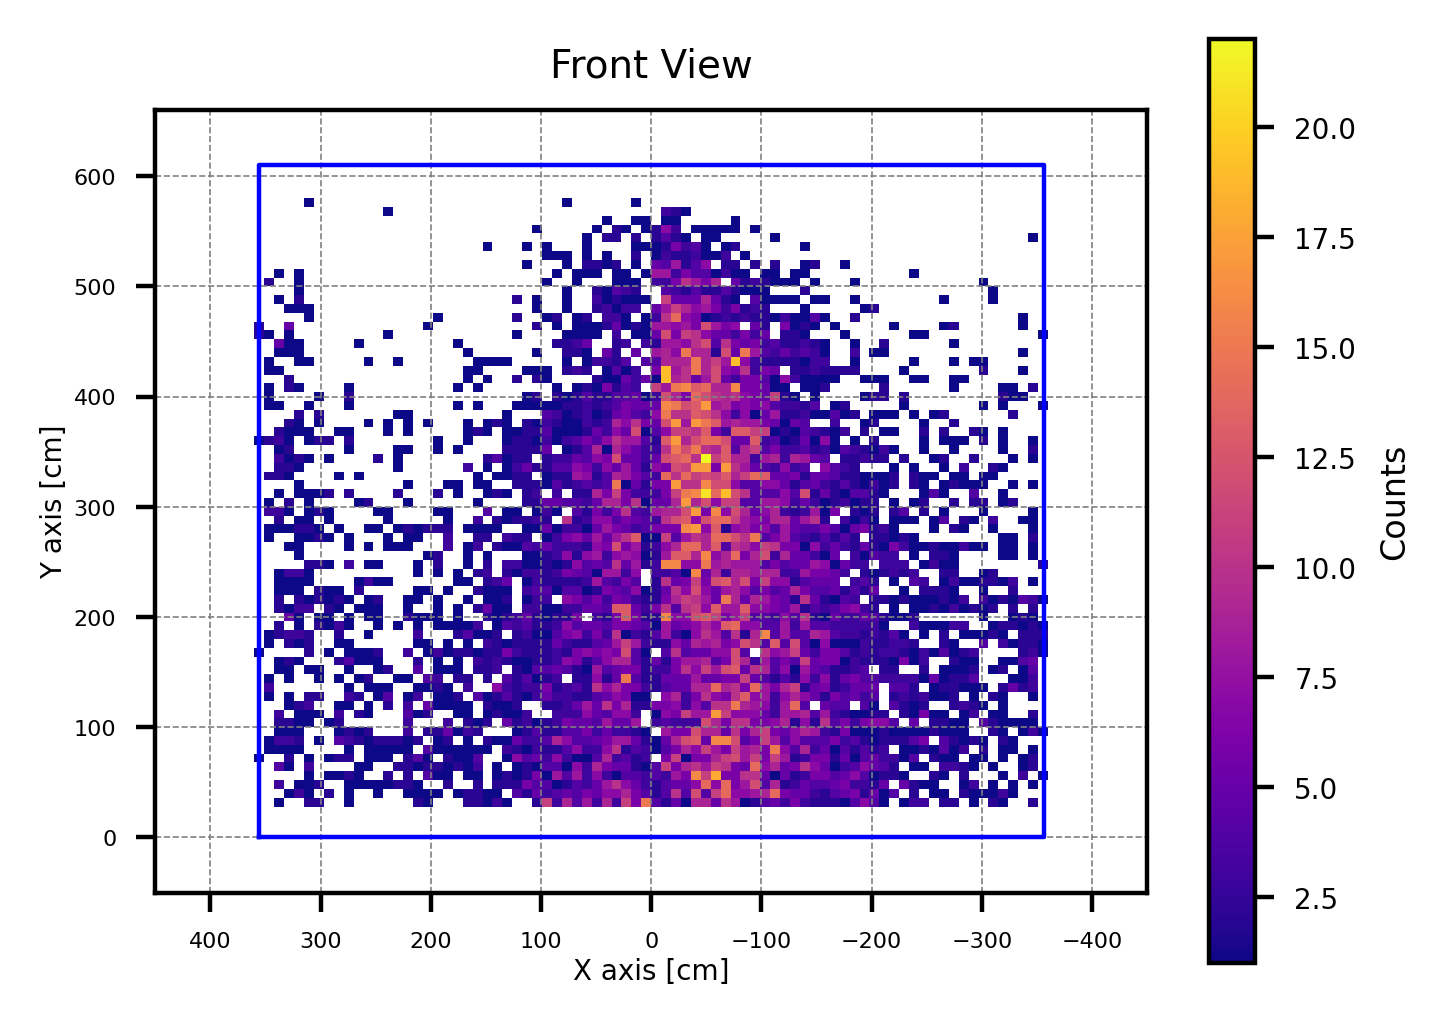

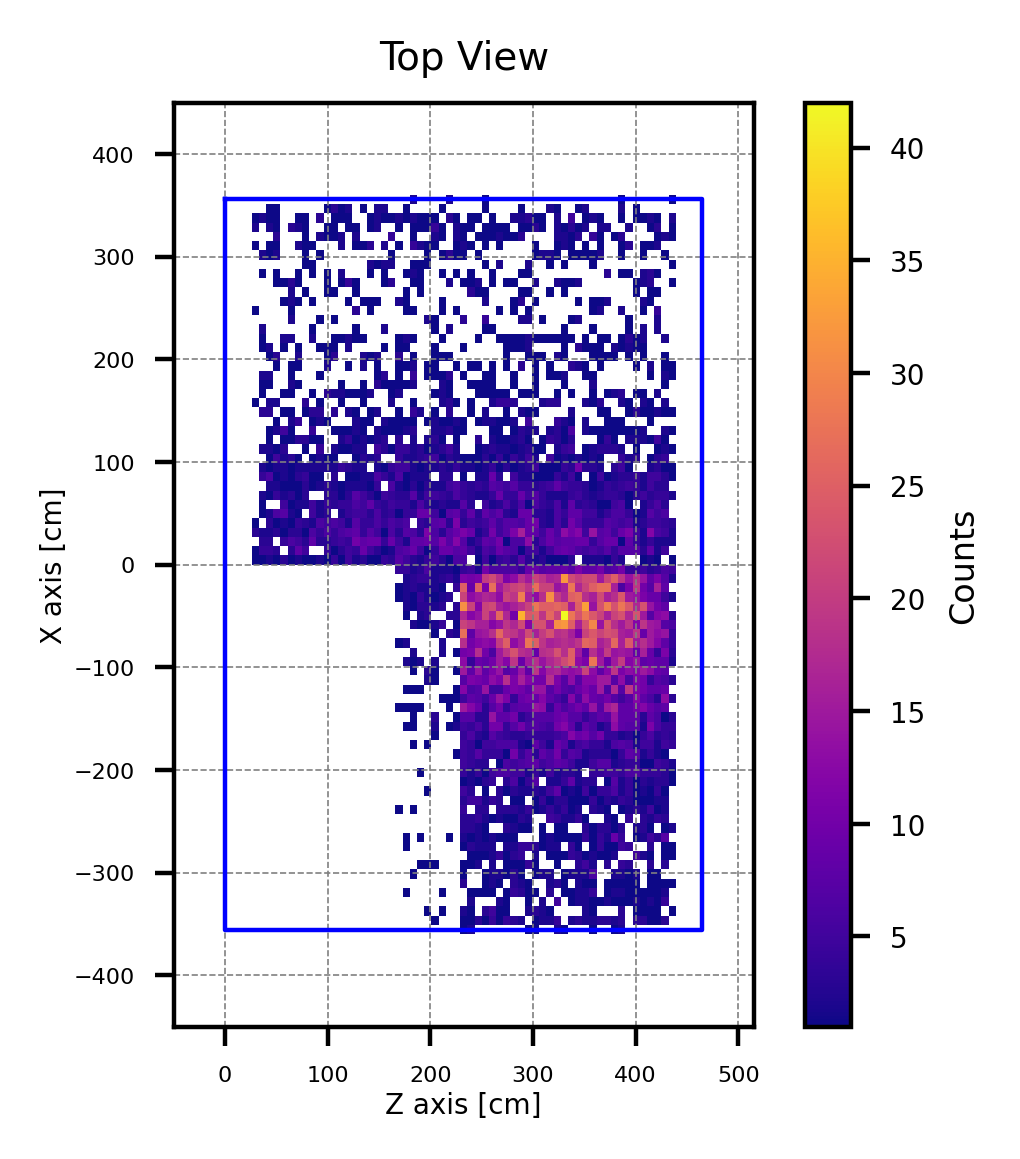


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  8939 (70.05%)
# of X >= 0:  3822 (29.95%)


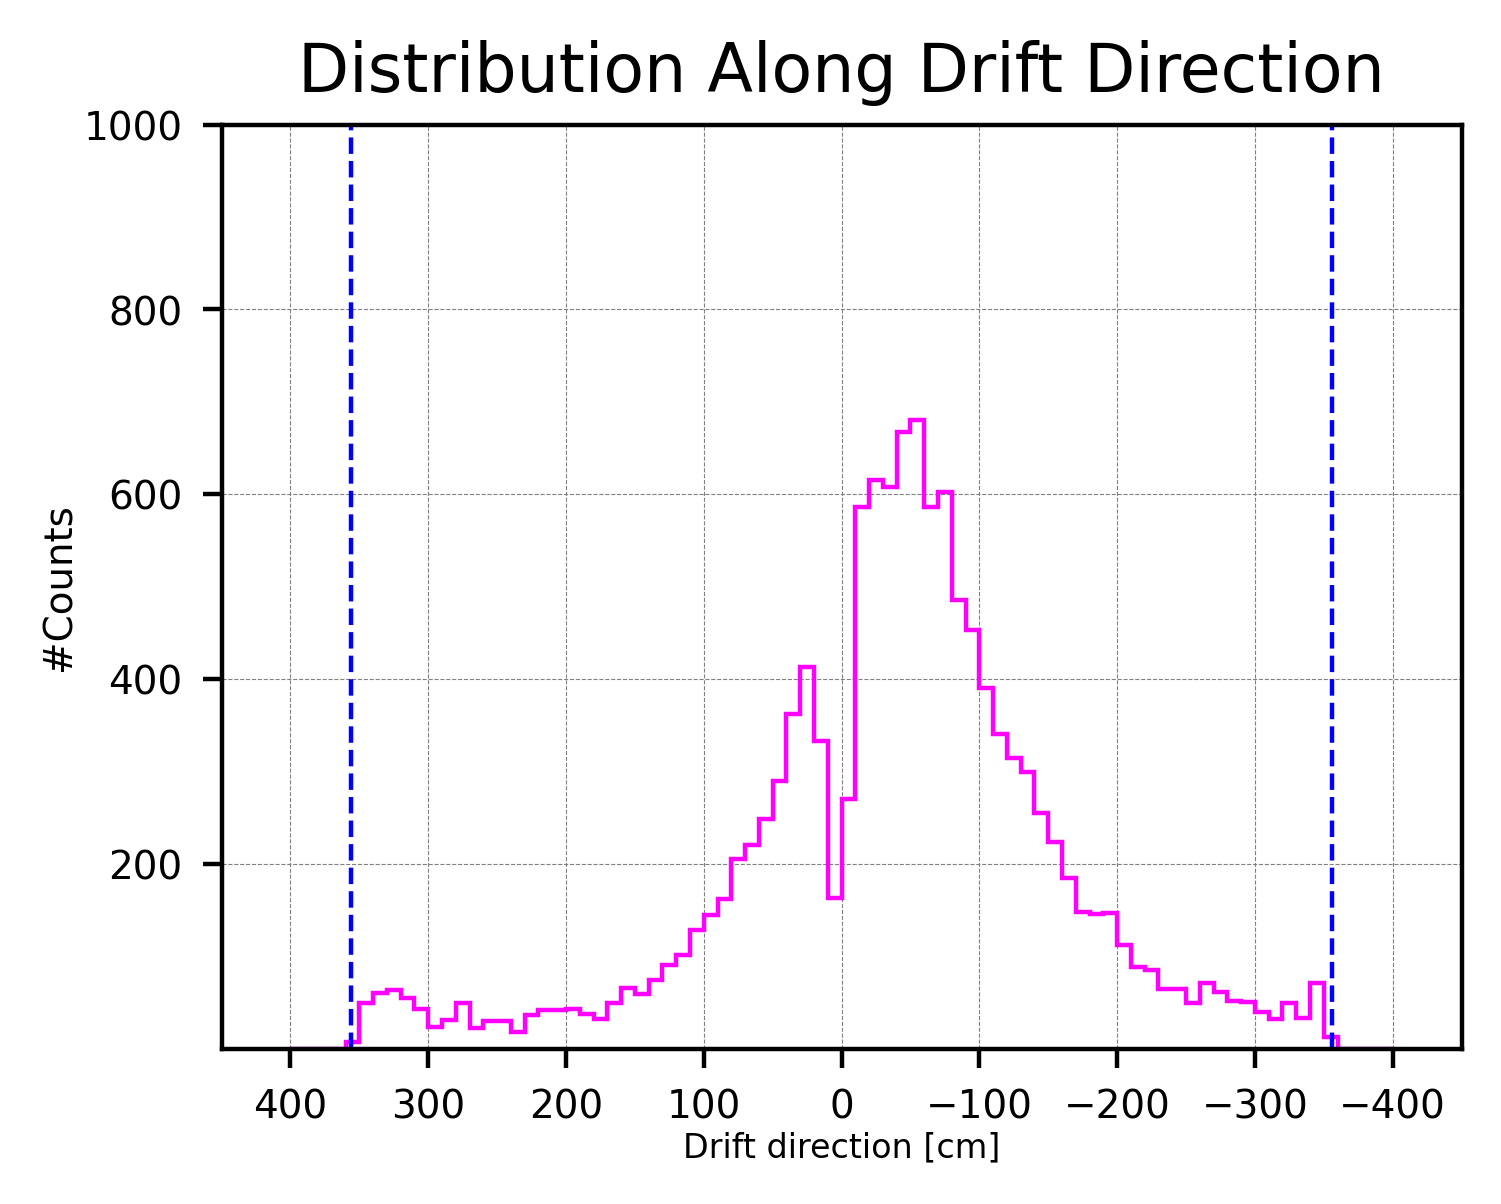

In [5]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))      




#============================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(posX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')


plt.xlim(-450, 450)
plt.xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylabel('#Counts', labelpad=1, fontsize=7)
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution Along Drift Direction', fontsize=12)
plt.show()  






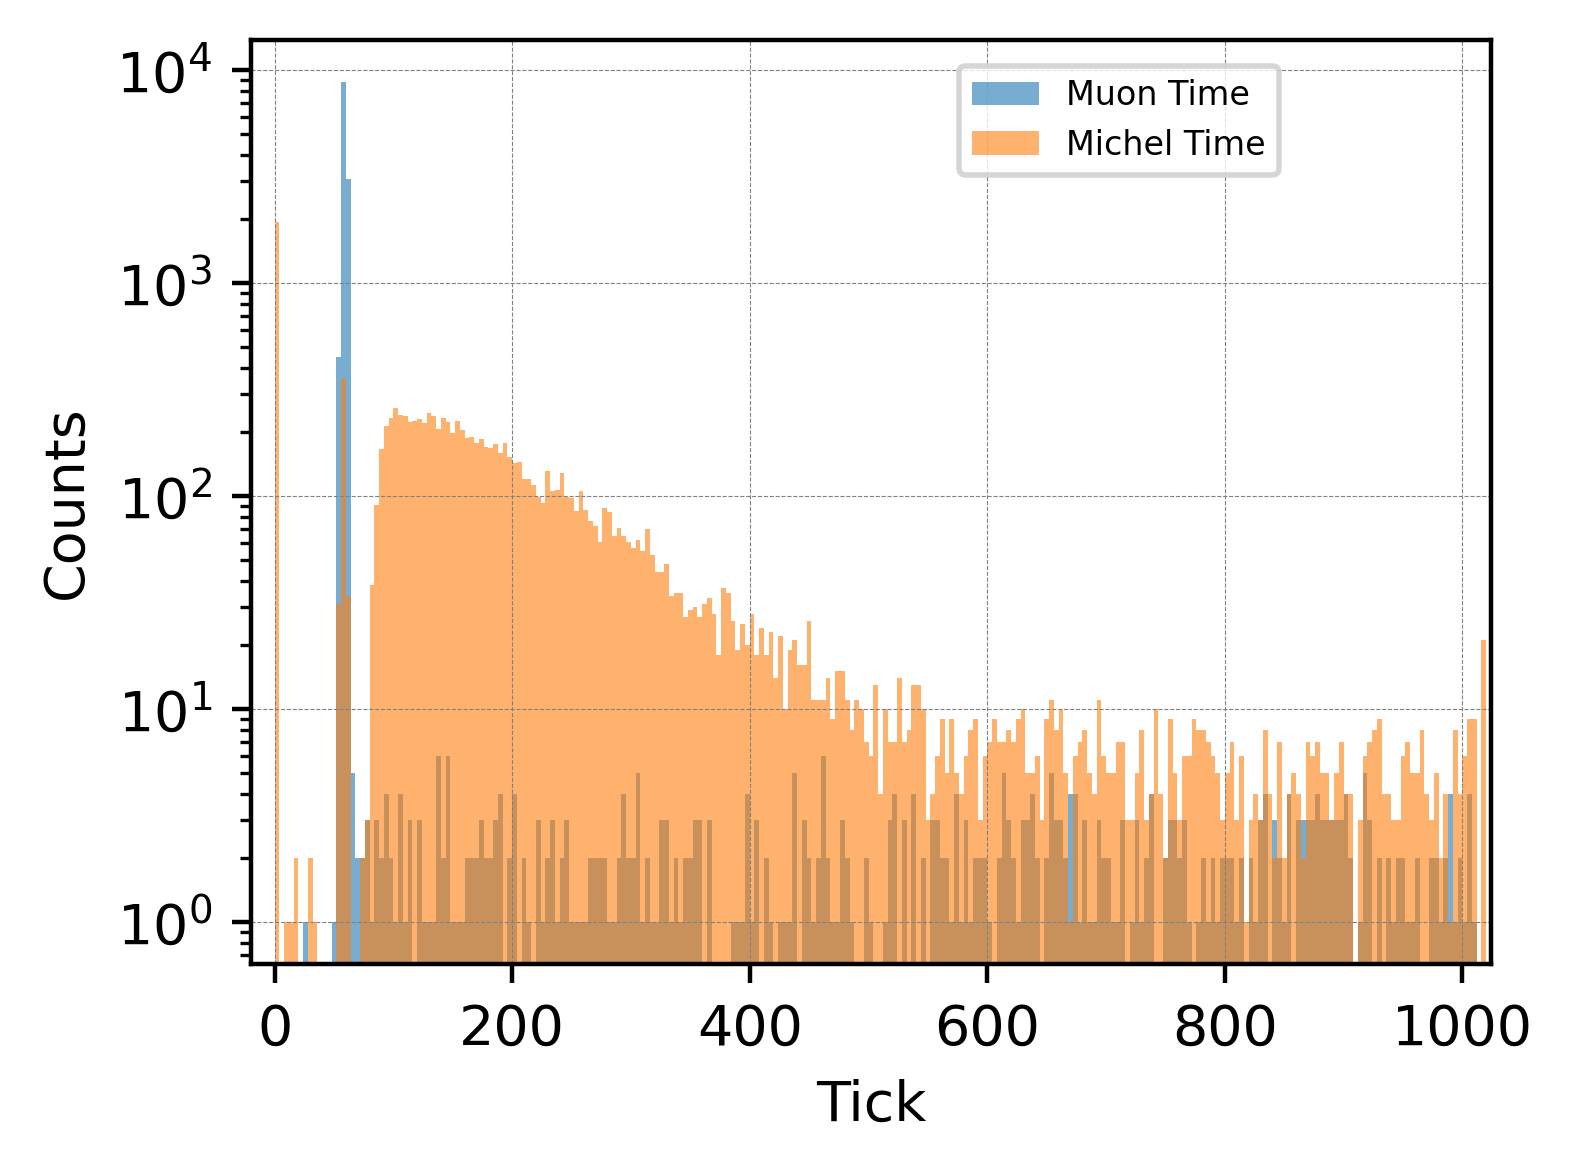

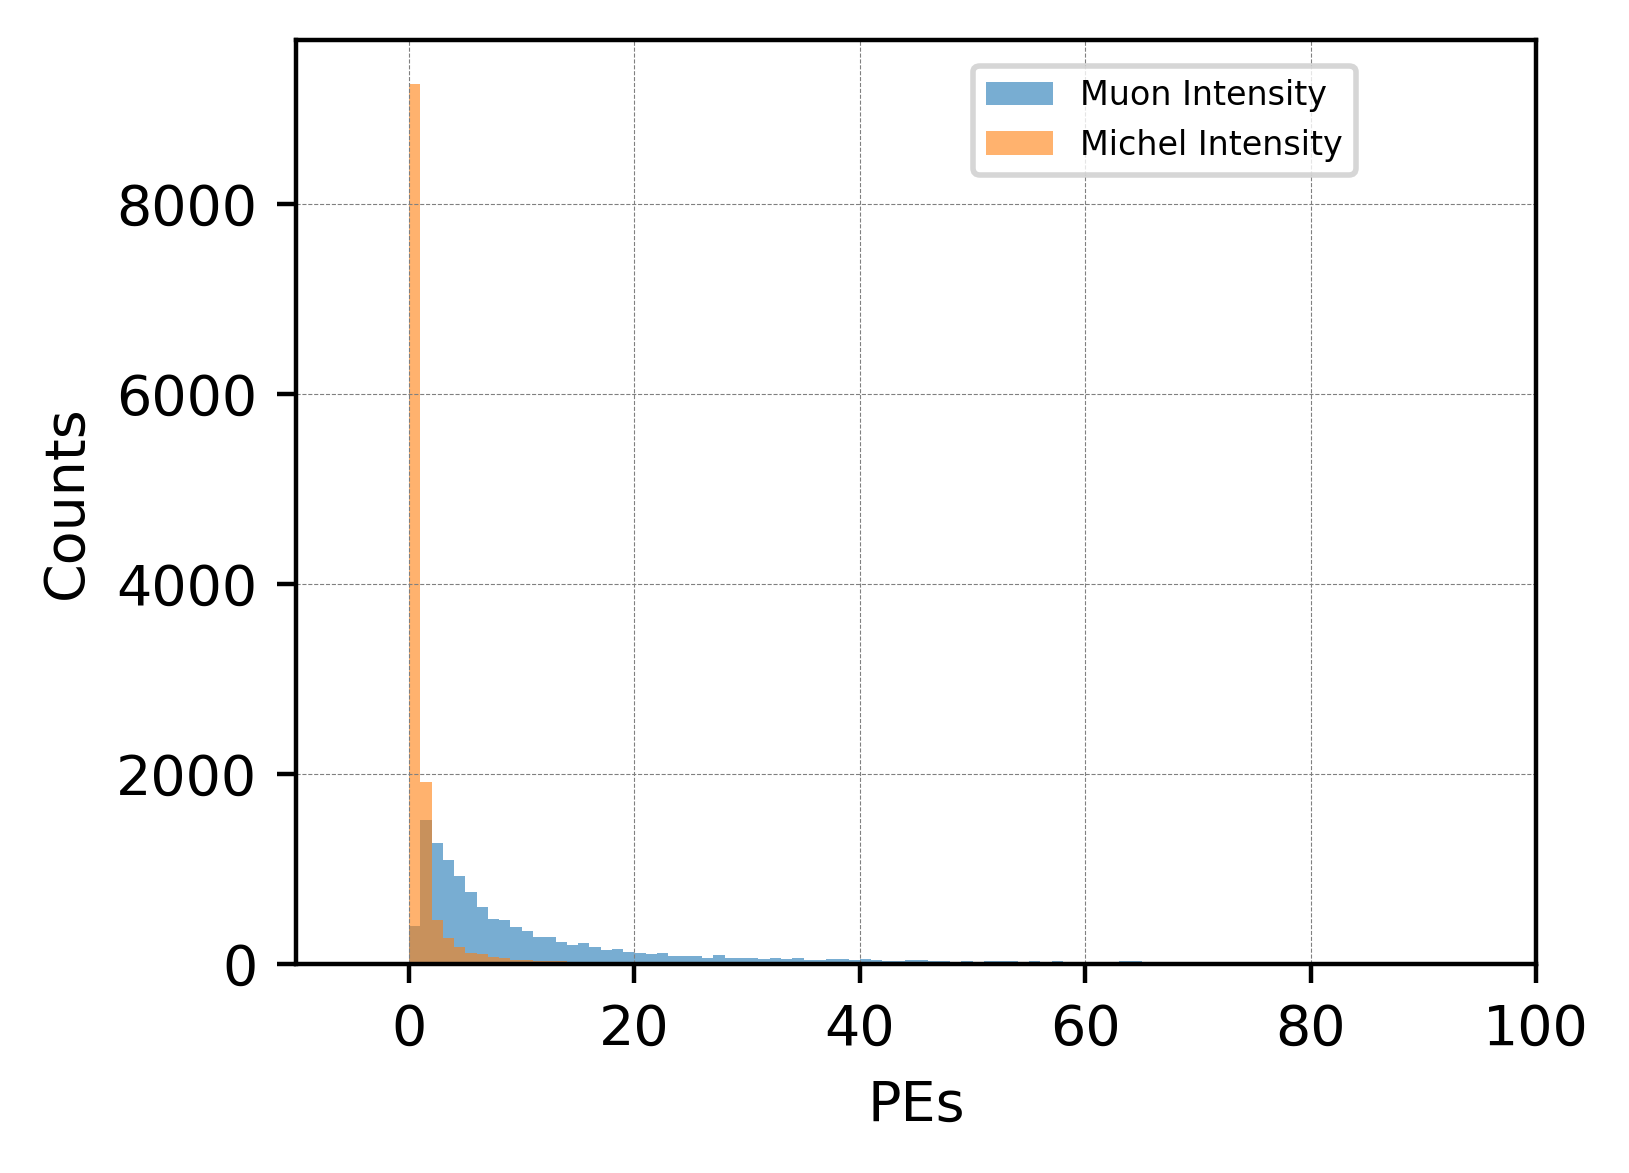

In [6]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]



#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
#plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
#plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









 





<br />
<br />
<br />
<br />


### Purification / cut 2: remove abnormal muon signals (constrain muTime to [50, 65])

Muon events selection (mu peak constrained to [50, 65]):
Updated Muon events:  12308 / 12761 (96.45%)
Length of time_difference (Updated):  12308
Adding muTIme < miTime:
Updated Muon events:  10367 / 12761 (81.24%)


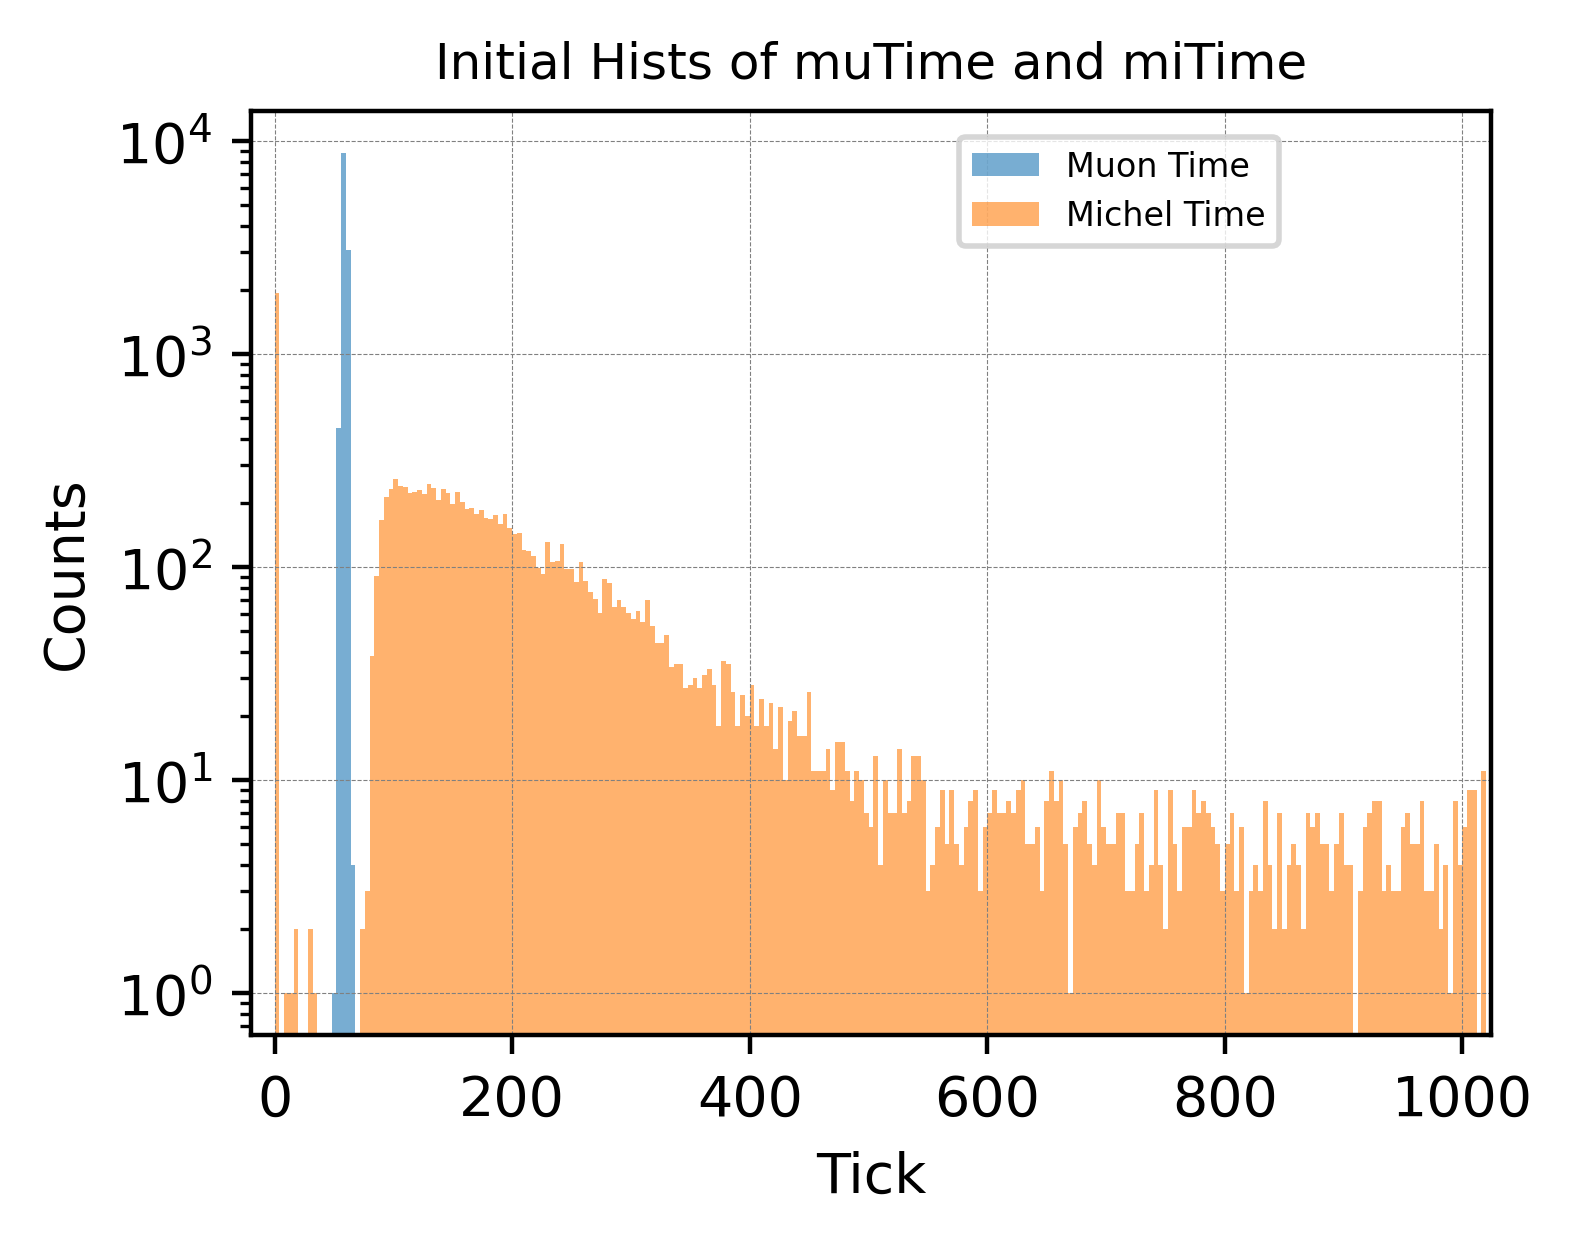

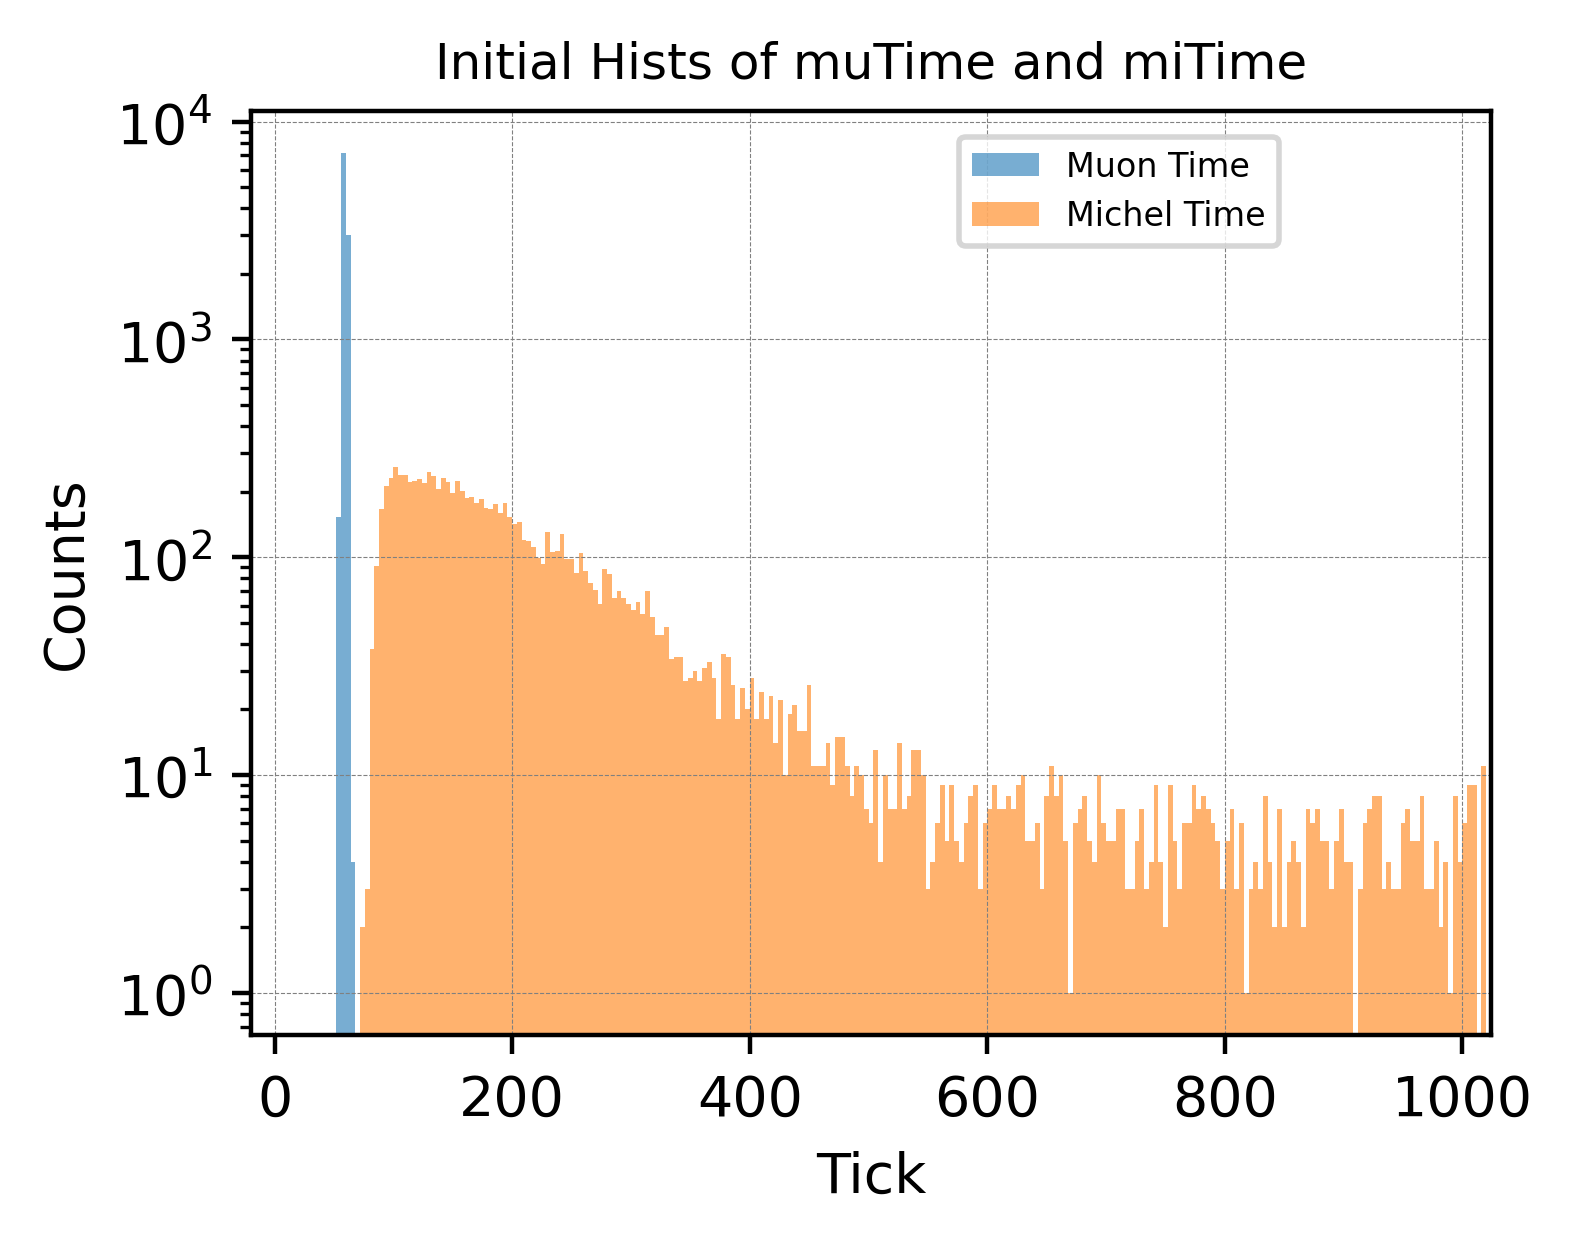




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  12308


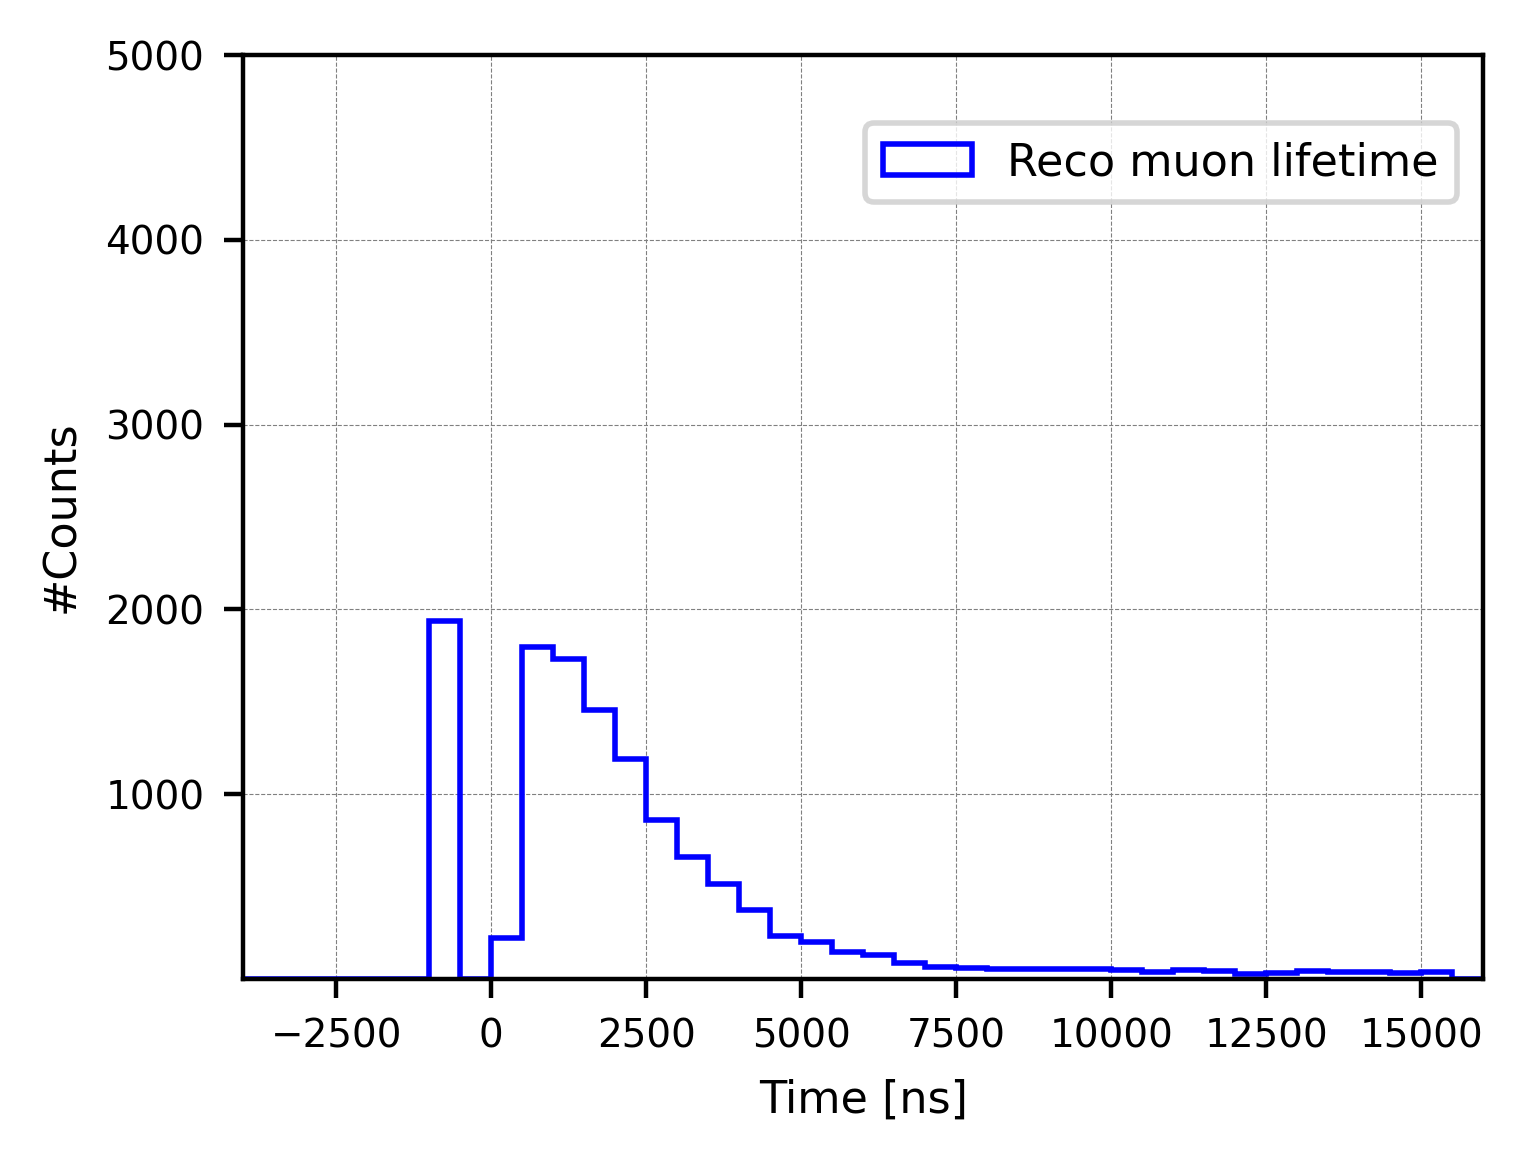

In [29]:
events_reco_update1 = []

lifetime_reco_update1 = []

events_reco_update1X = []


for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time

    if 50 <= muTime <= 65:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)

        if muTime < miTime:
            events_reco_update1X.append(ev)


print("Muon events selection (mu peak constrained to [50, 65]):")
print("Updated Muon events: ", len(events_reco_update1), "/", len(events_reco_initial),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))


print("Adding muTIme < miTime:")
print("Updated Muon events: ", len(events_reco_update1X), "/", len(events_reco_initial),
       "({:.2f}%)".format(len(events_reco_update1X)/len(events_reco_initial)*100))








#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()








#Initial_X Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1X]
miTime_update = [ev.michel_time for ev in events_reco_update1X]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---



print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(-4000, 16000)
plt.ylim(0.9, 5000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification / cut 3: remove events with unphysical lifetime (constrain lifetime to [500, inf))

#### (20251022): lifetime cut should be >0 here (we know later that 500 is NOT a good standard)




Lifetime distribution (Updated):
# Updated Candidates [0, 16000]:  10367


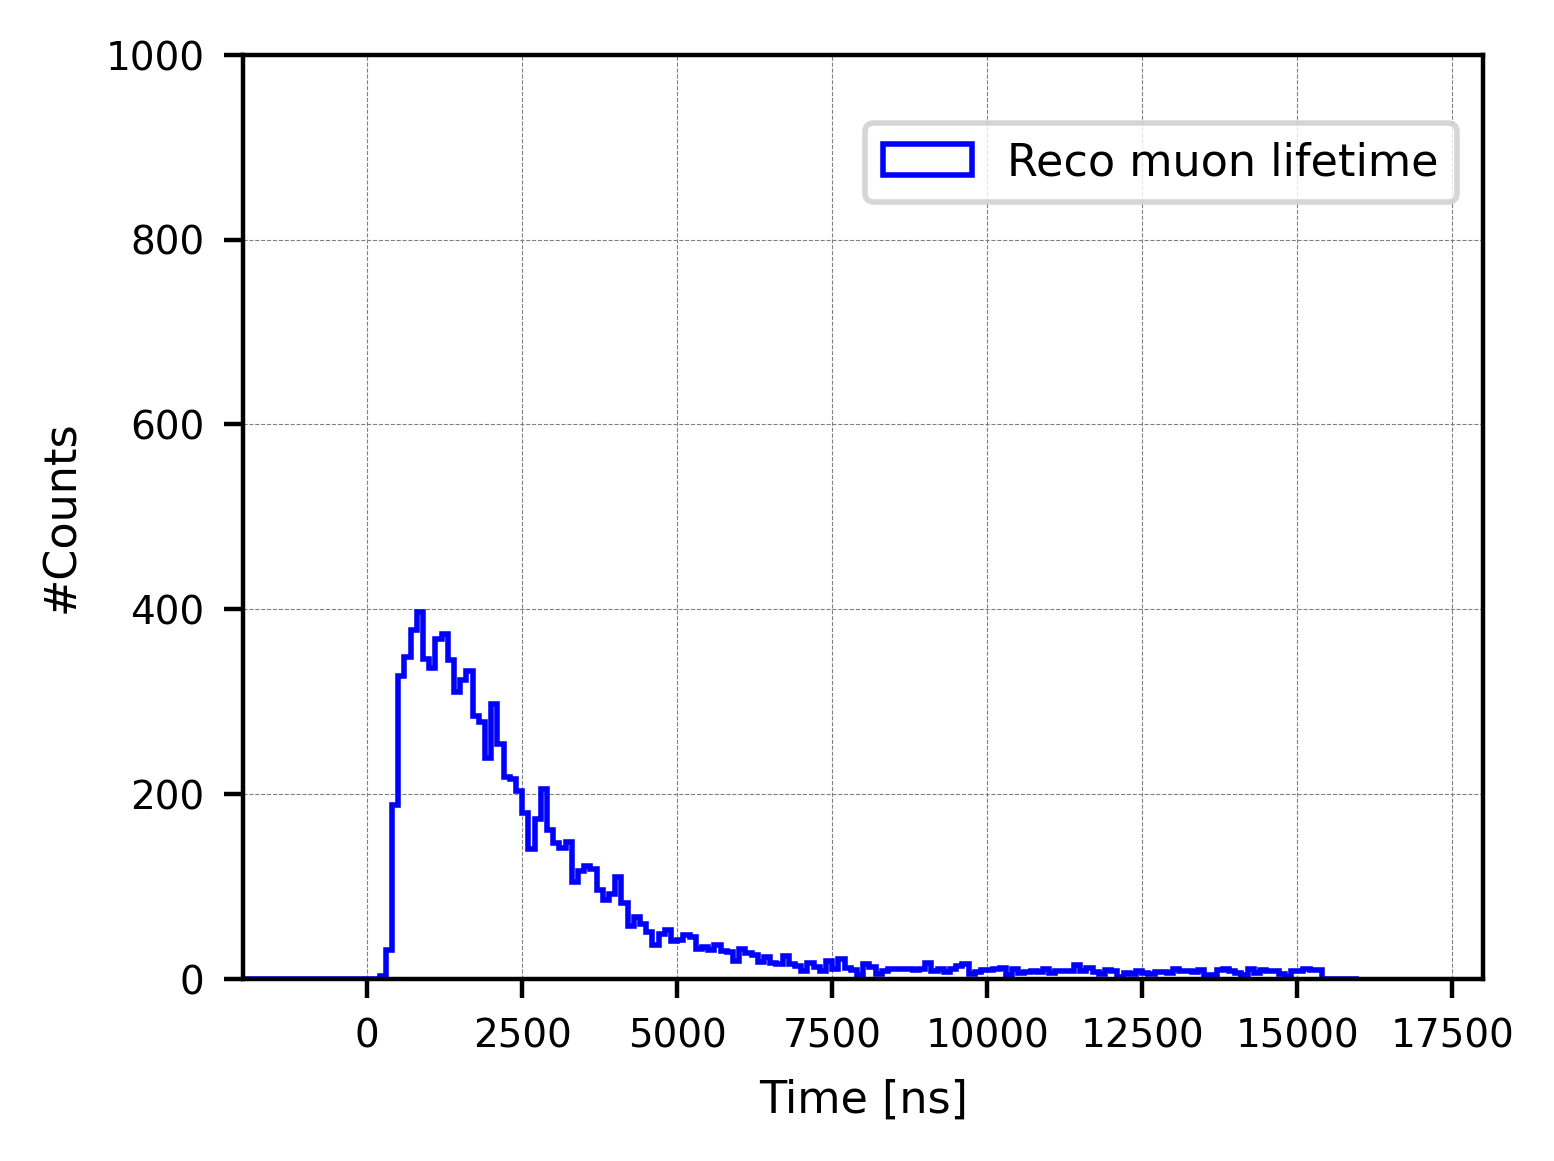

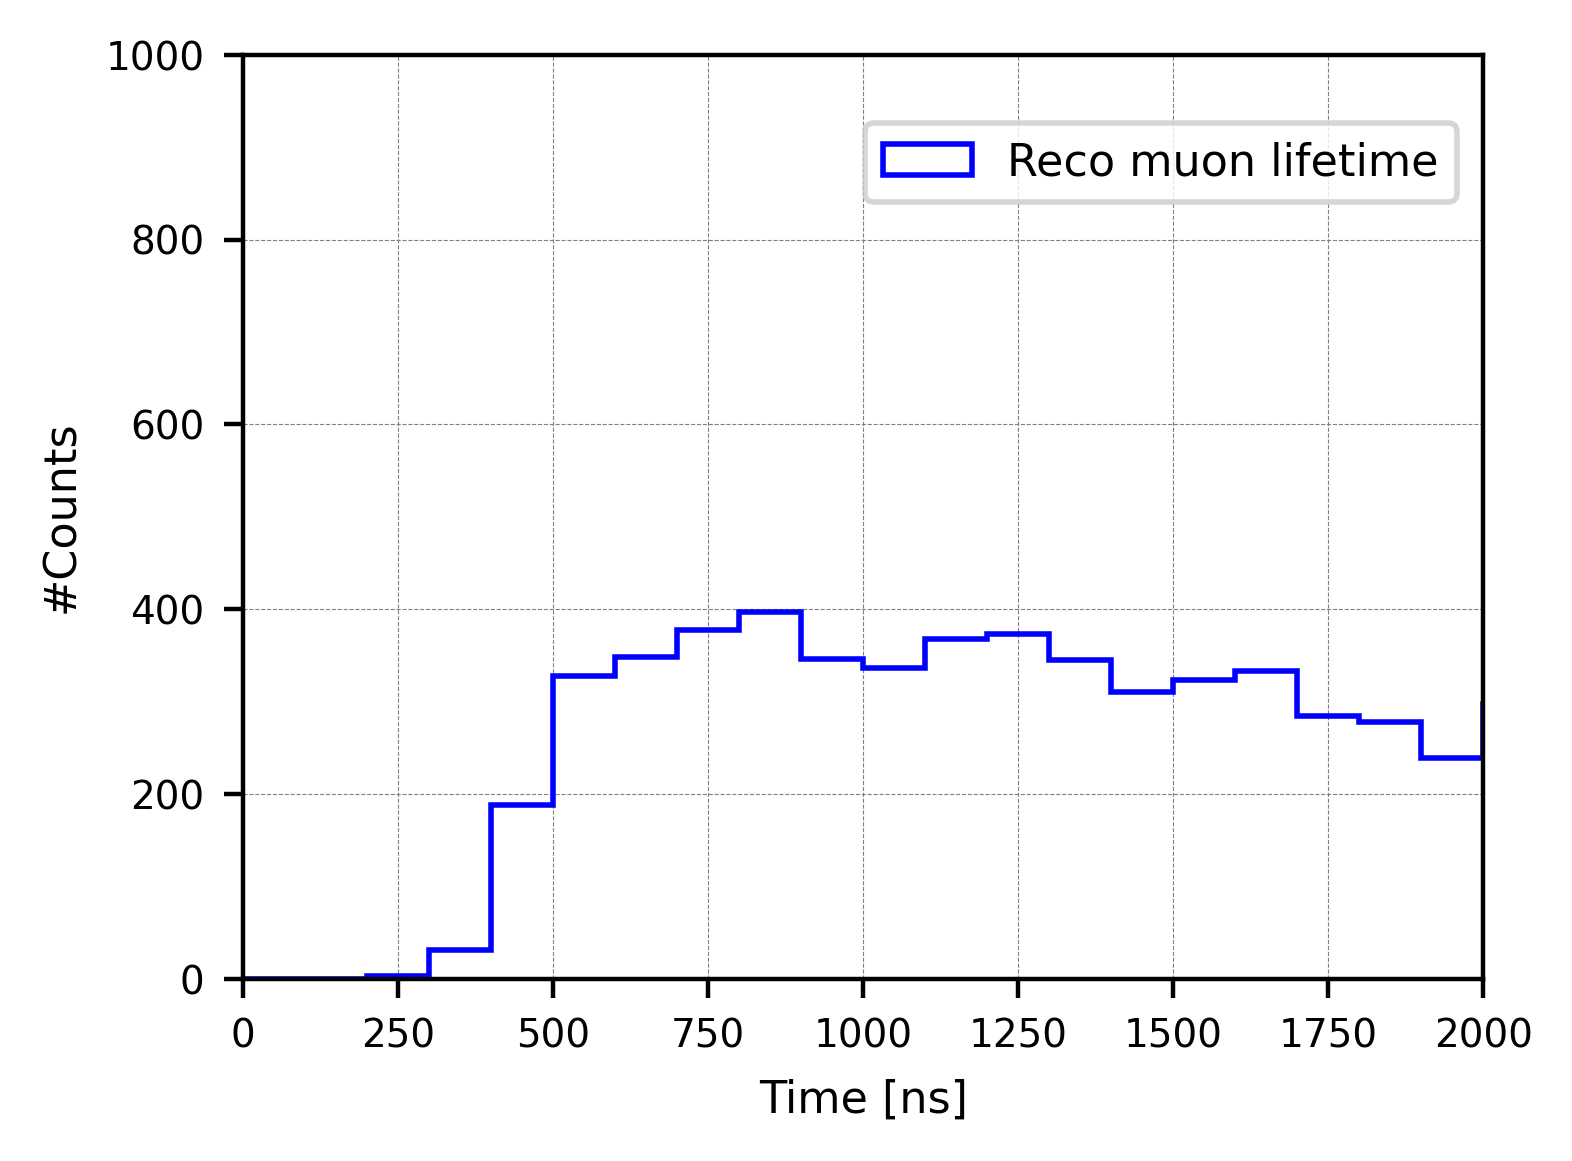

In [31]:
events_reco_update2 = []#Dataset after Purification 2---
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    if 0 <= timeDiff: #keep physical events here---
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [0, 16000]: ", len(events_reco_update2))






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

#plt.plot([-2000, 20000], [5, 5], color="green", linewidth=0.8, linestyle='--', label='y = 5')
#plt.plot([-2000, 20000], [10, 10], color="magenta", linewidth=0.8, linestyle='--', label='y = 10')

plt.xlim(-2000, 18000)
plt.ylim(0, 1000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()









# zoomed-in plot--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(0, 2000)
plt.ylim(0, 1000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Explore Dataset After purification 3 [RecoT>0]:

In [9]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None 
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None 
    reco_lifetime: Optional[float] = None
    michel_rise: Optional[float] = None
    michel_drop: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))



#Rise is intensity related: rise ~ intensity / time; 20251207---
#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45



#New calculated reco & true lifetime lists:
recoLife_update2 = []

michel_rise_slope = []
michel_drop_slope = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)

#    left_slope = ev.mi_leftHeight / (miTime - ev.mi_leftTurn)
#    right_slope = ev.mi_rightHeight / (ev.mi_rightTurn - miTime)
    left_slope = (2.5 * ev.mi_leftHeight - 0.45) / (miTime - ev.mi_leftTurn) #20251207---
    right_slope = (2.5 * ev.mi_rightHeight - 0.45) / (ev.mi_rightTurn - miTime)


#    left_slope = (miTime - ev.mi_leftTurn)
#    right_slope = (ev.mi_rightTurn - miTime)

    michel_rise_slope.append(left_slope)
    michel_drop_slope.append(right_slope)

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, rise, drop in zip(
    events_reco_update2, 
    recoLife_update2,
    michel_rise_slope,
    michel_drop_slope
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        third_intensity=ev.third_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        eventID=ev.eventID,
        trackID=ev.trackID,
        date=ev.date,
        michel_score=ev.michel_score,
        michel_hits=ev.michel_hits, 
        reco_lifetime=reco_life,
        michel_rise=rise,
        michel_drop=drop
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))




Size of events_reco_update2 (previous class):  10367
Size of lifetime_reco_update2               :  10367

Length of final dataset in format of new class:  10367


### Purification 4:  Michel Intensity / Muon Intensity:

After lifetime cut (cut 3):
# Events:  10367

(michel Intensity) / (muon intensity) (Cut 4):----------
Efficiency (cut4 / cut3):  3851 / 10367 (37.15%)


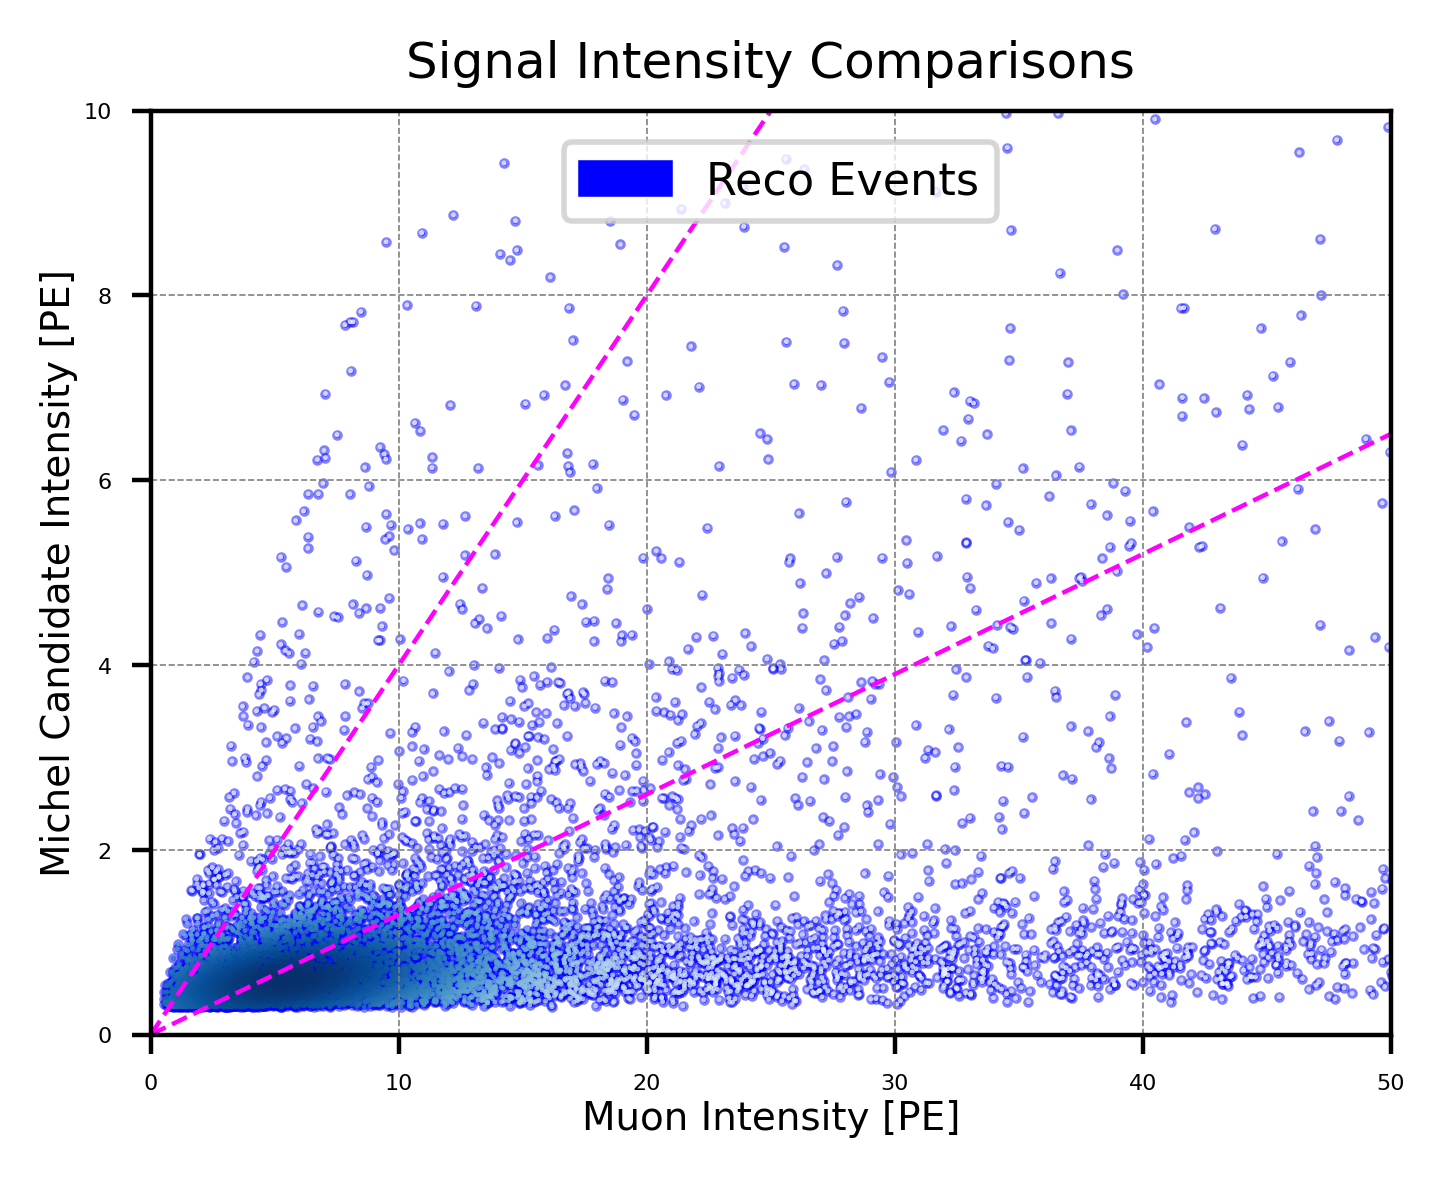


Purify 4----------------------


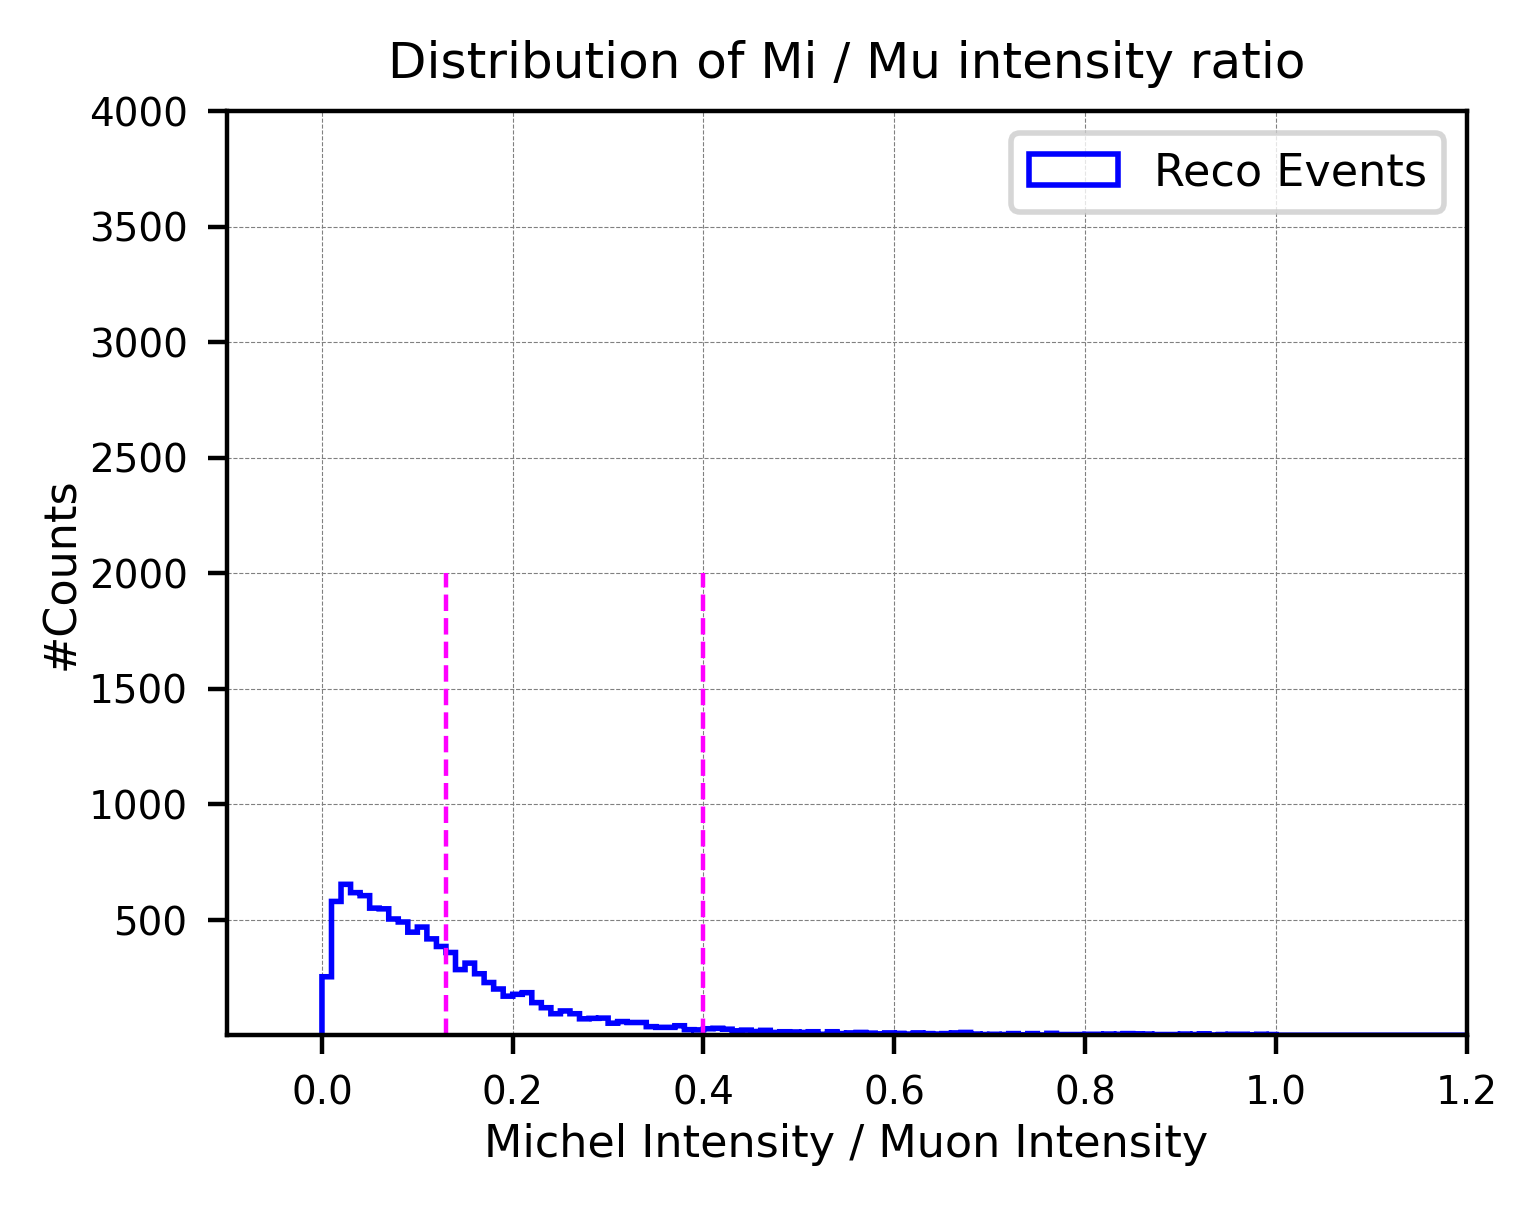

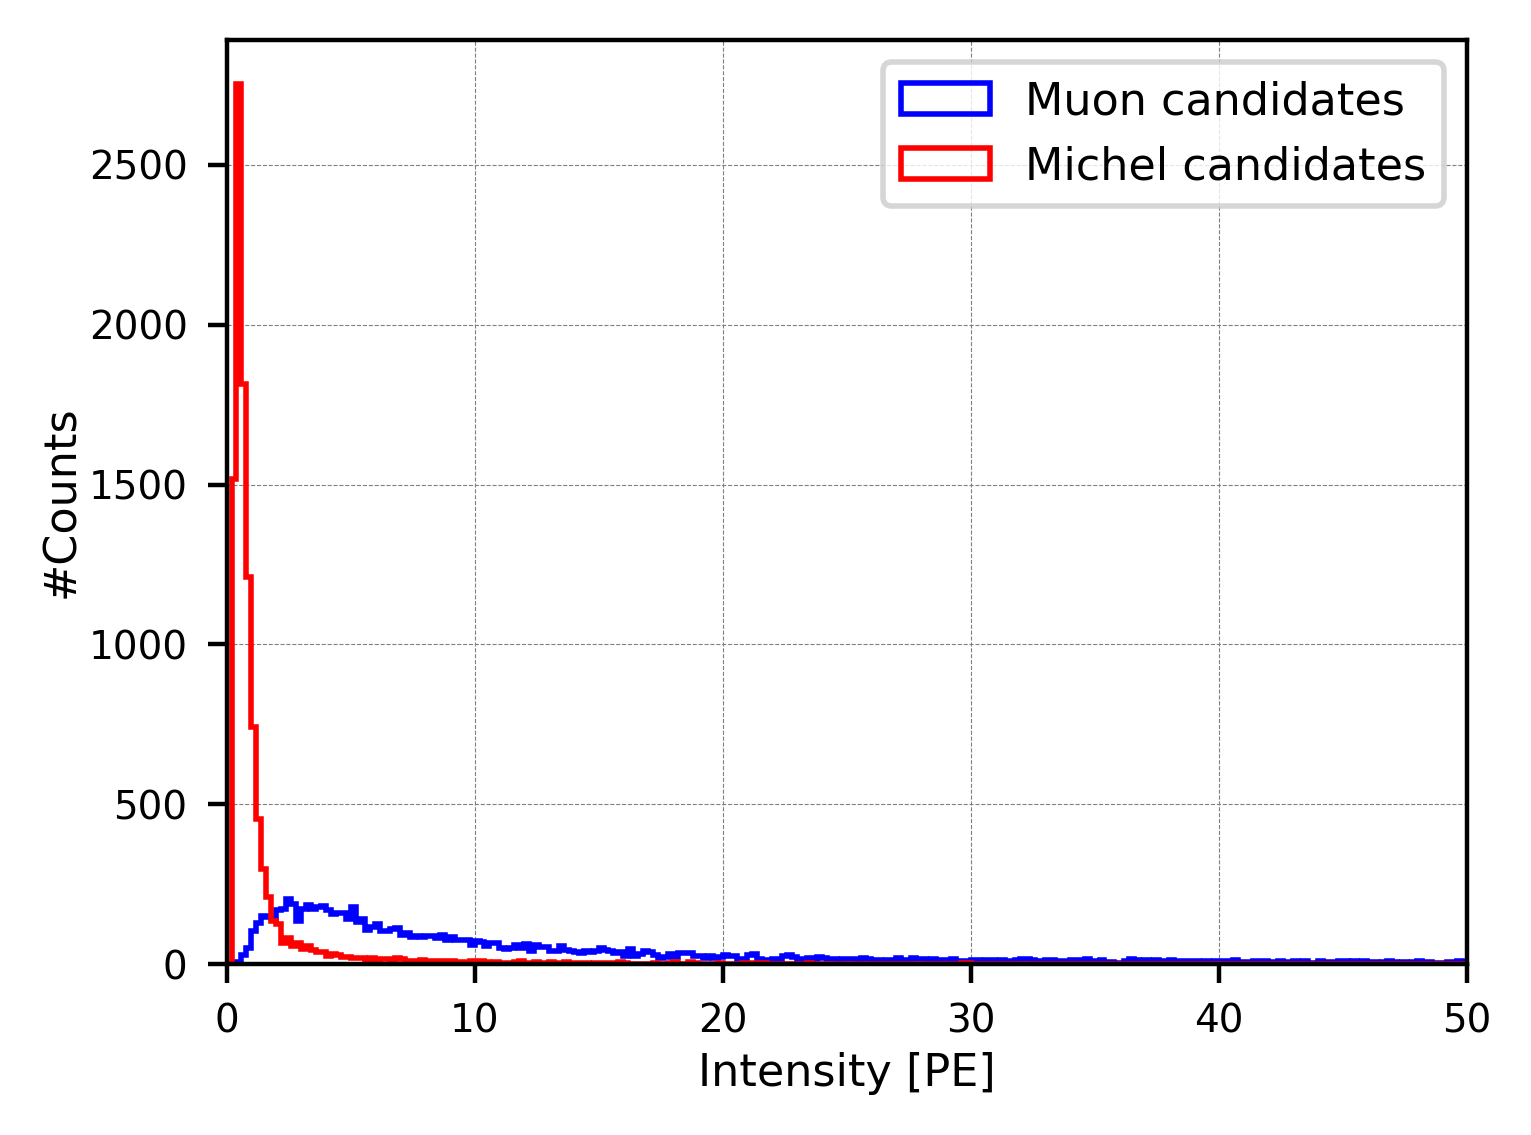

In [10]:
from scipy.stats import gaussian_kde
from matplotlib import colors 
import matplotlib.patches as mpatches

recoLife_diff = [ev.reco_lifetime for ev in events_newClass] #"diff" means nothing, just inherited from MC script
muInt_diff = [ev.muon_intensity for ev in events_newClass]
miInt_diff = [ev.michel_intensity for ev in events_newClass]
X_diff = [ev.posX for ev in events_newClass]









#Michel Intensity Cut (Cut 4)================================================
print("After lifetime cut (cut 3):")

print("# Events: ", len(events_newClass))

#scaling from MC-----
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45

thre1 = 7.5 / 50
thre2 = 40 / 100

# filter the actual events
events_total_purify4 = [
    ev for ev in events_newClass

#    if ev.muon_intensity != 0 and thre1 <  ev.michel_intensity / ev.muon_intensity < thre2

    #Shifted and scaled data---
    if ev.muon_intensity != 0 and thre1 < (2.5 * ev.michel_intensity - 0.45) / ev.muon_intensity < thre2

]
#-------------------------------

print("\n(michel Intensity) / (muon intensity) (Cut 4):----------")

print("Efficiency (cut4 / cut3): ", len(events_total_purify4), "/", len(events_newClass),
      "({:.2f}%)".format(len(events_total_purify4)/len(events_newClass)*100))











# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff), np.array(miInt_diff)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 500], [0, 65], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 1000], [0, 400], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 50) #(-5, 400)
plt.ylim(0, 10) #(-5, 60)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()






#Ratio distribution===================================
print("\nPurify 4----------------------")

ratio_diff_purify3 = [mi / mu for mi, mu in zip(miInt_diff, muInt_diff) if mu != 0]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_diff_purify3, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events")

plt.plot([0.13, 0.13], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.4, 0.4], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 1.2)
plt.xlabel('Michel Intensity / Muon Intensity', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Mi / Mu intensity ratio', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 





#Single Intensities=====================================
#Here is total: In data we cannot tell true and false---

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.2
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_diff, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Muon candidates")
plt.hist(miInt_diff, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Michel candidates")

#plt.plot([1, 1], [0, 40000], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([4, 4], [0, 400000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 50)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.title('Distribution of Mi / Mu intensity ratio', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 








### MC DATA Intensity Comparison:

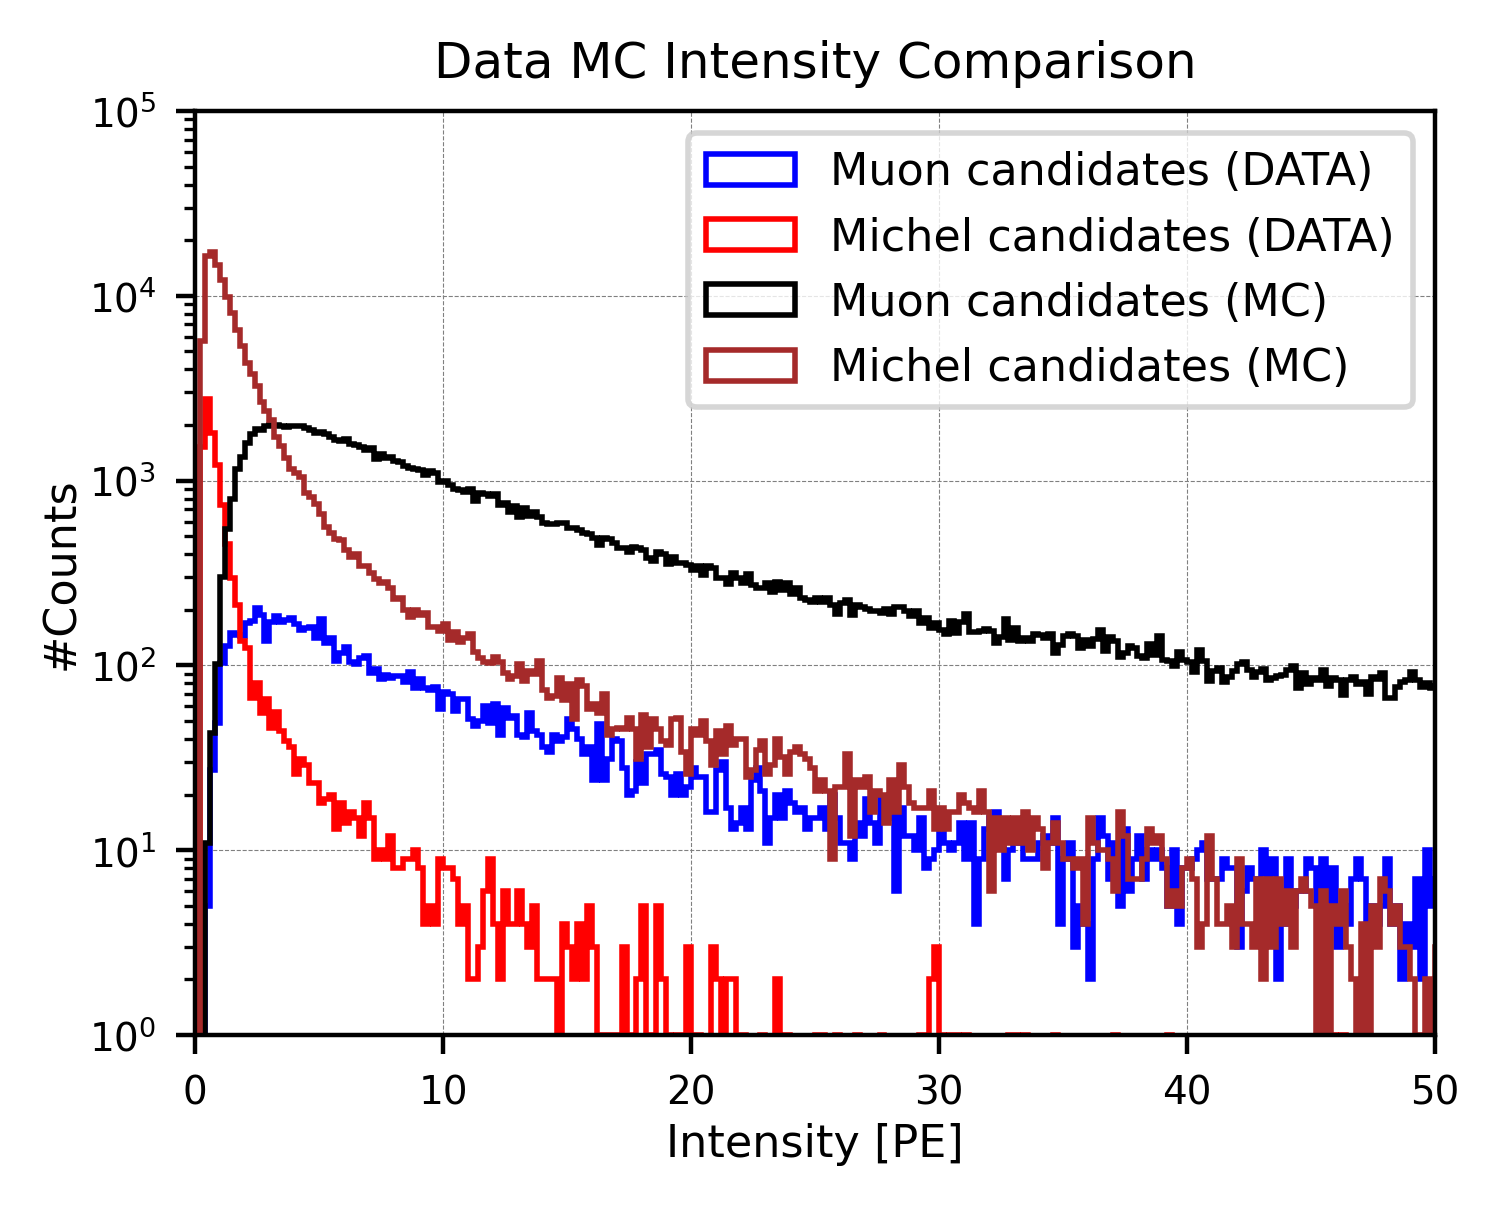

Manual scale settings:
  Muon MC:   x_scale=1.0, x_shift=0.0, y_scale=0.065
  Michel MC: x_scale=0.4, x_shift=0.18, y_scale=0.065


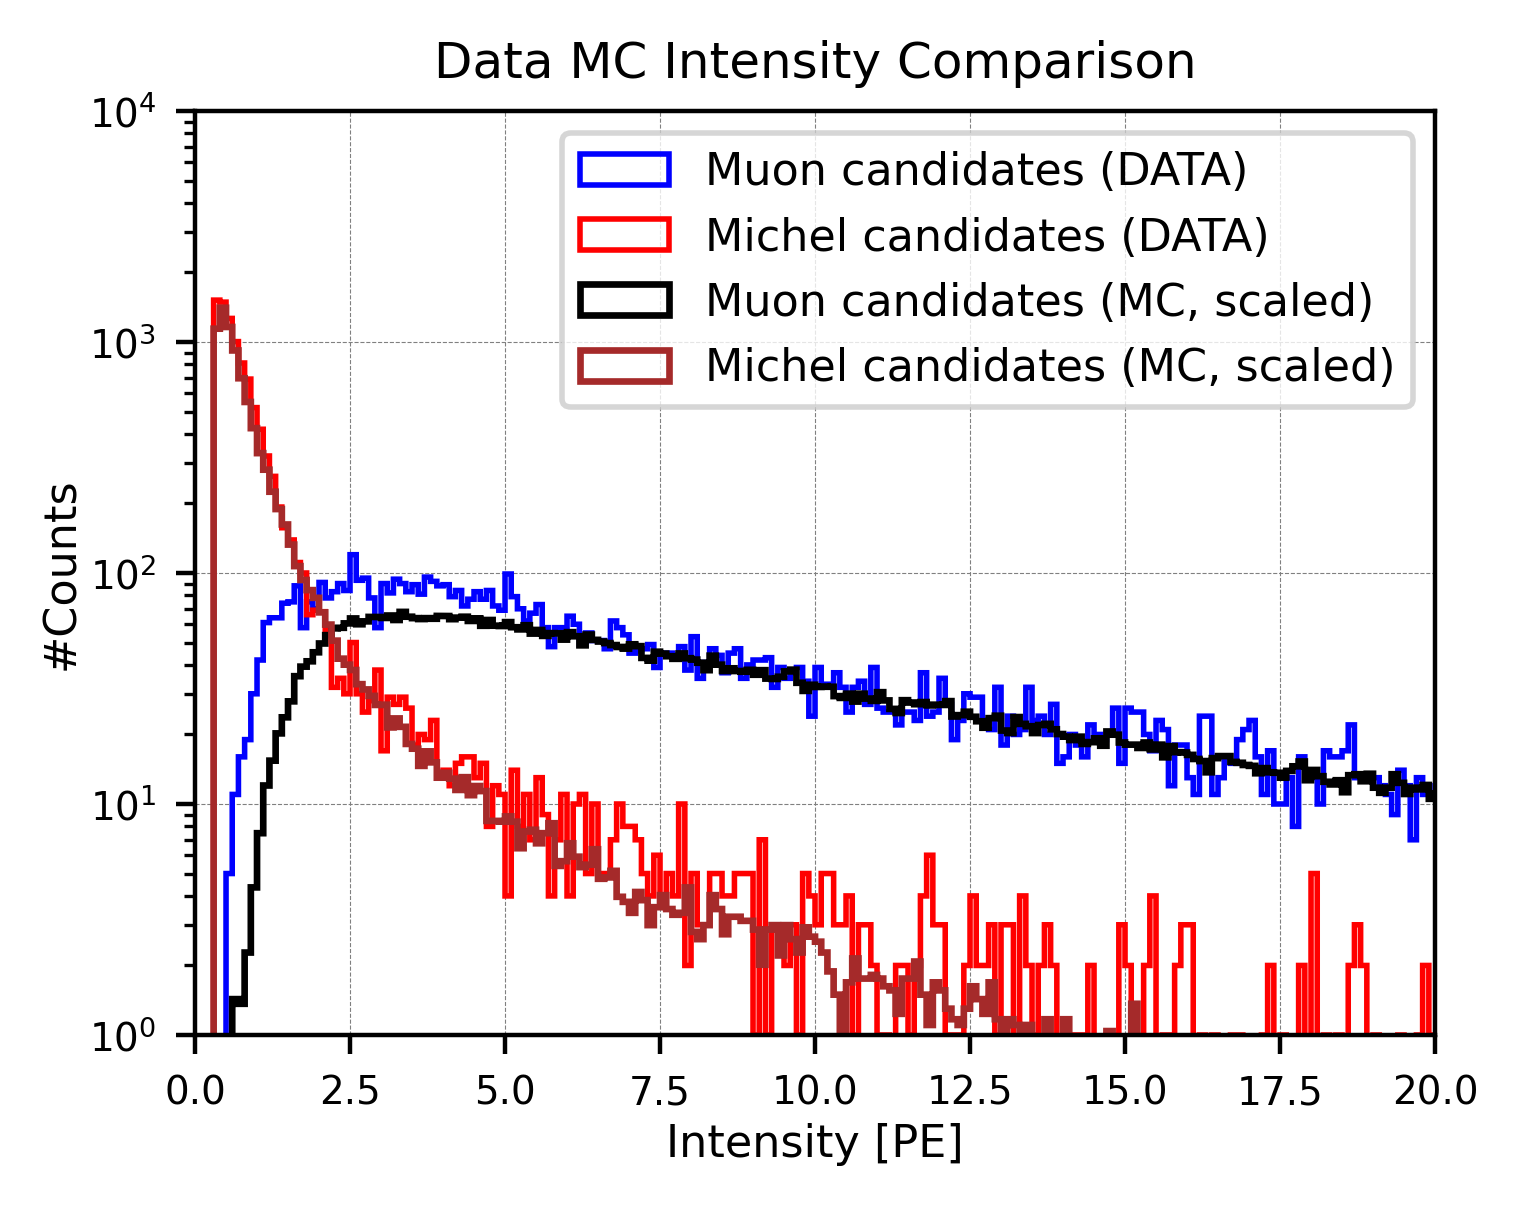

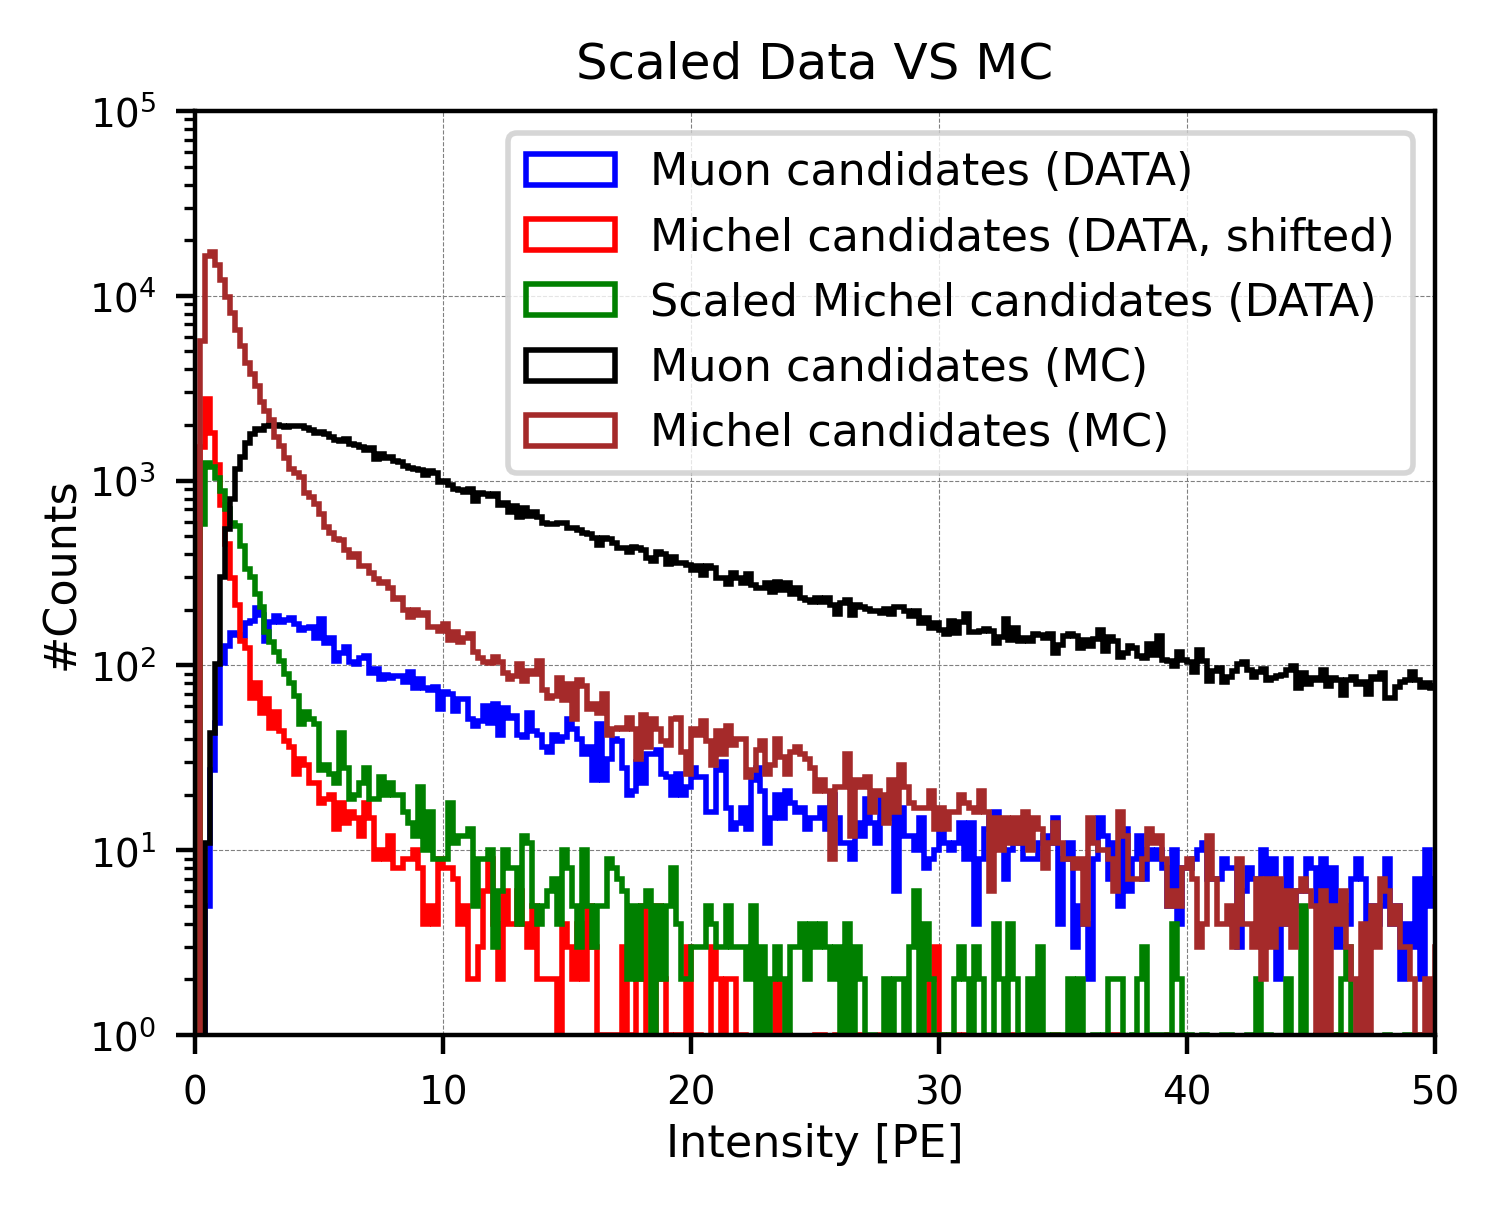

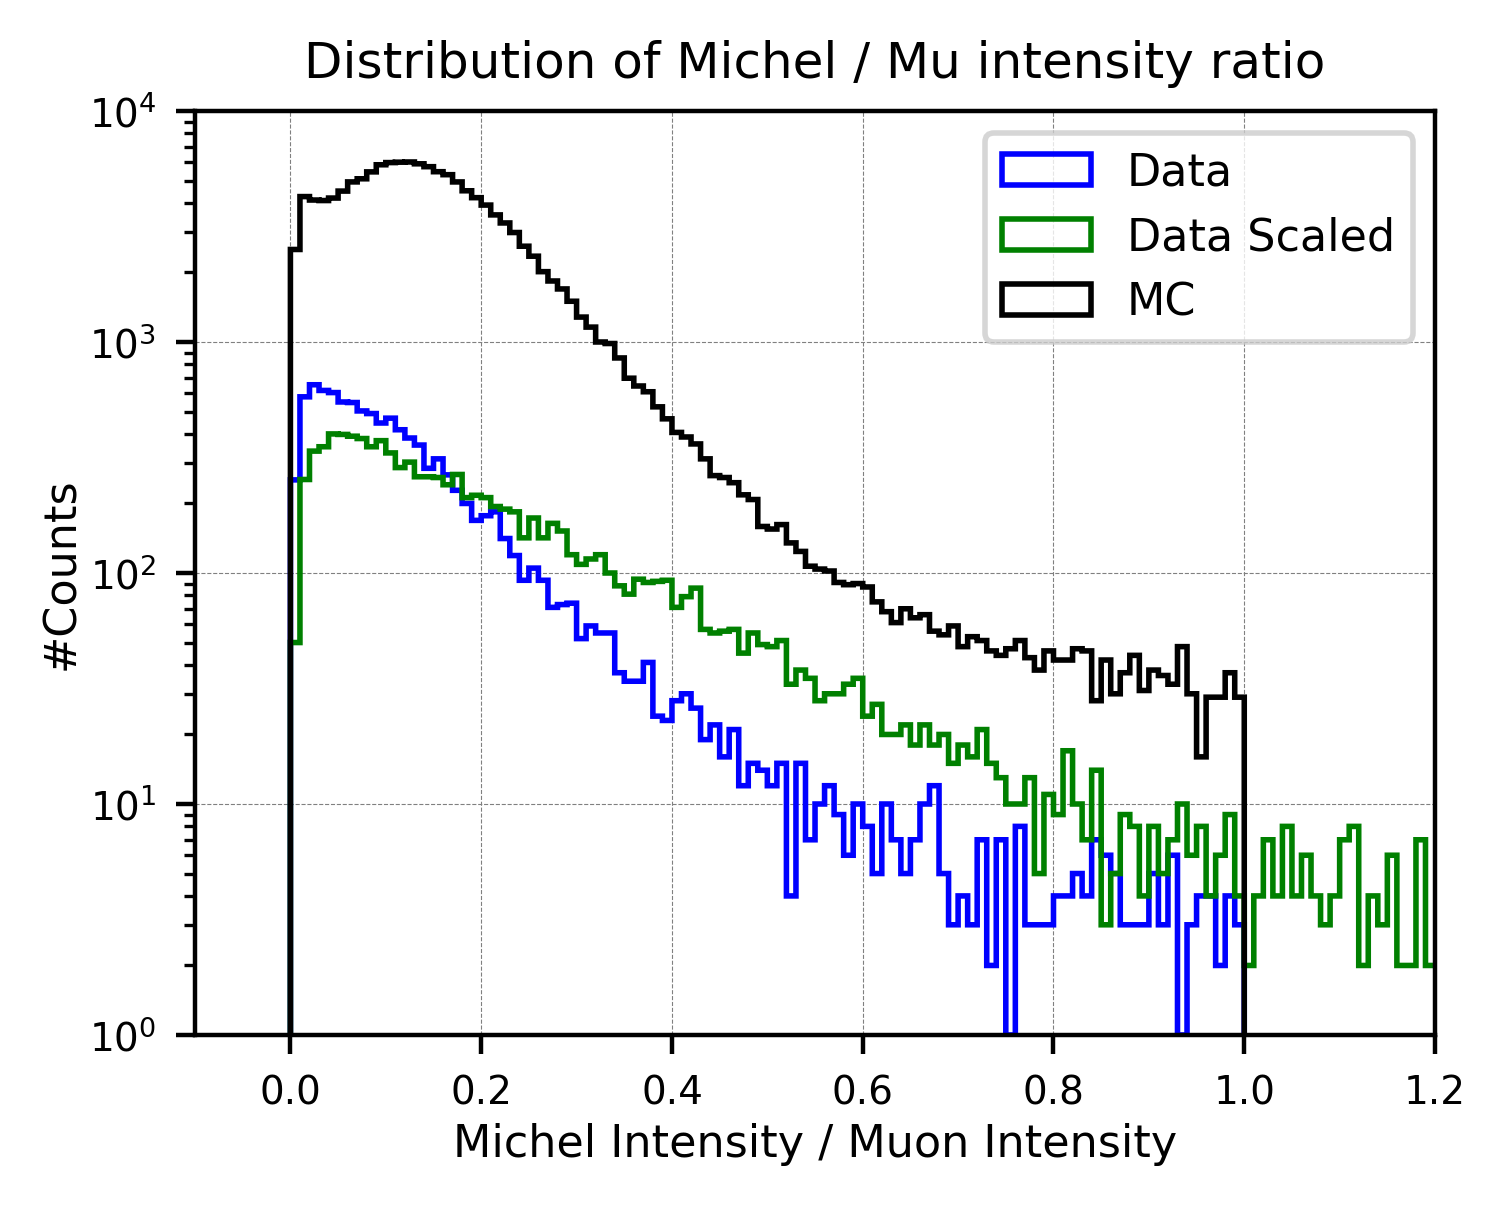

In [11]:
#Compare with MC====================================
muInt_total_MC = np.load("../../MC_new20251070s/muInt_total_MC.npy")
miInt_total_MC = np.load("../../MC_new20251070s/miInt_total_MC.npy")


plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.2
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_diff, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Muon candidates (DATA)")
plt.hist(miInt_diff, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Michel candidates (DATA)")

plt.hist(muInt_total_MC, bins=bins, range=(range_min, range_max), edgecolor='black',
         histtype='step', linewidth=1.0, label="Muon candidates (MC)")
plt.hist(miInt_total_MC, bins=bins, range=(range_min, range_max), edgecolor='brown', 
         histtype='step', linewidth=1.0, label="Michel candidates (MC)")

#plt.plot([1, 1], [0, 40000], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([4, 4], [0, 400000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 50)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 100000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Data MC Intensity Comparison', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 






#Preliminary Scaling======================================================

# X-axis scaling (MC intensities)
x_scale_muMC  = 1.0    # multiply muon MC intensity by this value
x_shift_muMC  = 0.0    # add offset

x_scale_miMC  = 0.4
x_shift_miMC  = 0.3 * (1- x_scale_miMC)

# Y-axis scaling (MC histogram heights)
y_scale_muMC = 0.065       # weight factor for all MC entries
y_scale_miMC = 0.065 

print("Manual scale settings:")
print(f"  Muon MC:   x_scale={x_scale_muMC}, x_shift={x_shift_muMC}, y_scale={y_scale_muMC}")
print(f"  Michel MC: x_scale={x_scale_miMC}, x_shift={x_shift_miMC}, y_scale={y_scale_miMC}")

# -----------------------
# 3. Apply X-axis scaling
muInt_MC_scaled = x_scale_muMC * np.array(muInt_total_MC) + x_shift_muMC
miInt_MC_scaled = x_scale_miMC * np.array(miInt_total_MC) + x_shift_miMC

# -------------------------------
# 4. Prepare histogram parameters
range_min, range_max = 0, 50
bins = np.linspace(range_min, range_max, 200)

# MC Y-axis weights (all entries get the same weight)
weights_MC_mu = np.full(len(muInt_MC_scaled), y_scale_muMC)
weights_MC_mi = np.full(len(miInt_MC_scaled), y_scale_miMC)

# ------------------
# 5. Plot Data vs MC
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- DATA histograms ---
plt.hist(muInt_diff, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Muon candidates (DATA)")
plt.hist(miInt_diff, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Michel candidates (DATA)")

# --- MC histograms (scaled) ---
plt.hist(muInt_MC_scaled, bins=bins, range=(range_min, range_max),
         histtype='step', linewidth=1.2, color='bLack',
         weights=weights_MC_mu,
         label="Muon candidates (MC, scaled)")

plt.hist(miInt_MC_scaled, bins=bins, range=(range_min, range_max),
         histtype='step', linewidth=1.2, color='brown',
         weights=weights_MC_mi,
         label="Michel candidates (MC, scaled)")

plt.xlim(0, 20)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 10000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Data MC Intensity Comparison', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 








#Shift Data to Apply Cut=============================================
miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.2
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_diff, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Muon candidates (DATA)")
plt.hist(miInt_diff, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=1.0, label="Michel candidates (DATA, shifted)")
plt.hist(miInt_DATA_scaled, bins=bins, range=(range_min, range_max), edgecolor='green', 
         histtype='step', linewidth=1.0, label="Scaled Michel candidates (DATA)")

plt.hist(muInt_total_MC, bins=bins, range=(range_min, range_max), edgecolor='black',
         histtype='step', linewidth=1.0, label="Muon candidates (MC)")
plt.hist(miInt_total_MC, bins=bins, range=(range_min, range_max), edgecolor='brown', 
         histtype='step', linewidth=1.0, label="Michel candidates (MC)")

#plt.plot([1, 1], [0, 40000], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([4, 4], [0, 400000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 50)
plt.xlabel('Intensity [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 100000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Scaled Data VS MC', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 









# Sacaled Ratio Comparison===========================================
ratio_DATA_scaled = [mi / mu for mi, mu in zip(miInt_DATA_scaled, muInt_diff) if mu != 0]

ratio_MC = [mi / mu for mi, mu in zip(miInt_total_MC, muInt_total_MC) if mu != 0]


plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_diff_purify3, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Data")
plt.hist(ratio_DATA_scaled, bins=bins, range=(range_min, range_max), edgecolor='green', 
         histtype='step', linewidth=1.0, label="Data Scaled")
plt.hist(ratio_MC, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=1.0, label="MC")

#plt.plot([0.13, 0.13], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0.4, 0.4], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 1.2)
plt.xlabel('Michel Intensity / Muon Intensity', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 10000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel / Mu intensity ratio', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 







#### Cut 5: Michel intensity & Muon intensity: 

After cut 4:
# Events:  3851

Michel Intensity Cut (Cut 5):--------------
Efficiency (cut5 / cut4):  2353 / 3851 (61.10%)


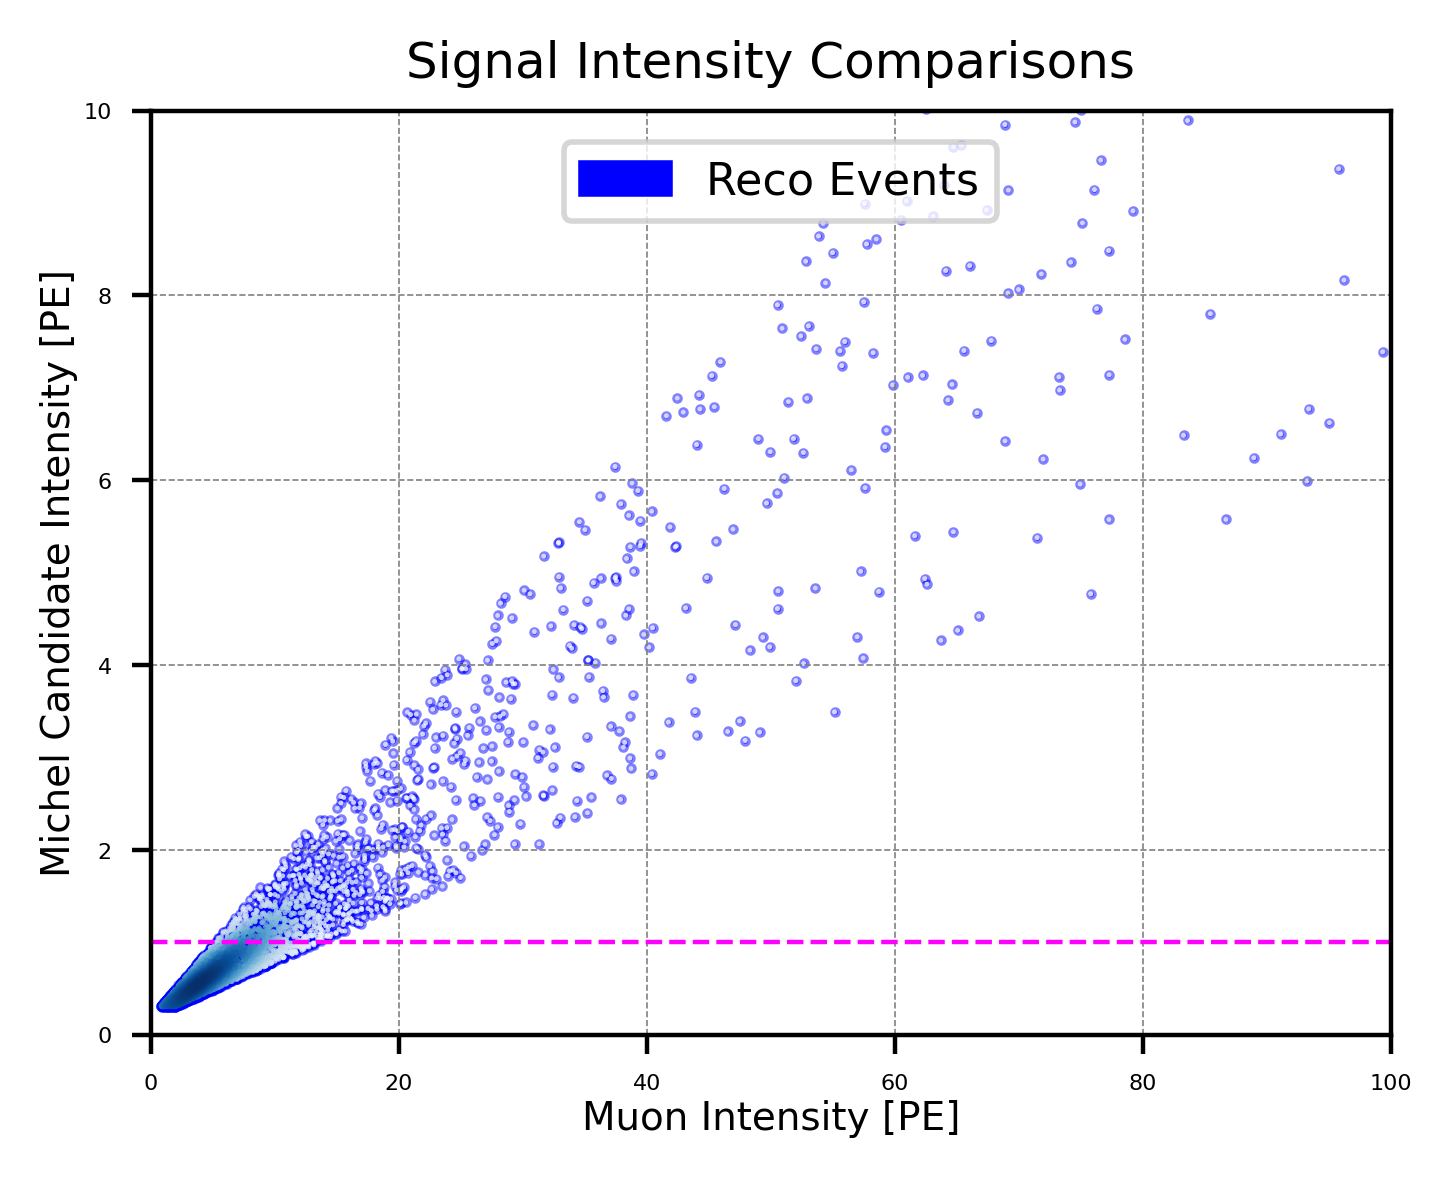


Purify 5----------------------


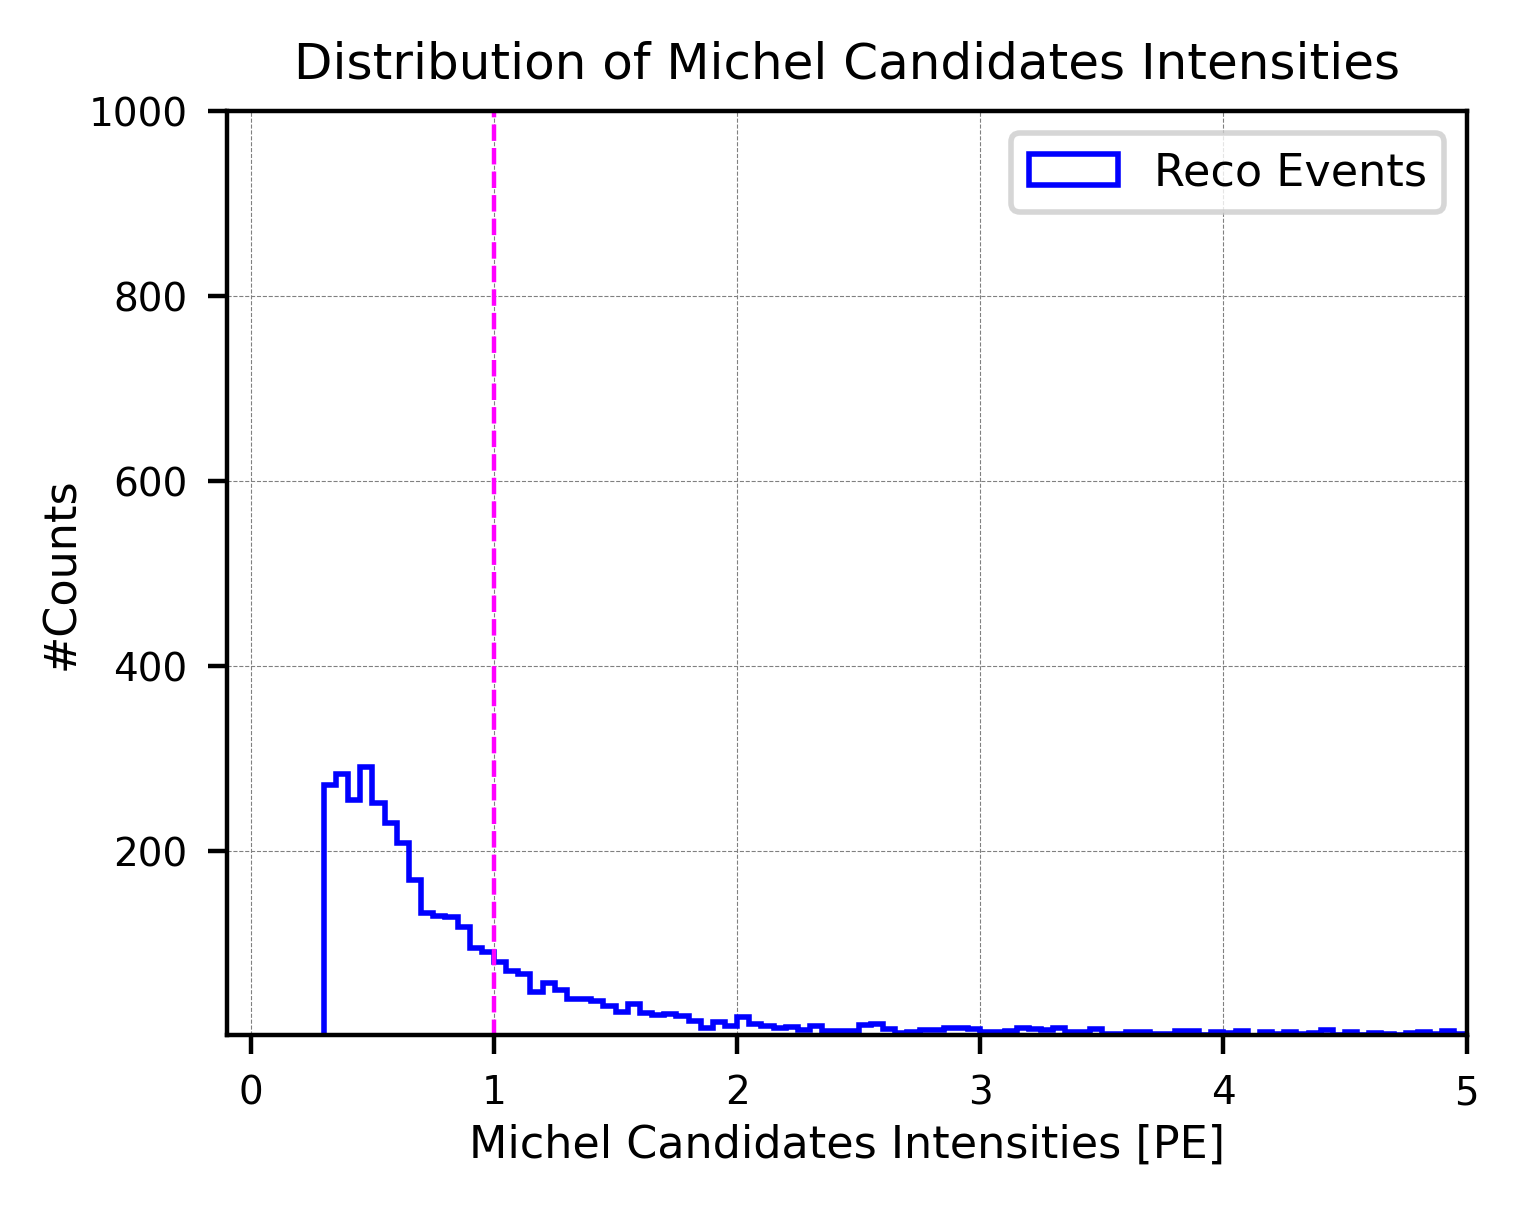

In [12]:
#Michel & Muon Intensities Cut (Cut 5)================================================
print("After cut 4:")

print("# Events: ", len(events_total_purify4))




thre_muInt = 0.3 # mu Int will automatically higher than mi---
thre_miInt = 1.0

#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


# filter the actual events
events_total_purify5 = [
    ev for ev in events_total_purify4
    if thre_miInt < (2.5 * ev.michel_intensity - 0.45) and thre_muInt < ev.muon_intensity
]
#-------------------------------

print("\nMichel Intensity Cut (Cut 5):--------------")

print("Efficiency (cut5 / cut4): ", len(events_total_purify5), "/", len(events_total_purify4),
      "({:.2f}%)".format(len(events_total_purify5)/len(events_total_purify4)*100))








# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
muInt_diff_purify4 = [ev.muon_intensity for ev in events_total_purify4]
miInt_diff_purify4 = [ev.michel_intensity for ev in events_total_purify4]



plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff_purify4), np.array(miInt_diff_purify4)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 100], [1.0, 1.0], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 100)
plt.ylim(0, 10)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()







#Michel Intensity distribution===================================
print("\nPurify 5----------------------")

#miInt_diff500_purify5 = [ev.michel_intensity for ev in events_diff500_purify5]
#miInt_diff0_purify5 = [ev.michel_intensity for ev in events_diff0_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(miInt_diff_purify4, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events")

plt.plot([1.0, 1.0], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 5)
plt.xlabel('Michel Candidates Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel Candidates Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#### Mu & Michel intensity distributions after Cut 5:

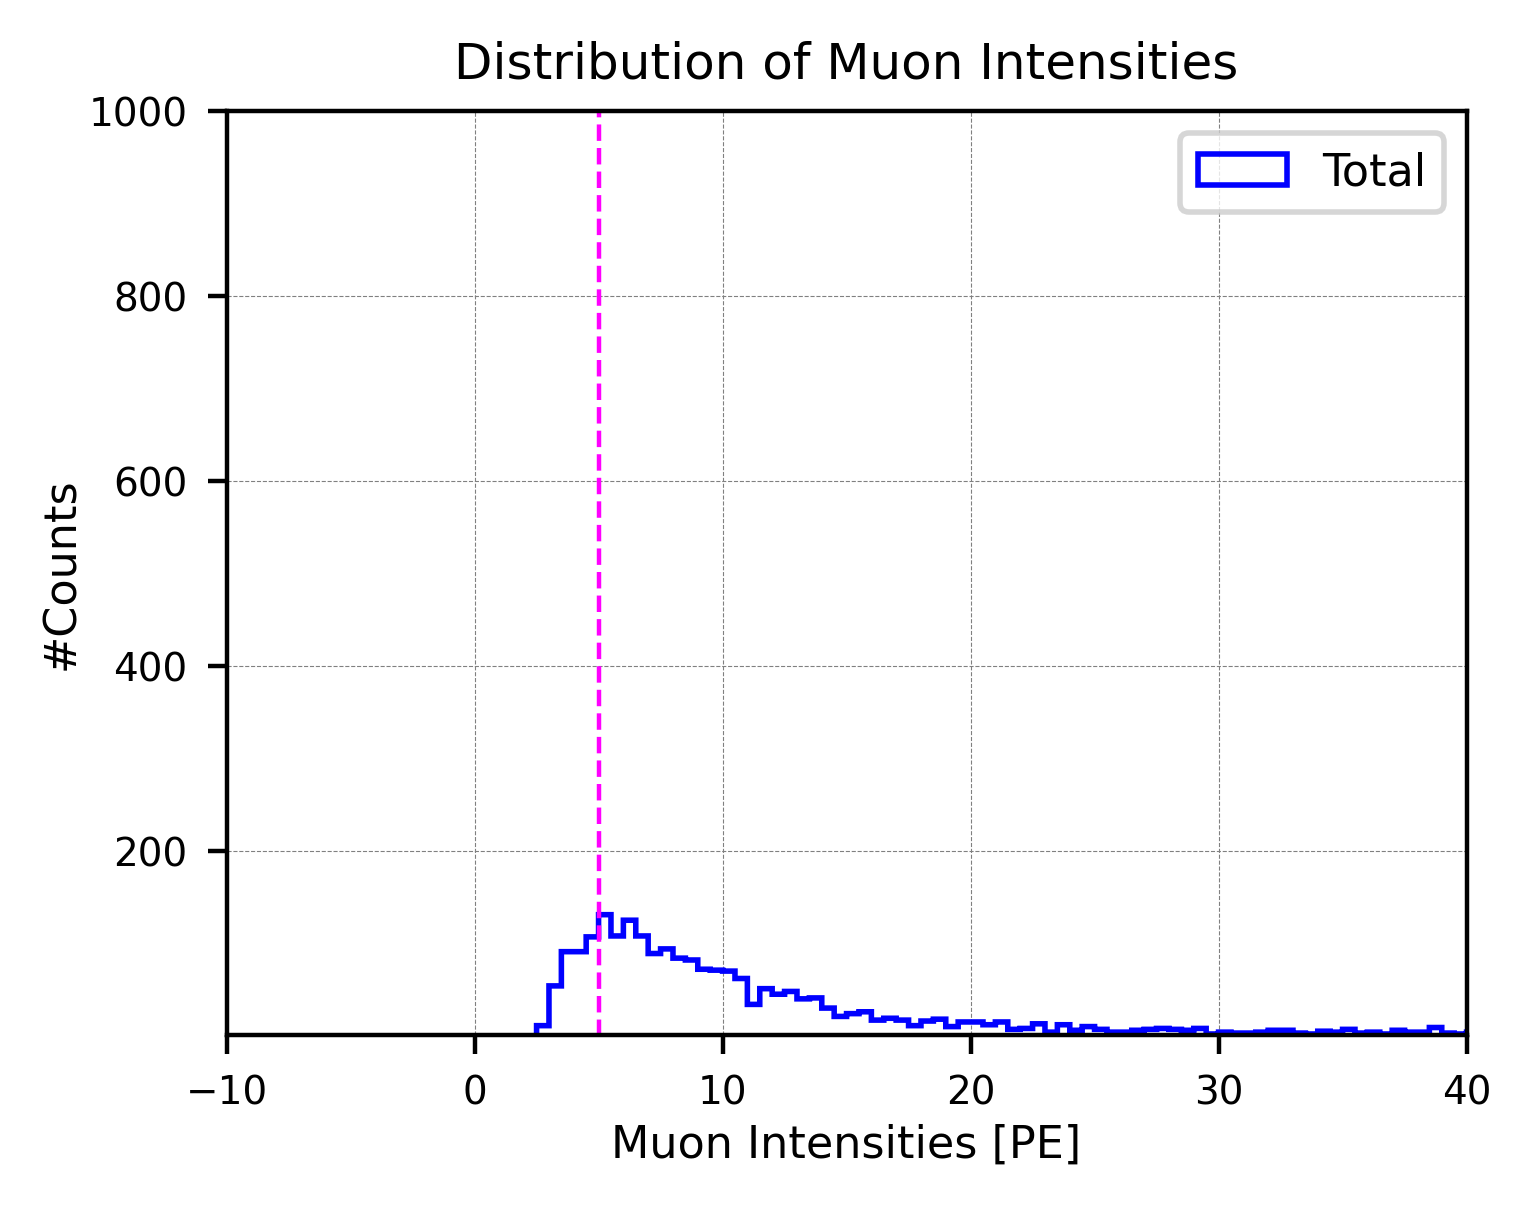

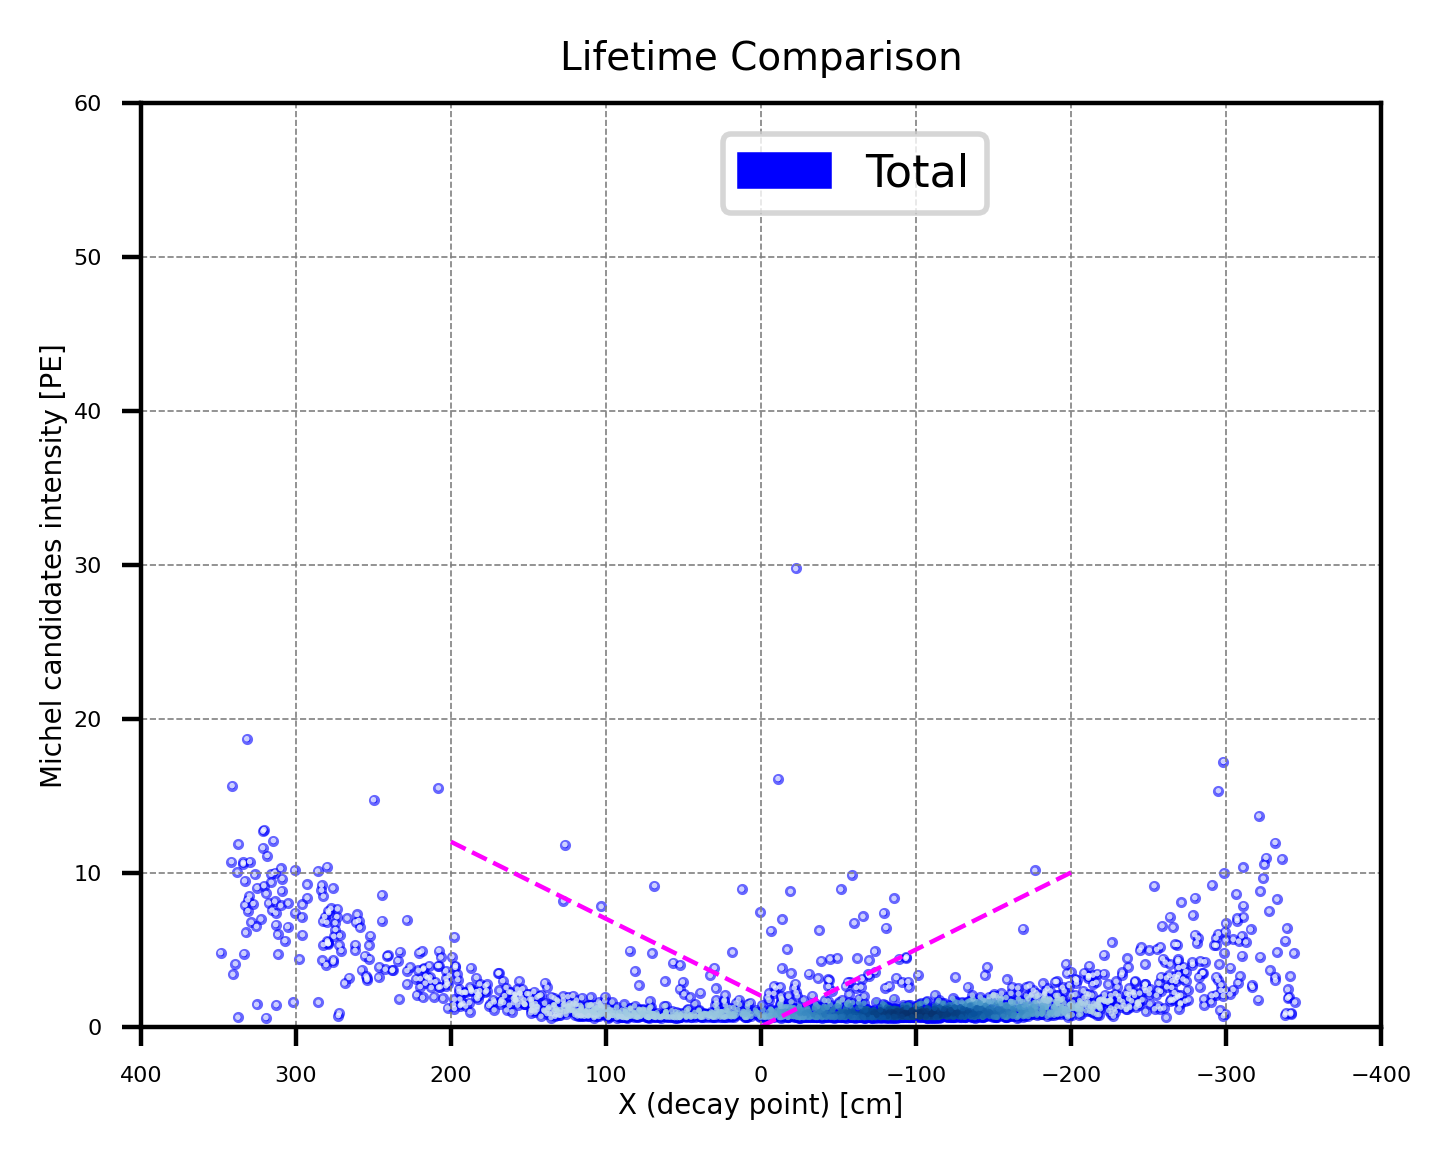

In [13]:
#Muon Intensity distribution===================================

muInt_total_purify5 = [ev.muon_intensity for ev in events_total_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = 0
range_max = 300
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_total_purify5, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Total")

plt.plot([5, 5], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-10, 40)
plt.xlabel('Muon Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Muon Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 





#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5 = [ev.posX for ev in events_total_purify5]
miInt_total_purify5 = [ev.michel_intensity for ev in events_total_purify5]

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5, dtype=float)
y1 = np.array(miInt_total_purify5, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [0, 10], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()

#### Cut 5': Michel signal VS Distance cut:

After cut 5:---------
#events:  2353

After Cut 5' (Michel vs Distance):--------------
Efficiency (cut5' / cut5):  2086 / 2353 (88.65%)


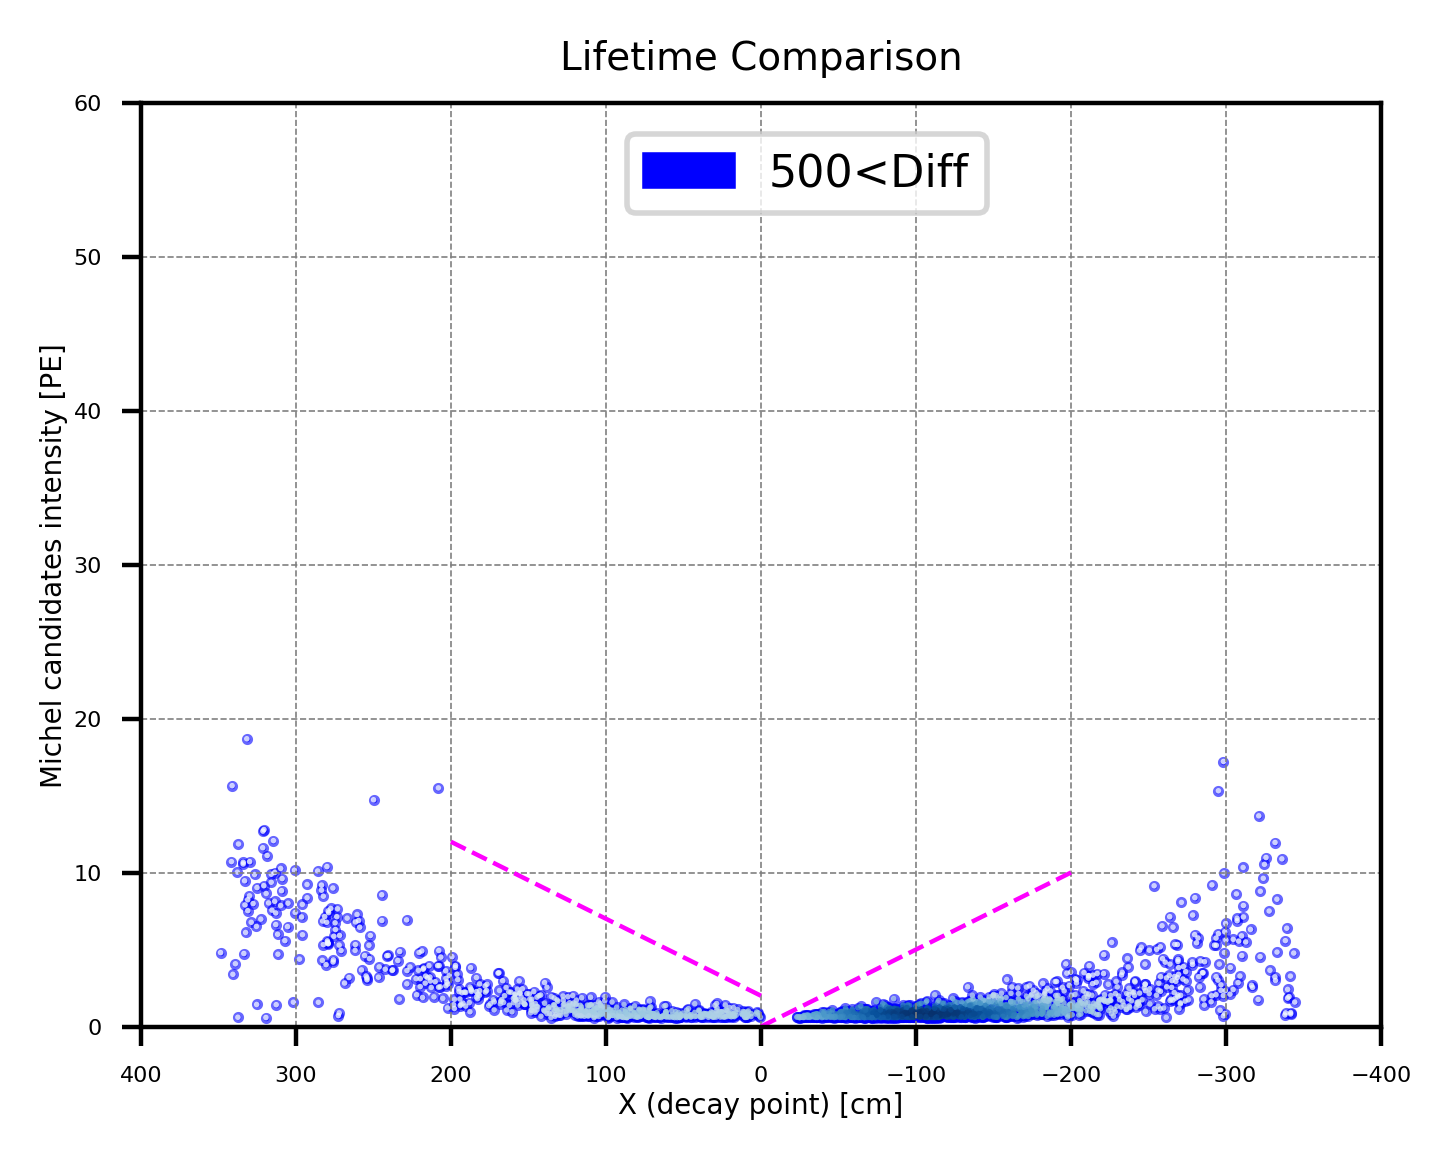

In [14]:
print("After cut 5:---------")

print("#events: ", len(events_total_purify5))



#Michel Peak rise & drop Cut (Cut 5')--------
# --- Define slopes and intercepts for both cuts ---
slope_pos = (7 - 2) / 100.0      # = 0.05
intercept_pos = 2.0

slope_neg = (10 - 0) / (-200 - 0.0)  # = -0.05
intercept_neg = 0.0


#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


def below_line_cut(ev):
    """Return True if event passes both (posX, michel_intensity) cuts."""
    x = ev.posX
#    y = ev.michel_intensity
    y = 2.5 * ev.michel_intensity -0.45

    # Region 1: positive side [0, 100]
    if 0 <= x <= 200:
        return y <= intercept_pos + slope_pos * x

    # Region 2: negative side [-200, 0]
    elif -200 <= x <= 0:
        return y <= intercept_neg + slope_neg * x

    # Outside both ranges: no cut
    else:
        return True

# --- Apply the geometric cut to both event classes ---
events_total_purify5P = [ev for ev in events_total_purify5 if below_line_cut(ev)]
#-------------------------------





print("\nAfter Cut 5' (Michel vs Distance):--------------")

print("Efficiency (cut5' / cut5): ", len(events_total_purify5P), "/", len(events_total_purify5),
      "({:.2f}%)".format(len(events_total_purify5P)/len(events_total_purify5)*100))






#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5P = [ev.posX for ev in events_total_purify5P]
miInt_total_purify5P = [ev.michel_intensity for ev in events_total_purify5P]

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5P, dtype=float)
y1 = np.array(miInt_total_purify5P, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [0, 10], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="500<Diff")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#### Cut 6: Michel peak rise and drop slope: 

After cut 5':---------
#event    :  2086

Michel Peak Rise Drop Slope (Cut 6):--------------
Efficiency (cut6 / cut5):  1475 / 2086 (70.71%)


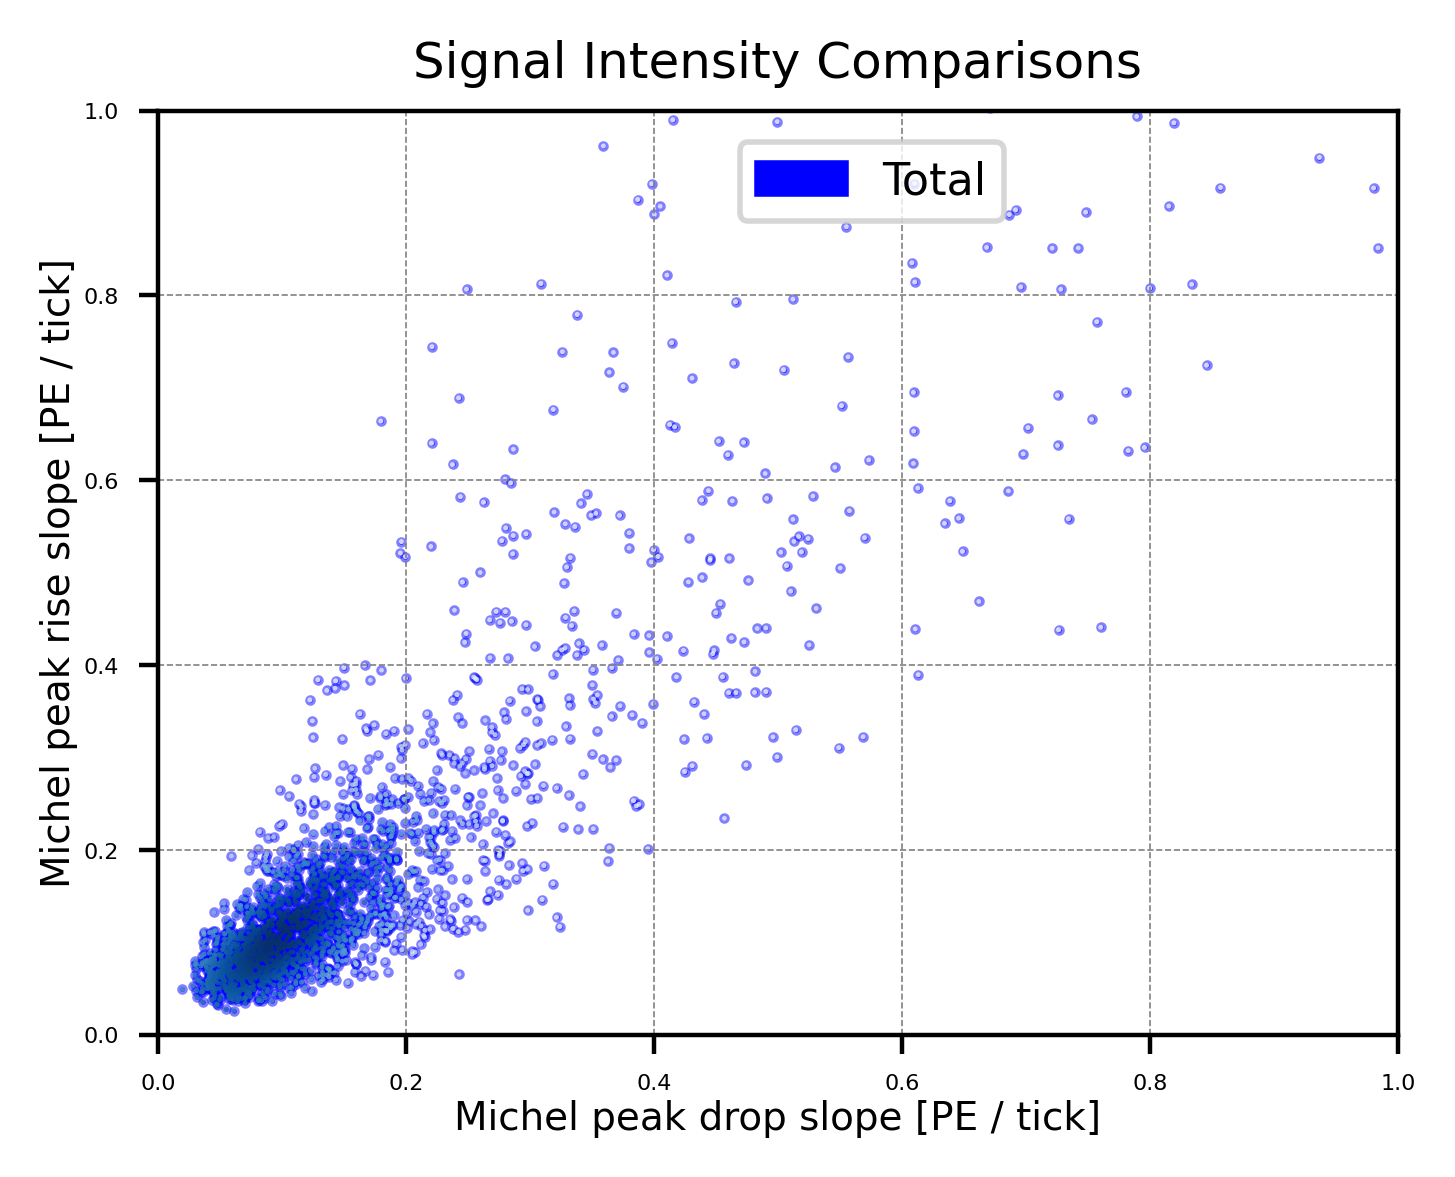

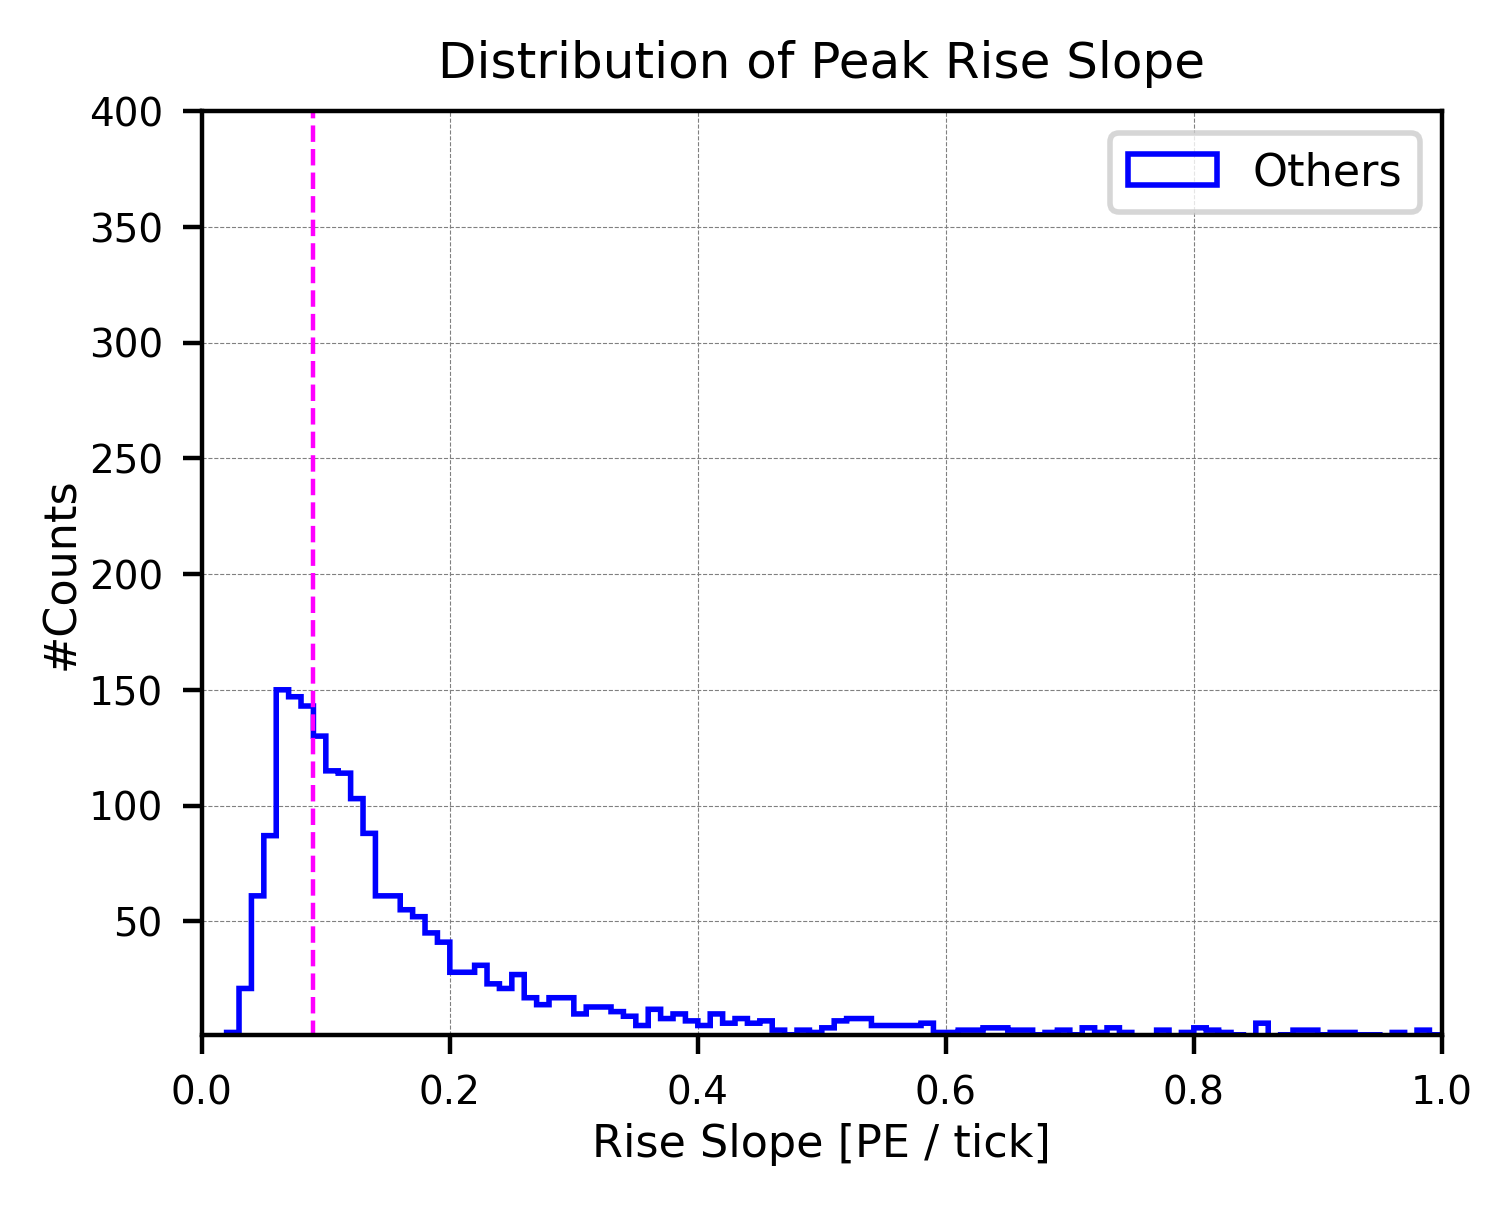

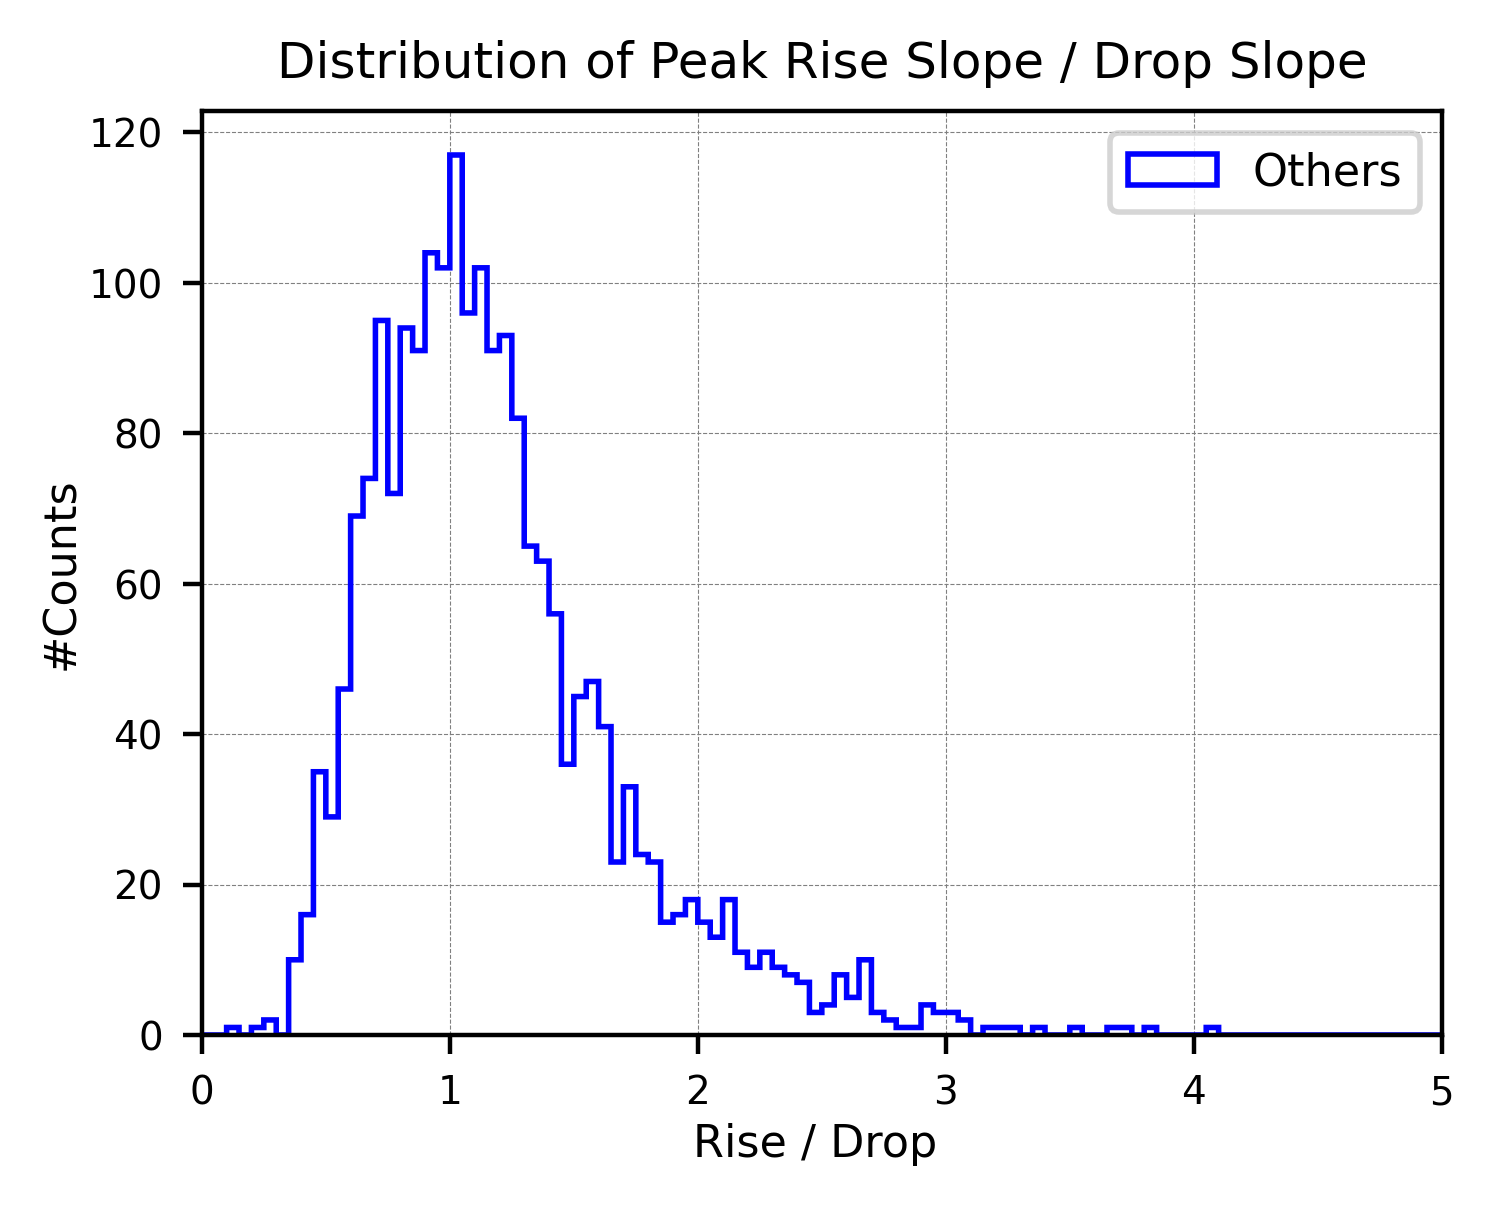

In [15]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 5':---------")
print("#event    : ", len(events_total_purify5P))



rise_total_purity5P = [ev.michel_rise for ev in events_total_purify5P]
drop_total_purity5P = [ev.michel_drop for ev in events_total_purify5P]

ratios_total_purity5P = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_total_purity5P, drop_total_purity5P)
]



thre_rise = 0.09 # mu Int will automatically higher than mi---

#Slope calculation is updated based on miInt update; 20251207---

# filter the actual events
events_total_purify6 = [
    ev for ev in events_total_purify5P
    if thre_rise < ev.michel_rise 
]
#-------------------------------



print("\nMichel Peak Rise Drop Slope (Cut 6):--------------")

print("Efficiency (cut6 / cut5): ", len(events_total_purify6), "/", len(events_total_purify5P),
      "({:.2f}%)".format(len(events_total_purify6)/len(events_total_purify5P)*100))








# ==========================================================
# Michel Rise VS Michel Drop
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(drop_total_purity5P), np.array(rise_total_purity5P)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")


#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Michel peak drop slope [PE / tick]', labelpad=1, fontsize=7)
plt.ylabel('Michel peak rise slope [PE / tick]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#Michel Rise Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(rise_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.09, 0.09], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(0, 1.0)
plt.xlabel('Rise Slope [PE / tick]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 400)
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#Michel Rise & Drop Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
plt.hist(ratios_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")


plt.xlim(0, 5)
plt.xlabel('Rise / Drop ', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope / Drop Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 




### Cut 7: 2nd 3rd peak intensity Ratio cut

After cut 6:---------
#event    :  1475

Third / Second peak intensity (Cut 7):--------------
Efficiency (cut7 / cut6):  1401 / 1475 (94.98%)


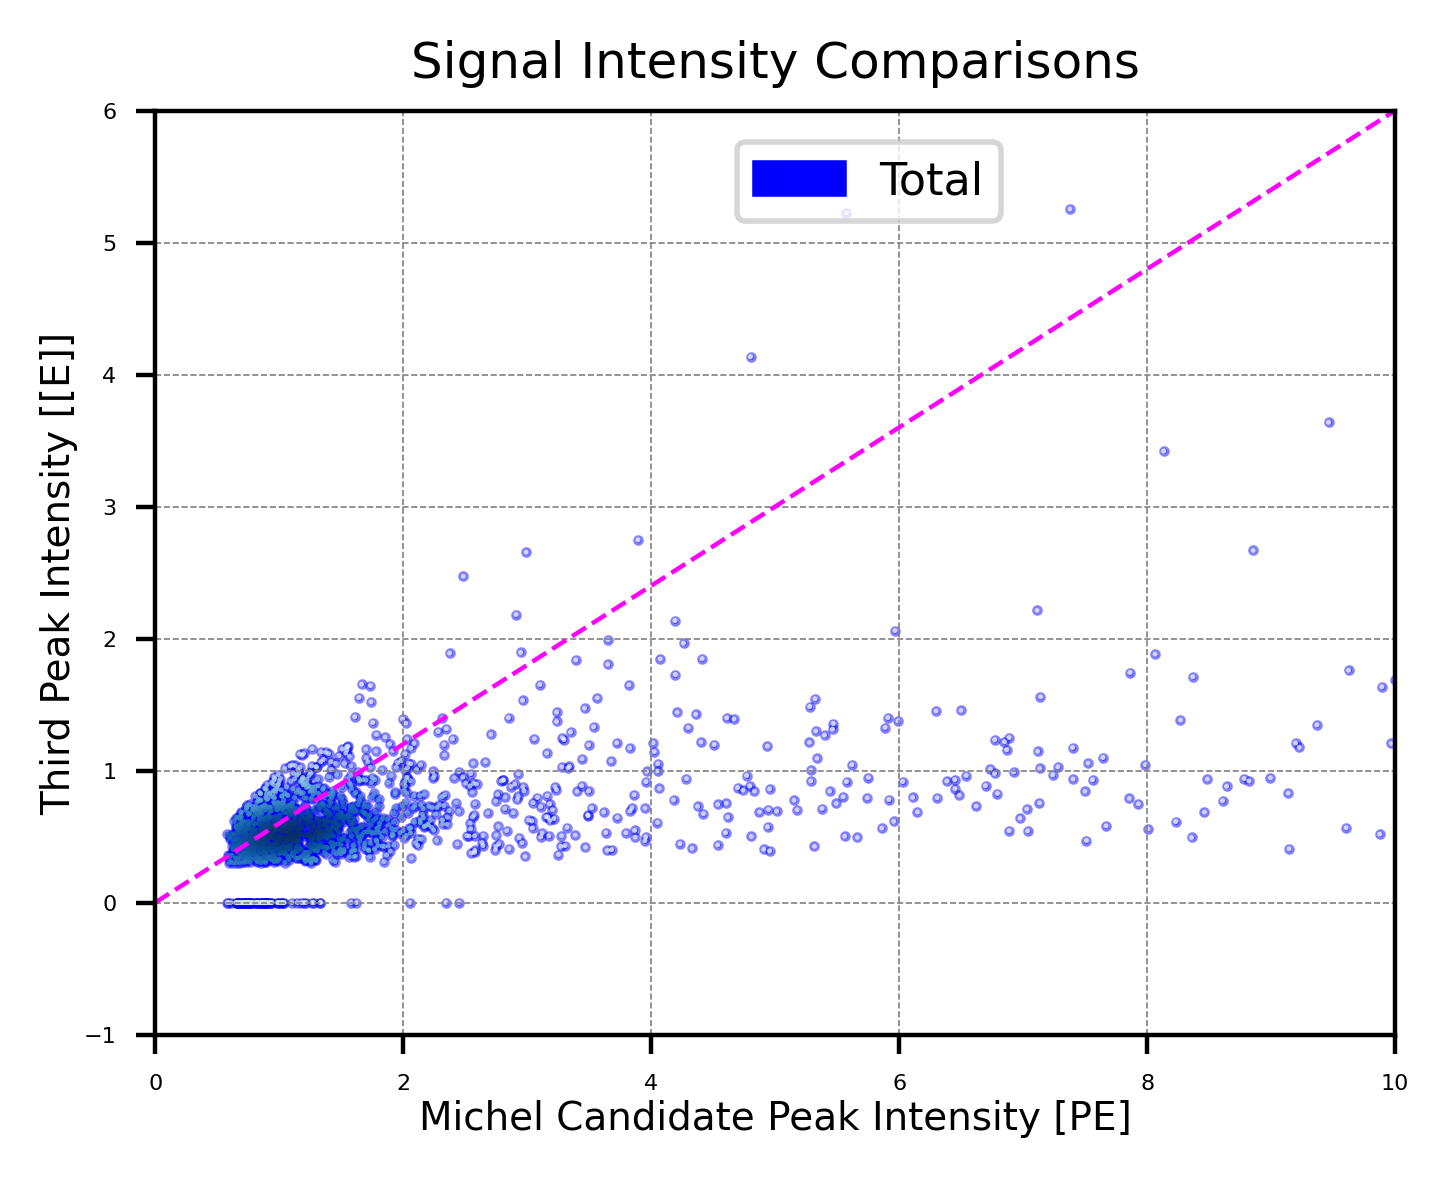

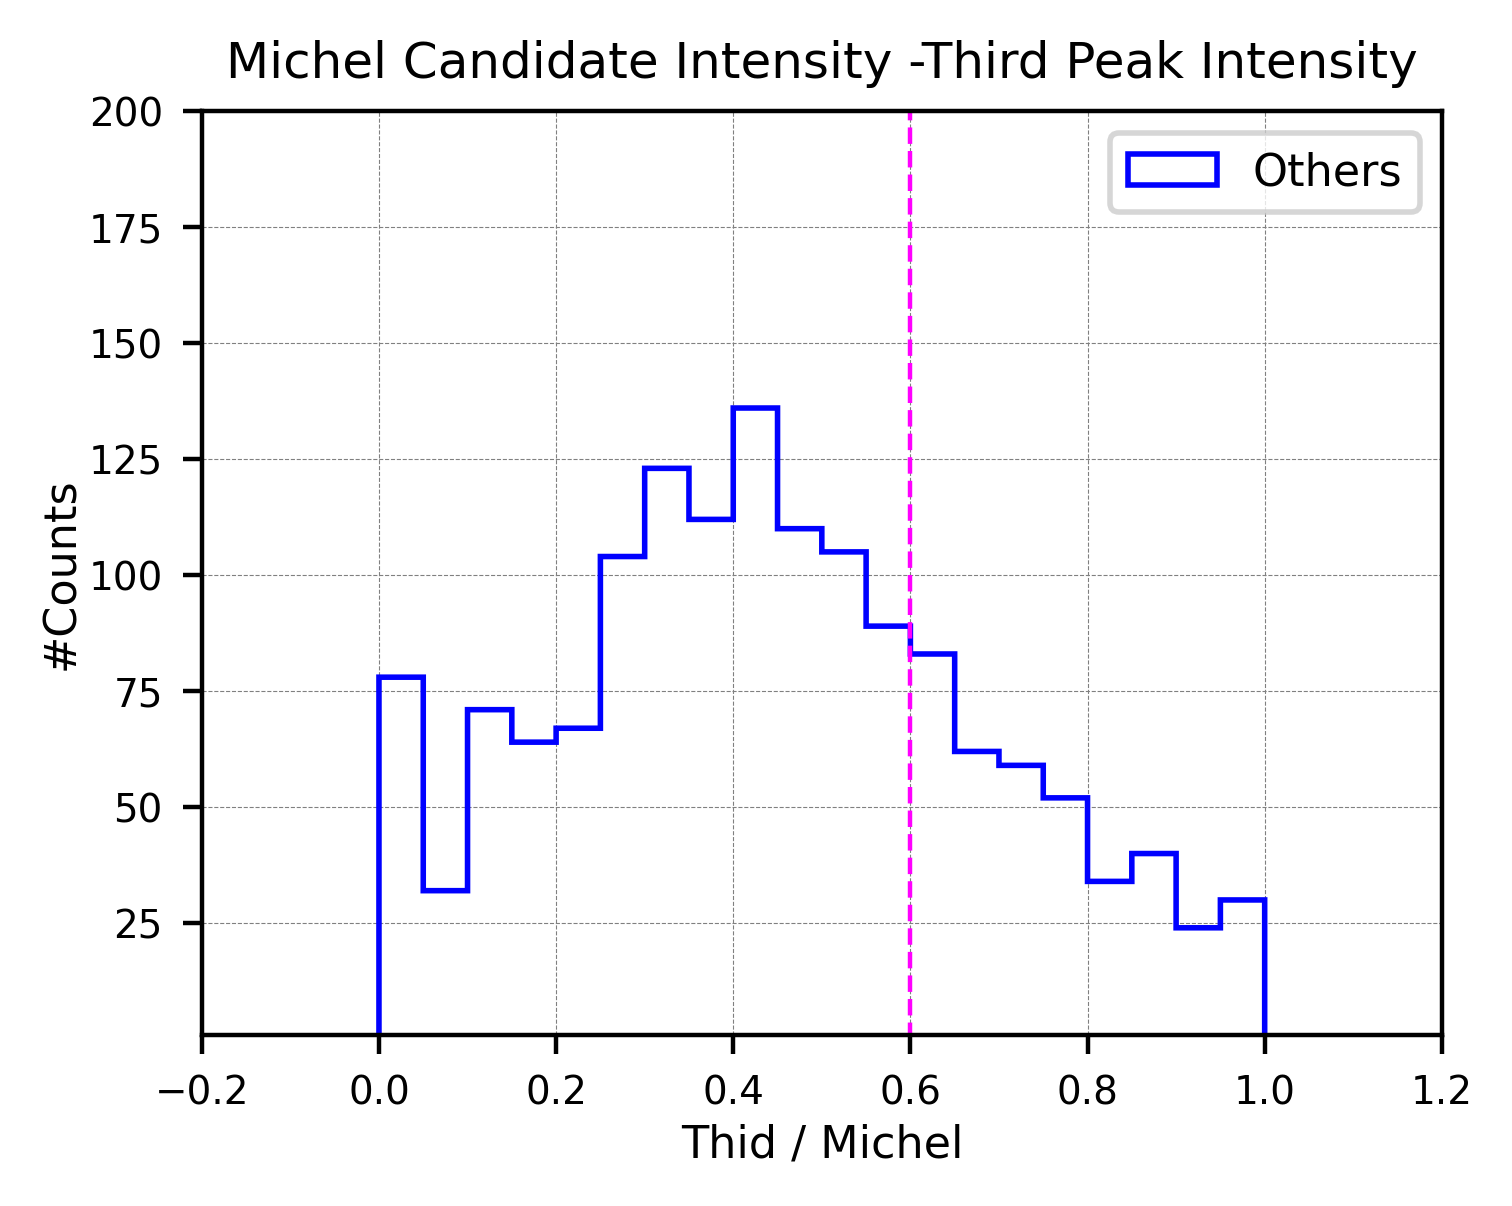

In [16]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 6:---------")

print("#event    : ", len(events_total_purify6))



miInt_total_purity6 = [ev.michel_intensity for ev in events_total_purify6]
thInt_total_purity6 = [ev.third_intensity for ev in events_total_purify6]



# Element-by-element ratio (thInt / miInt)
ratio_total_purity6 = [th / mi for th, mi in zip(thInt_total_purity6, miInt_total_purity6)]


thre1 = 0.0
thre2 = 0.6

# filter the actual events

#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45


events_total_purify7 = [
    ev for ev in events_total_purify6
#    if ev.michel_intensity != 0 and thre1 < ev.third_intensity / ev.michel_intensity < thre2
    if ev.michel_intensity != 0 and thre1 < ev.third_intensity / (2.5 * ev.michel_intensity - 0.45) < thre2    
]
#-------------------------------


print("\nThird / Second peak intensity (Cut 7):--------------")
print("Efficiency (cut7 / cut6): ", len(events_total_purify7), "/", len(events_total_purify6),
      "({:.2f}%)".format(len(events_total_purify7)/len(events_total_purify6)*100))









# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x2, y2 = np.array(miInt_total_purity6), np.array(thInt_total_purity6)
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 100], [0, 60], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()






#Third / Michel Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_total_purity6, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.6, 0.6], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.2, 1.2)
plt.xlabel('Thid / Michel', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 200)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 

### Cut 8: Third second peak intensity diff cut


After Cut 7:--------------
#event   :  1401

Michel 3rd Peaks intensity Diff (Cut 8):--------------
Efficiency (cut8 / cut7):  1367 / 1401 (97.57%)


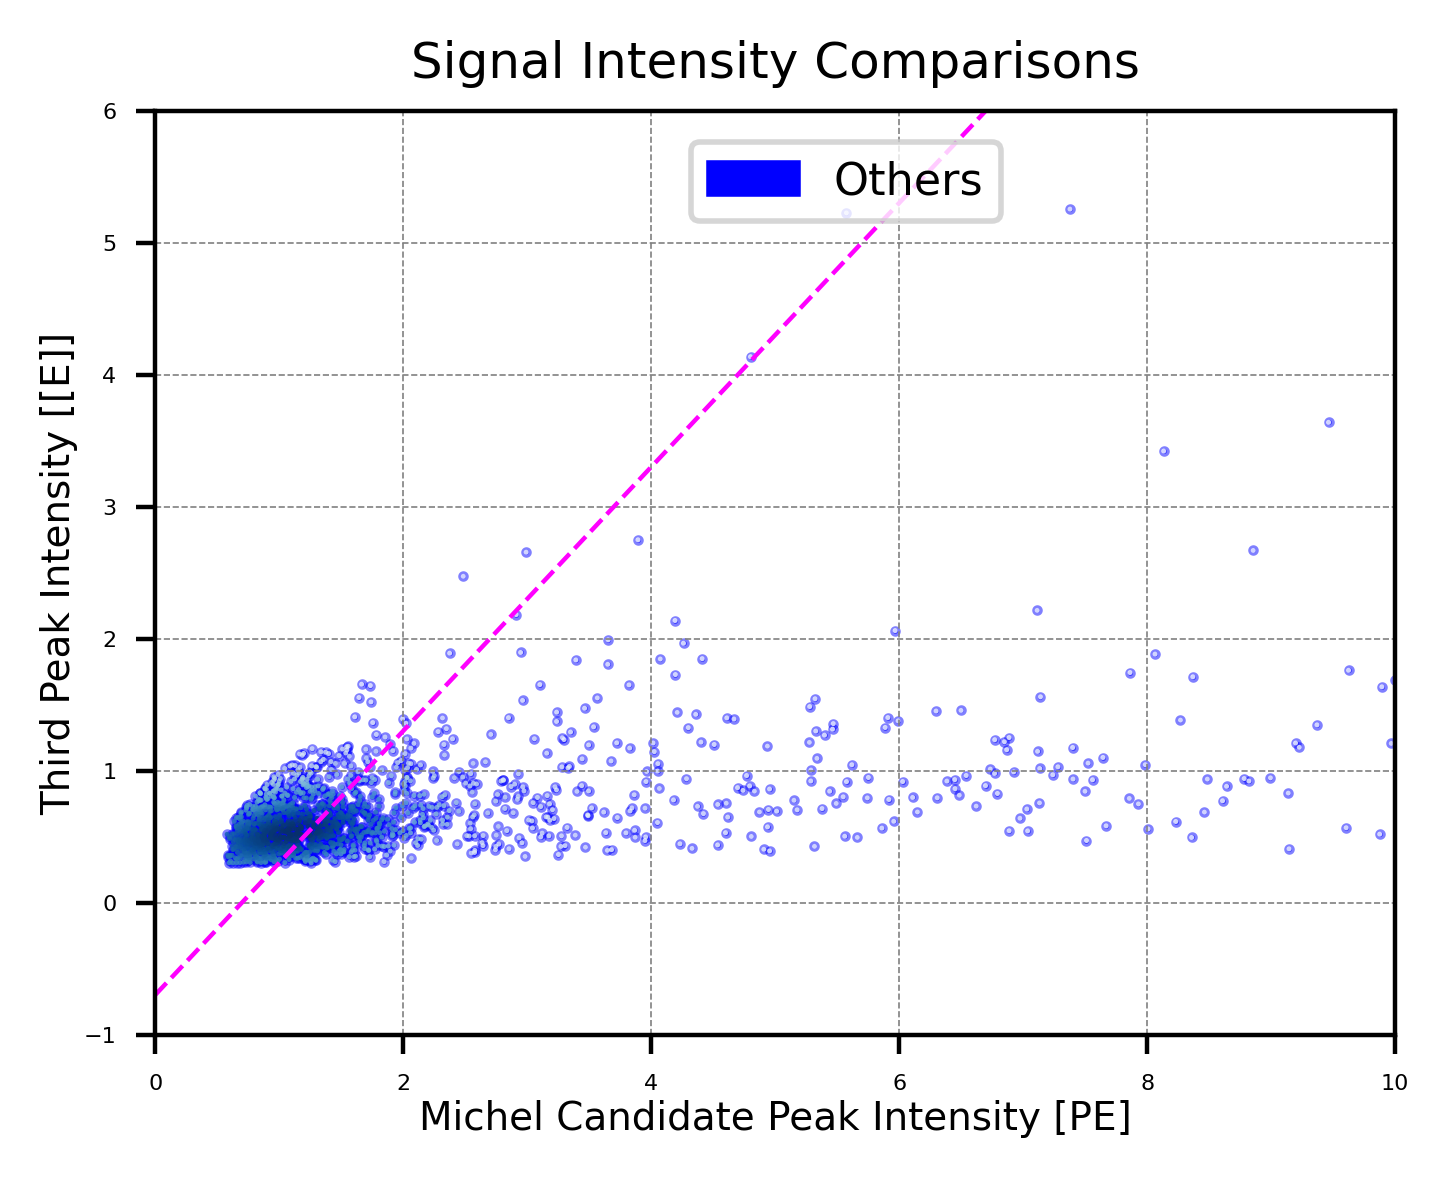

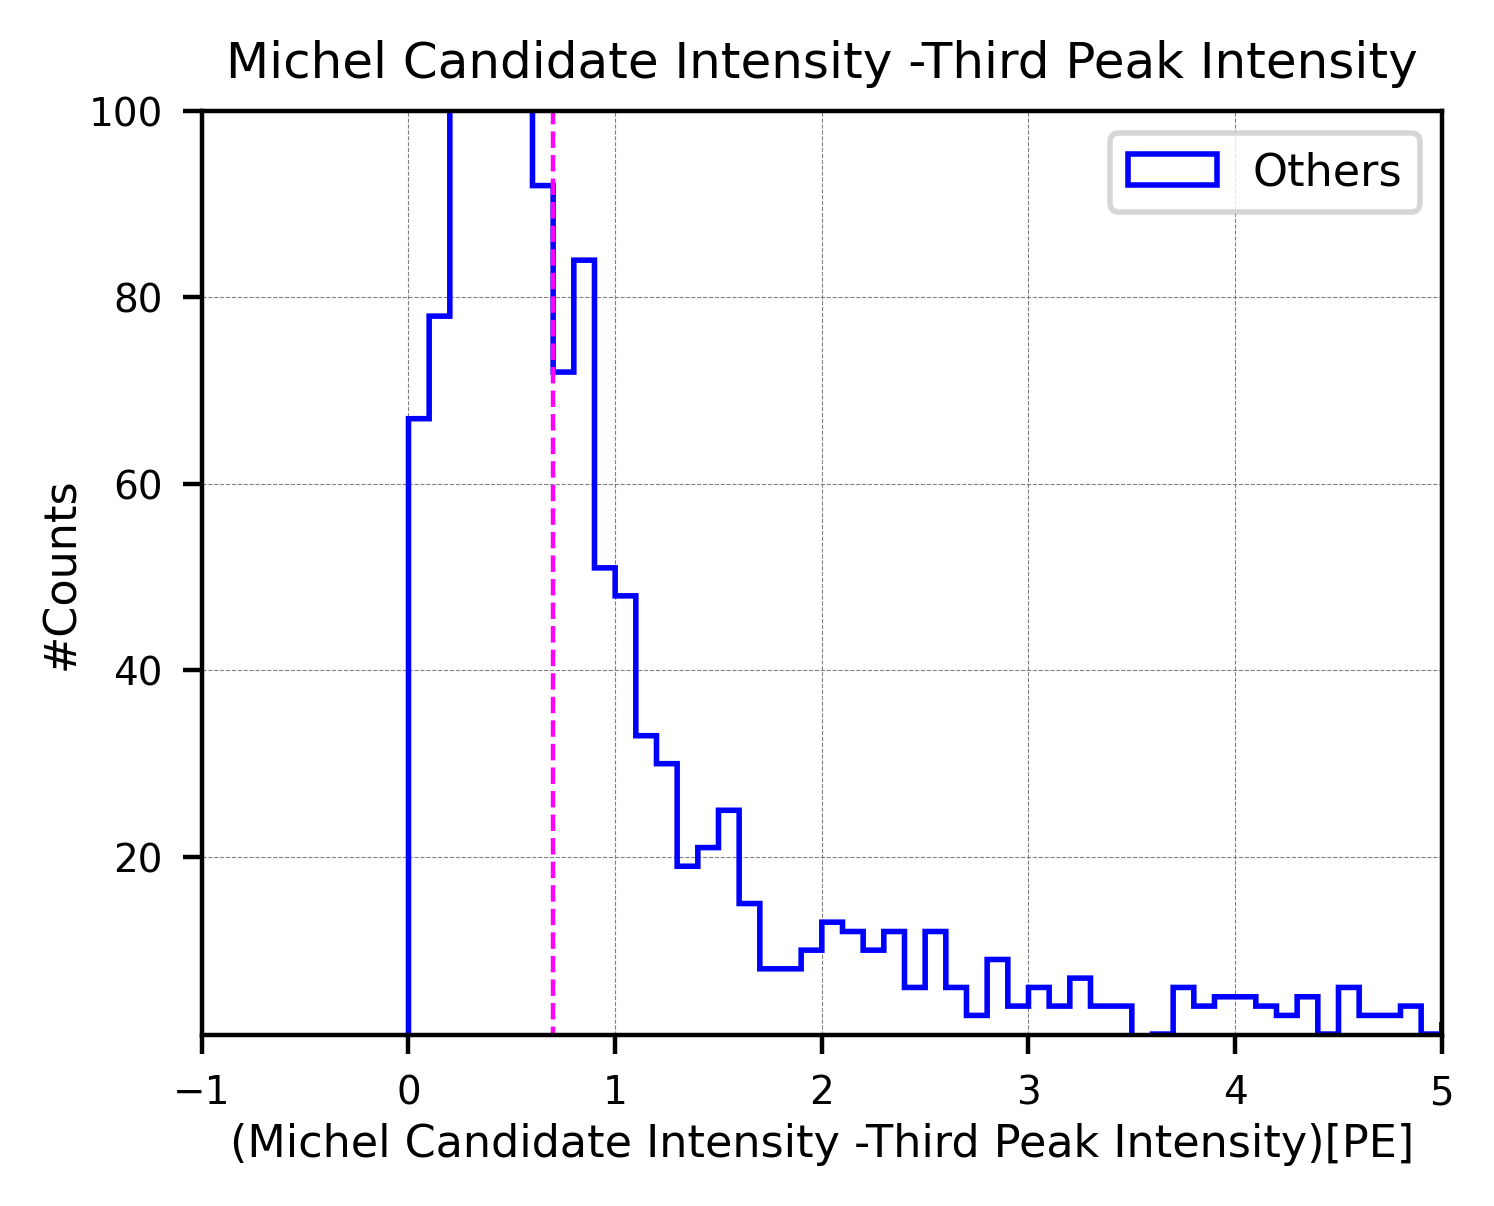

In [17]:
print("\nAfter Cut 7:--------------")

print("#event   : ", len(events_total_purify7))

miInt_total_purity7 = [ev.michel_intensity for ev in events_total_purify7]
thInt_total_purity7 = [ev.third_intensity for ev in events_total_purify7]

# Element-by-element difference (thInt - miInt)
subtract_total_purity7 = [mi - th for th, mi in zip(thInt_total_purity7, miInt_total_purity7)]


thre_diff = 0.7

#Shifted and scaled from MC & DATA comparison---
#miInt_DATA_scaled = 2.5 * np.array(miInt_diff) - 0.45

# filter the actual events
events_total_purify8 = [
    ev for ev in events_total_purify7
#    if thre_diff <  (ev.michel_intensity - ev.third_intensity)
    if thre_diff <  ((2.5 * ev.michel_intensity - 0.45) - ev.third_intensity)    
]
#-------------------------------


print("\nMichel 3rd Peaks intensity Diff (Cut 8):--------------")

print("Efficiency (cut8 / cut7): ", len(events_total_purify8), "/", len(events_total_purify7),
      "({:.2f}%)".format(len(events_total_purify8)/len(events_total_purify7)*100))










# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(miInt_total_purity7), np.array(thInt_total_purity7)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

plt.plot([0, 10], [-0.7, 9.3], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Others")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()









#(Michel Candidate Intensity -Third Peak Intensity) Distributions====================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(subtract_total_purity7, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.7, 0.7], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-1, 5)
plt.xlabel('(Michel Candidate Intensity -Third Peak Intensity)[PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  

### Cut 9: Space Cut along drift direction


After Cut 8:--------------
Event    :  1367

Drift Direction Cut (Cut 9):--------------
Efficiency (cut9 / cut8):  1164 / 1367 (85.15%)

Decay points distribution: 


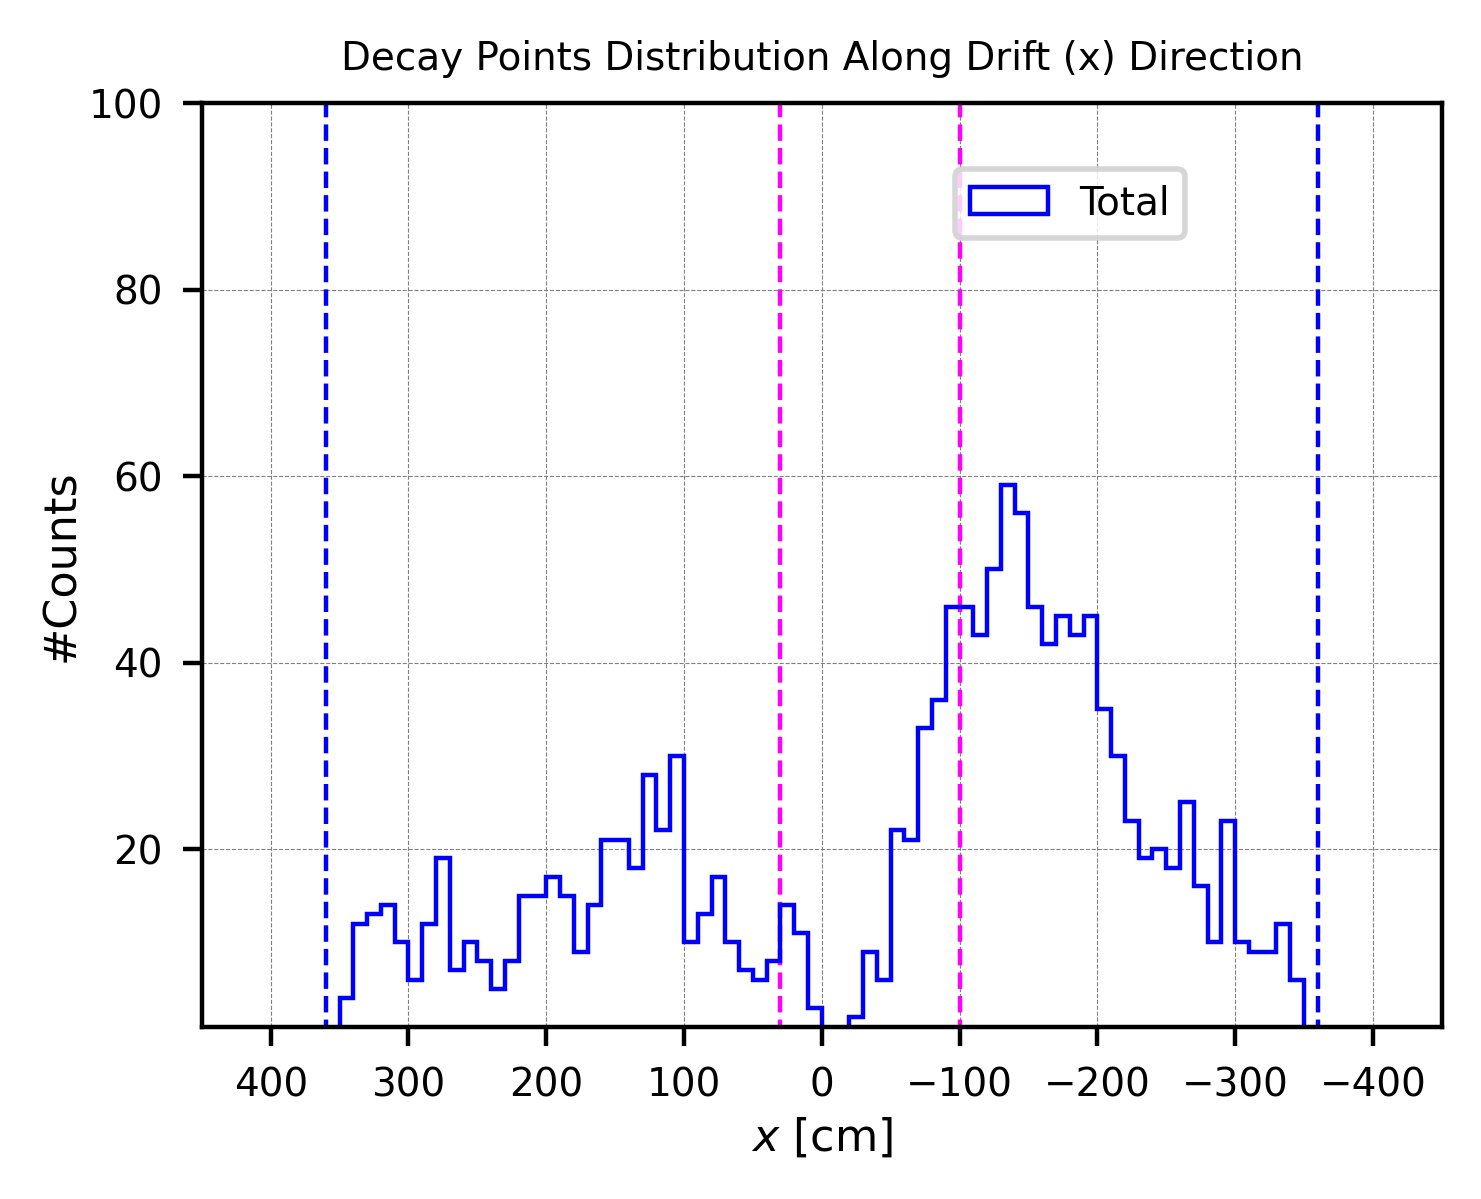

In [18]:
print("\nAfter Cut 8:--------------")

print("Event    : ", len(events_total_purify8))





posX_cut = 30
negX_cut = -100

# filter the actual events
events_total_purify9 = [
    ev for ev in events_total_purify8
    if posX_cut < ev.posX  or  ev.posX < negX_cut
]
#-------------------------------


print("\nDrift Direction Cut (Cut 9):--------------")

print("Efficiency (cut9 / cut8): ", len(events_total_purify9), "/", len(events_total_purify8),
      "({:.2f}%)".format(len(events_total_purify9)/len(events_total_purify8)*100))










posX_total_purify8 = [ev.posX for ev in events_total_purify8]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Cut line------
plt.plot([30, 30], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([-100, -100], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify8, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




<br />

#### Single Event Inspection:

In [19]:
# "Signal"
for ev in events_total_purify9:
    if ev.reco_lifetime >10000:
        print(ev)



PdsEventNew(muon_time=59, michel_time=782, muon_intensity=8.09922, michel_intensity=0.826431, third_intensity=0.717662, posX=-139.479, posY=199.32, posZ=337.572, eventID=100886, trackID=6, date=20251205, michel_score=0.768051, michel_hits=12, reco_lifetime=11568, michel_rise=0.10659624999999999, michel_drop=0.0673365625)
PdsEventNew(muon_time=60, michel_time=974, muon_intensity=54.4064, michel_intensity=8.13298, third_intensity=3.42033, posX=313.692, posY=277.011, posZ=127.541, eventID=123957, trackID=22, date=20251205, michel_score=0.999672, michel_hits=11, reco_lifetime=14624, michel_rise=1.3320750000000001, michel_drop=1.0464447368421055)
PdsEventNew(muon_time=60, michel_time=978, muon_intensity=21.0242, michel_intensity=2.57734, third_intensity=0.39514, posX=-133.346, posY=174.152, posZ=348.639, eventID=127142, trackID=6, date=20251205, michel_score=0.366462, michel_hits=5, reco_lifetime=14688, michel_rise=0.3995566666666666, michel_drop=0.16664078947368421)
PdsEventNew(muon_time=5

<br />
<br />

#### Features of final dataset (after purification 9):


Decay points distribution: 


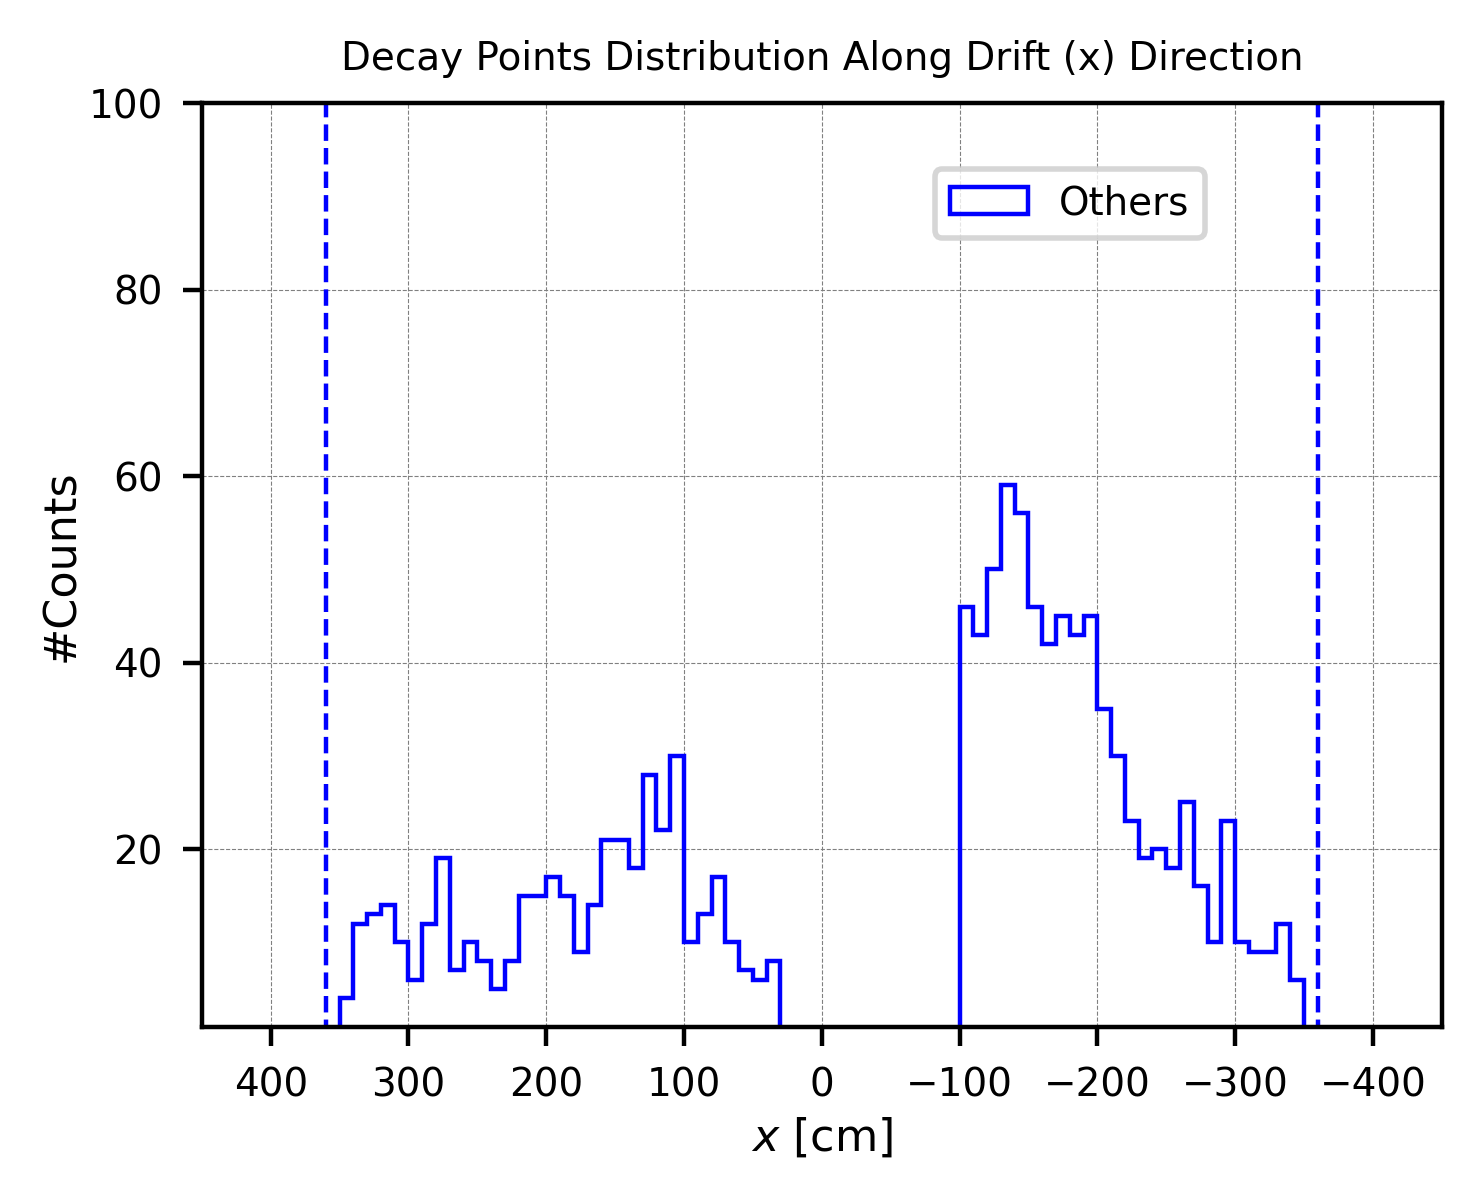

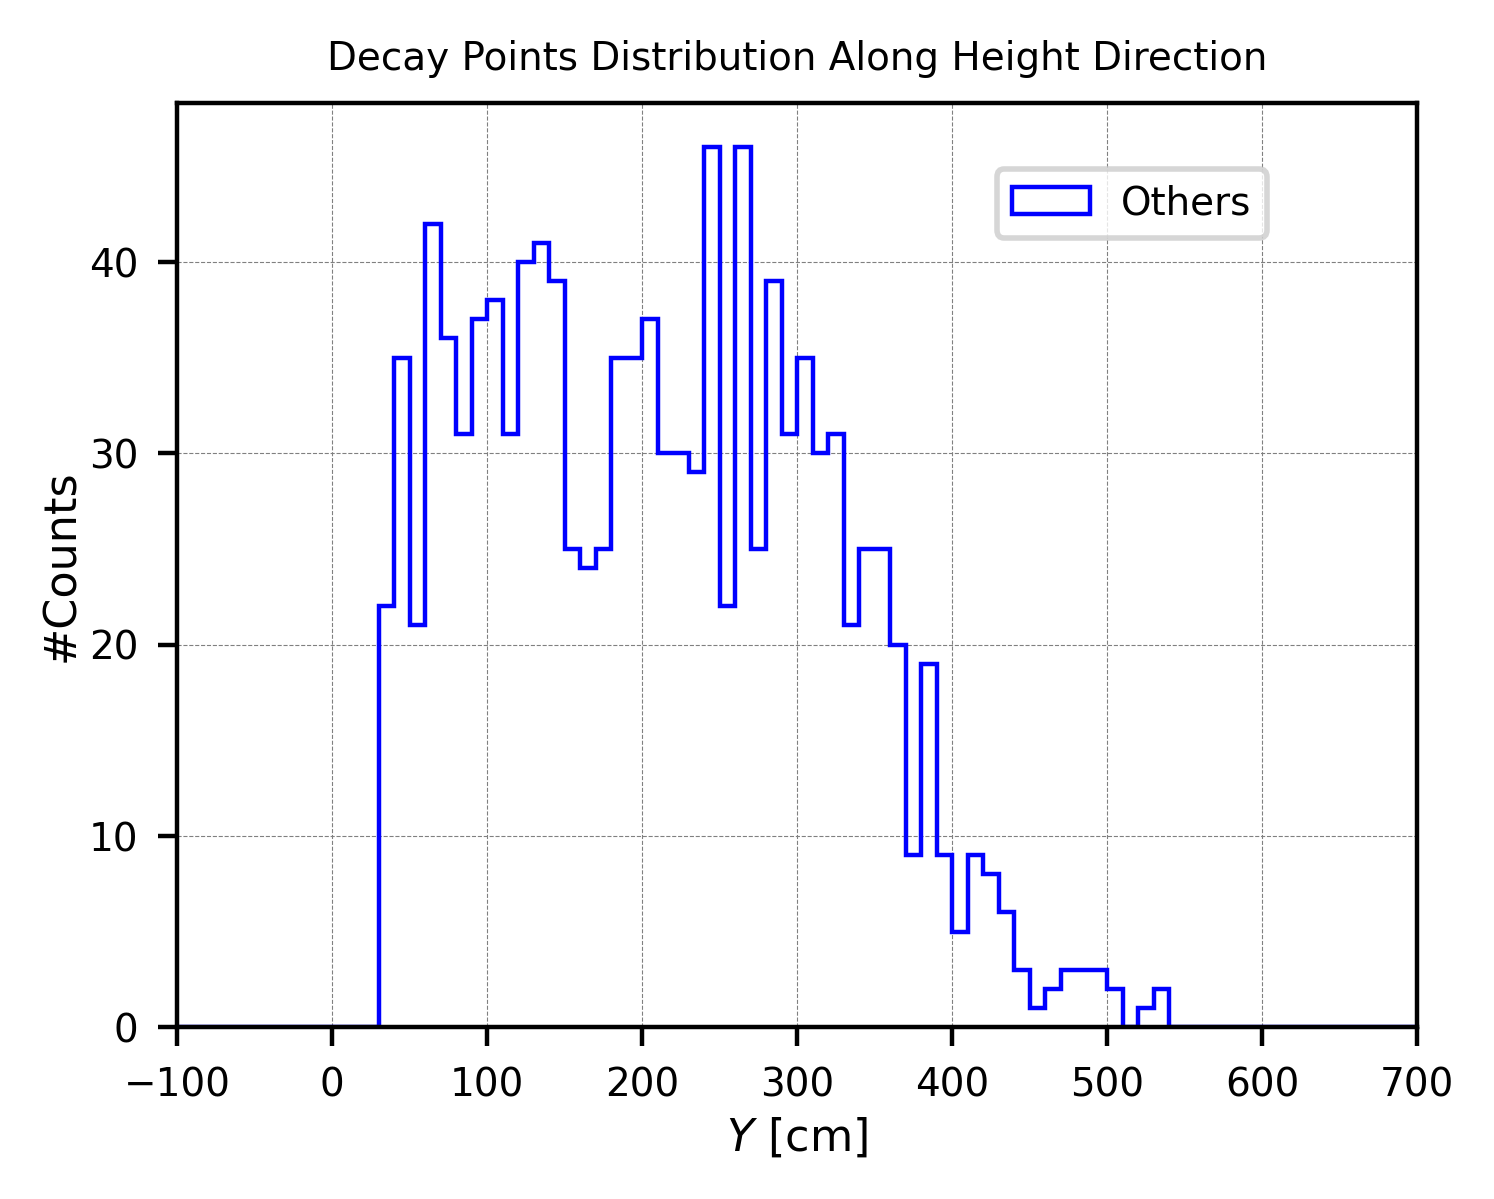

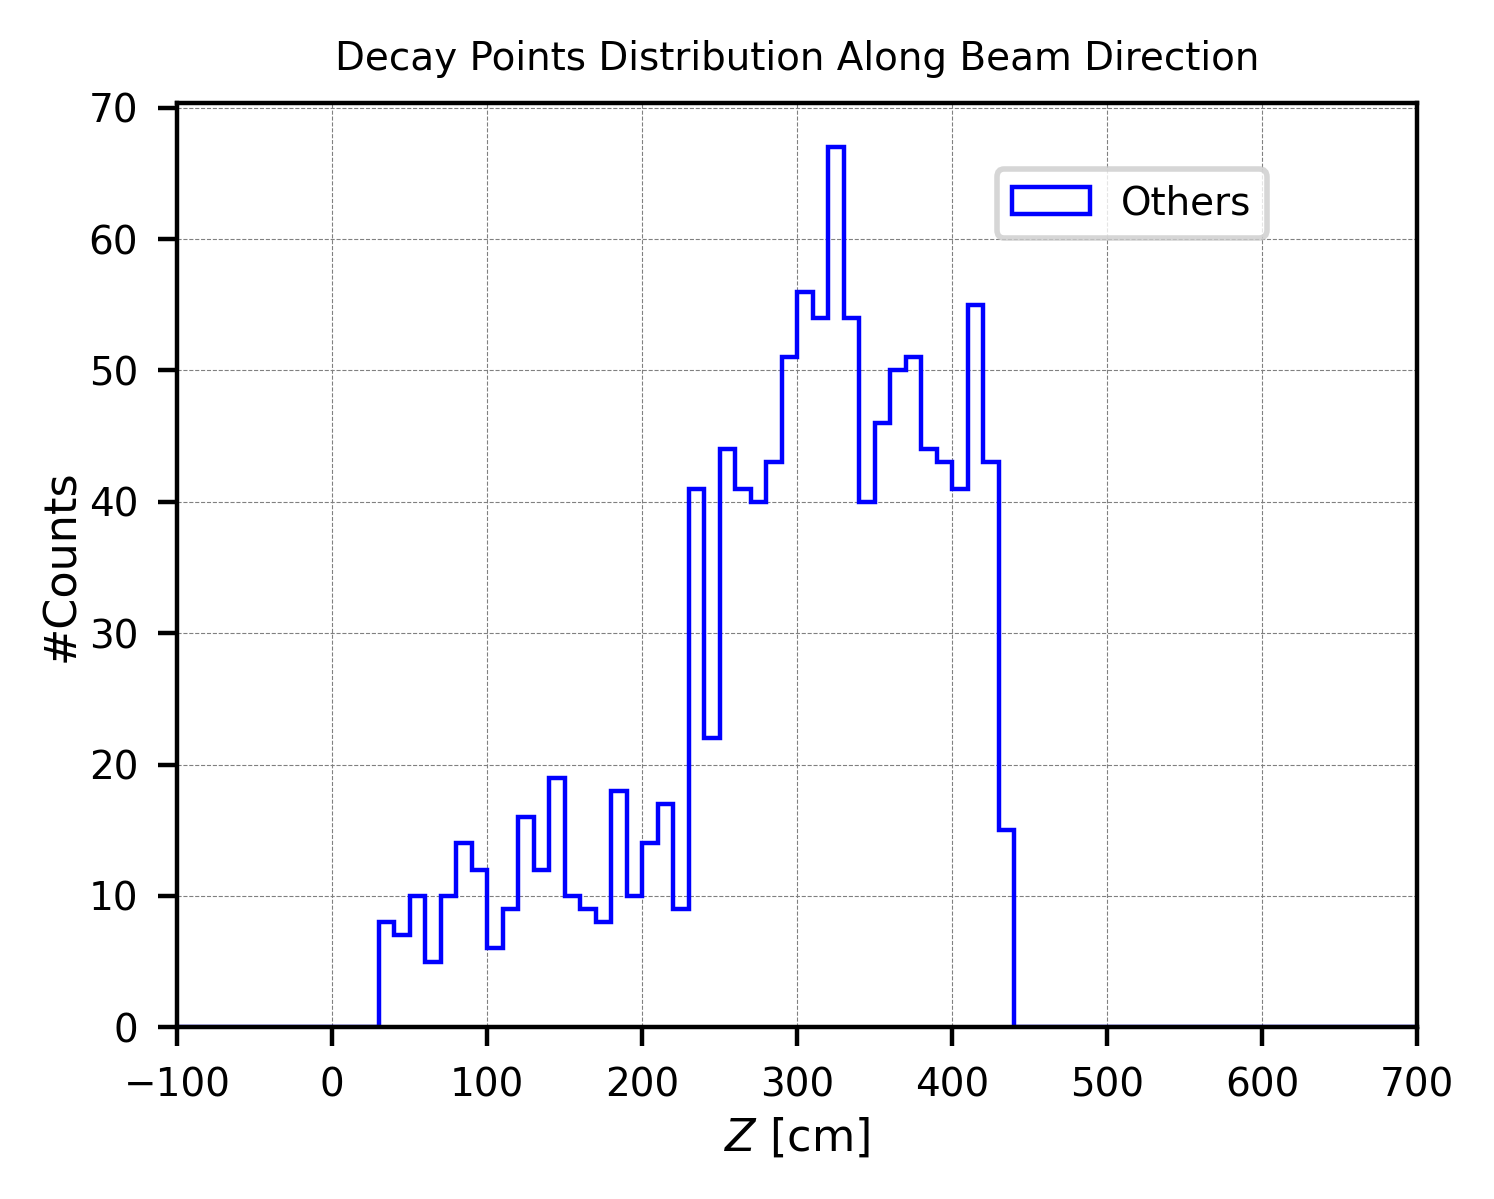

In [20]:

posX_total_purify9 = [ev.posX for ev in events_total_purify9]
posY_total_purify9 = [ev.posY for ev in events_total_purify9]
posZ_total_purify9 = [ev.posZ for ev in events_total_purify9]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Y distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posY_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Y$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Height Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Z distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posZ_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Z$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Beam Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 











# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


# ==========================================================
# Y–X plane plotting (Front View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line for field cage
# aux2 = [0, 610, 610, 0, 0]
# aux1 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posX_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posX_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posX_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posX_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posX_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(xmin, xmax)
# plt.ylim(-50, 660)
# plt.gca().invert_xaxis()  # Flip x-axis
# plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Front View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


# ==========================================================
# Z–X plane plotting (Top View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux1 = [0, 465, 465, 0, 0]
# aux2 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posX_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posX_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posX_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posX_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posX_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.ylim(xmin, xmax)
# plt.xlim(-50, 515)
# plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.title('Top View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()




# ==========================================================
# Y–Z plane plotting (Side View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY]
# aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(-50, 515)
# plt.ylim(-50, 660)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Side View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


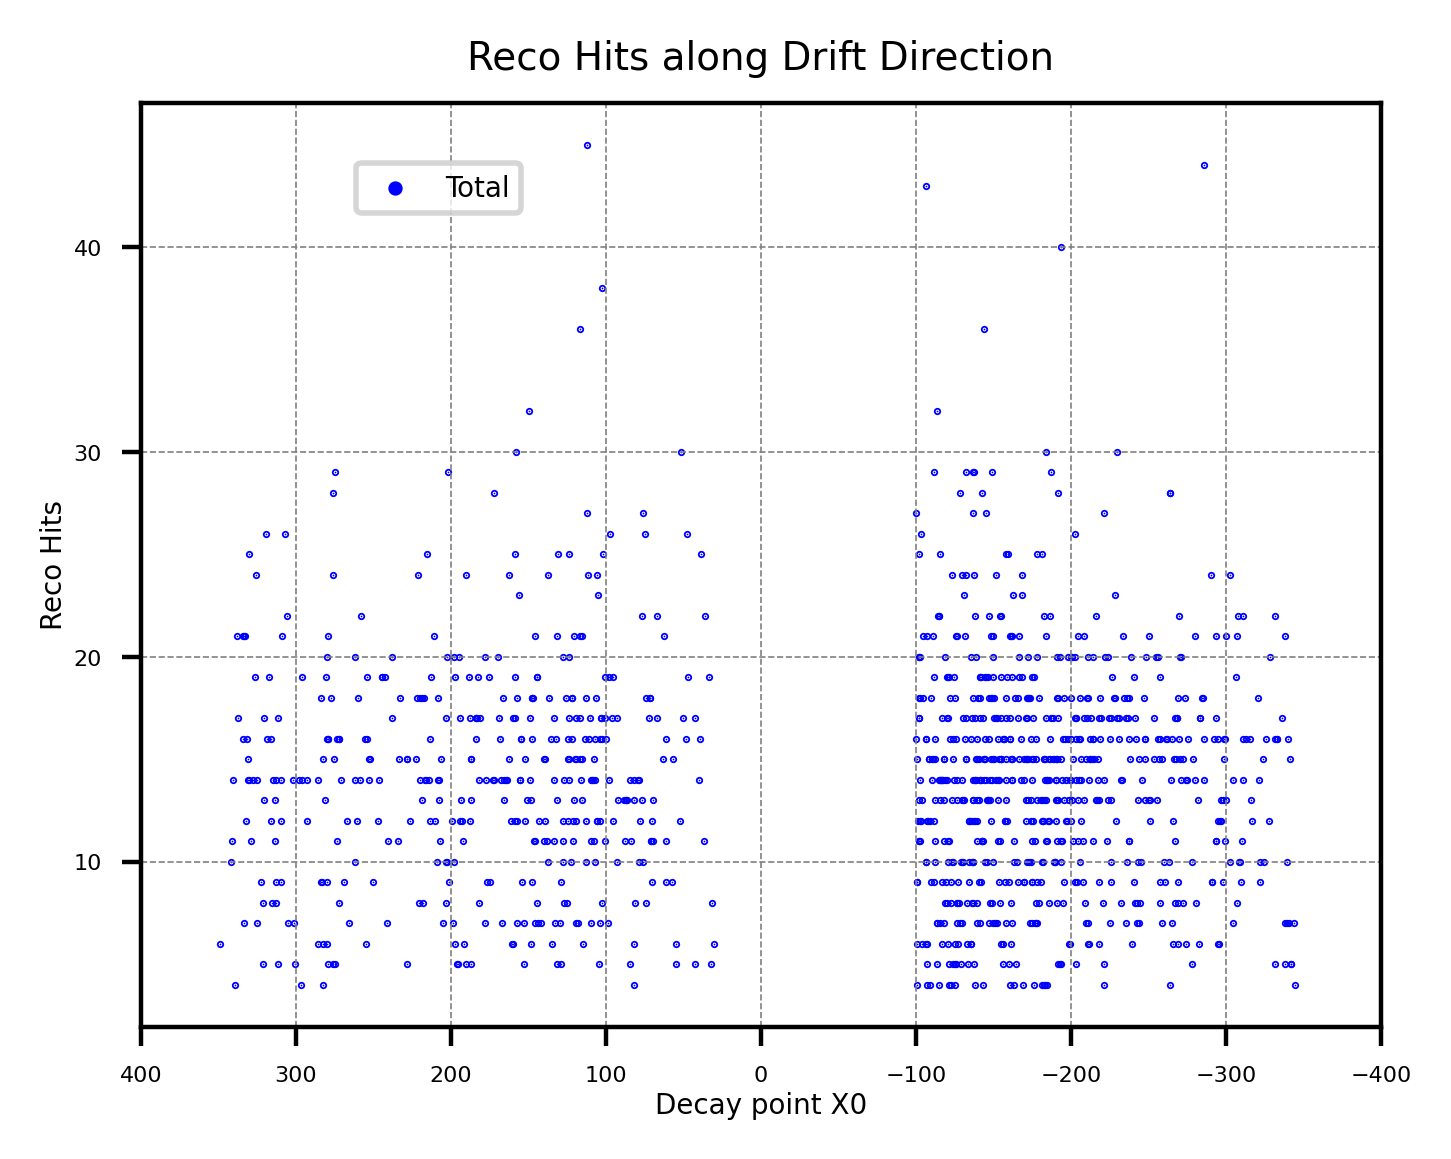


Michel Score Distribution: 


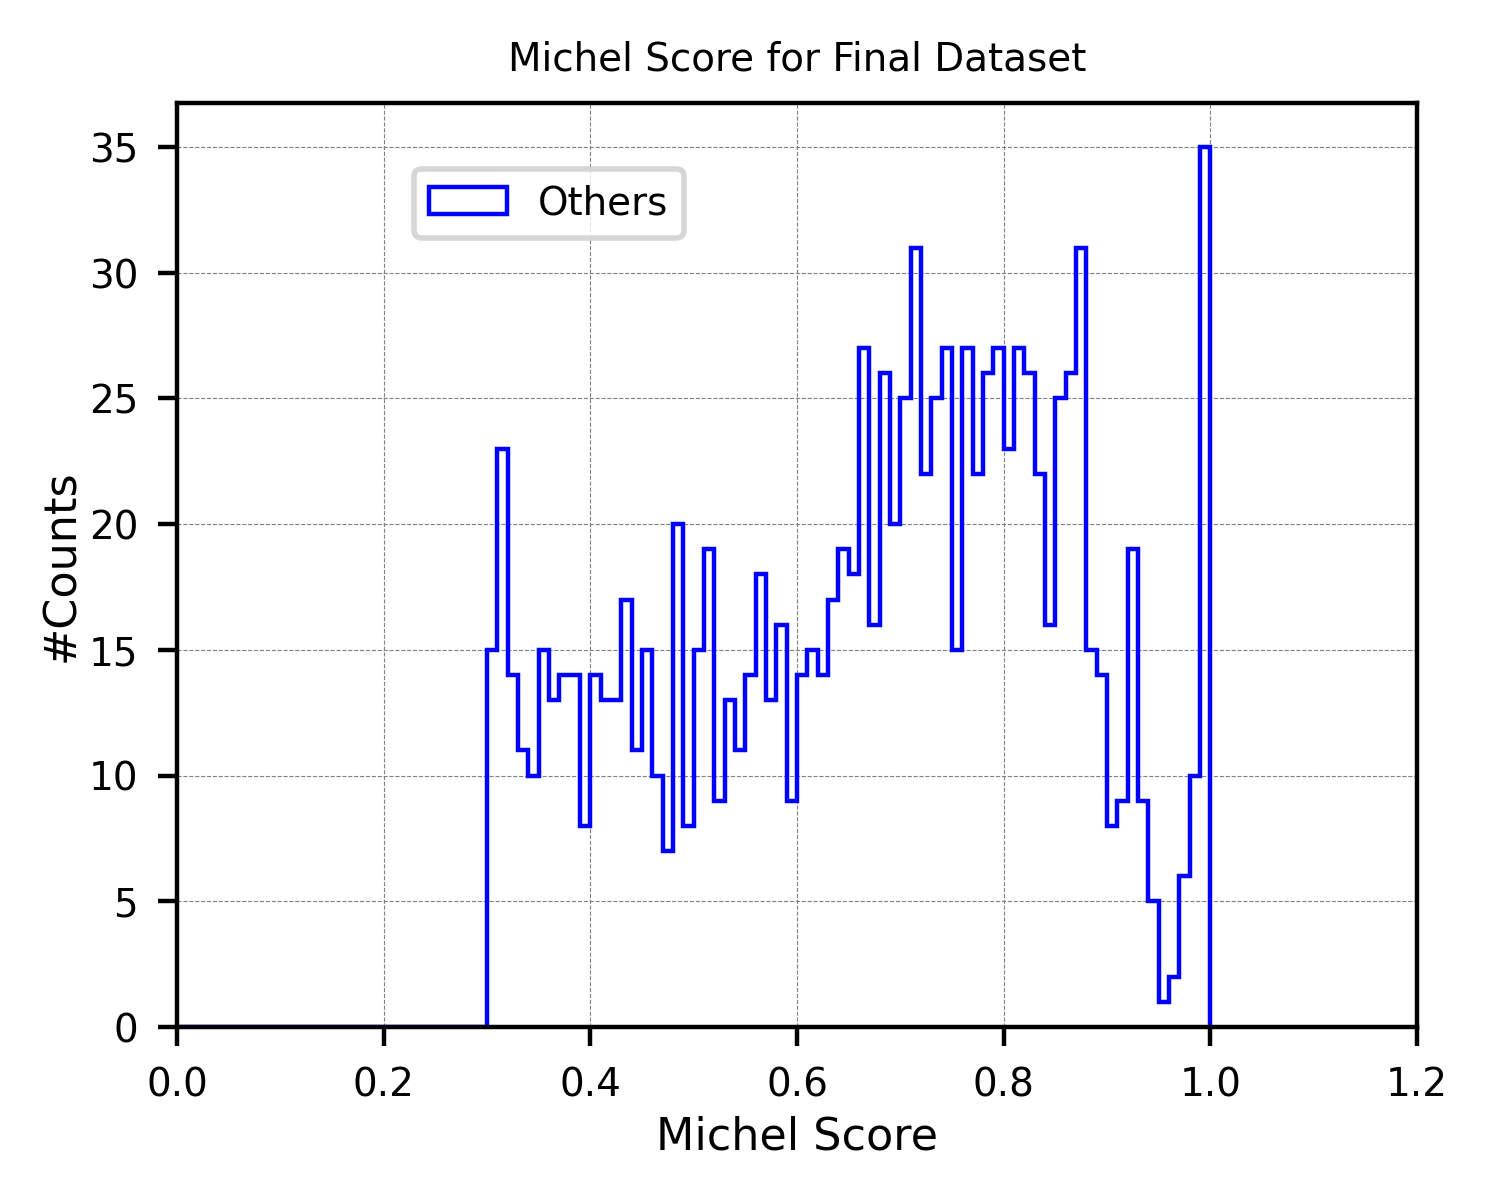


Michel Hits Distribution: 


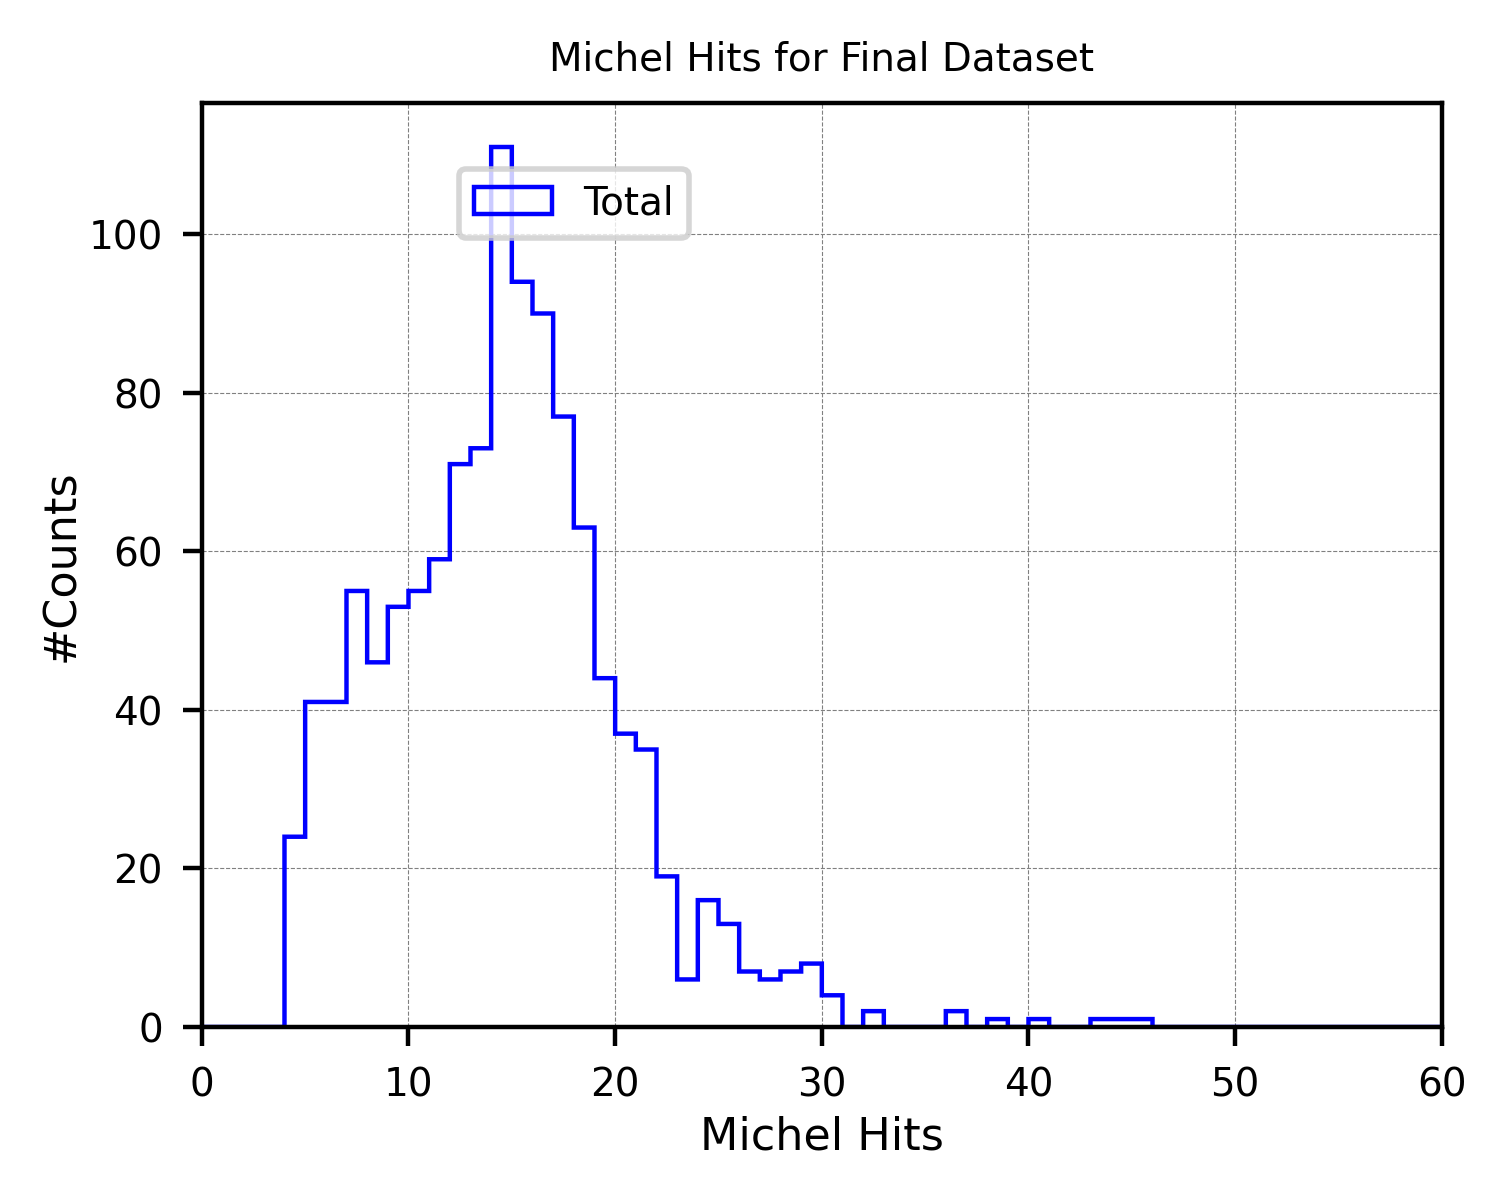

In [21]:

hits_total_purify9 = [ev.michel_hits for ev in events_total_purify9]

score_total_purify9 = [ev.michel_score for ev in events_total_purify9]











# ==========================================================
# reco hits VS posX
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(posX_total_purify9, hits_total_purify9, s=0.1, c='blue', alpha=1.0, label="Total")
#-----------------------

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0, 2000)
plt.ylabel('Reco Hits', labelpad=1, fontsize=5)
plt.xlabel('Decay point X0', labelpad=1, fontsize=5)
plt.title('Reco Hits along Drift Direction', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=6, markerscale=5, ncol=1, prop={'size':5})
plt.show()








#Michel Score distribution:==========================================
print("\nMichel Score Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 0.01
range_min =-1
range_max = 1
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(score_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")

#--------------------------------

plt.xlim(0, 1.2)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Score for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 







#Michel Hits distribution:==========================================
print("\nMichel Hits Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 1
range_min =0
range_max = 600
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(hits_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")

#--------------------------------

plt.xlim(0, 60)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Hits for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 





<br />
<br />
<br />

#### Lifetime Distribution of Final Dataset (purification 9):



For each event, +40ns for reco time


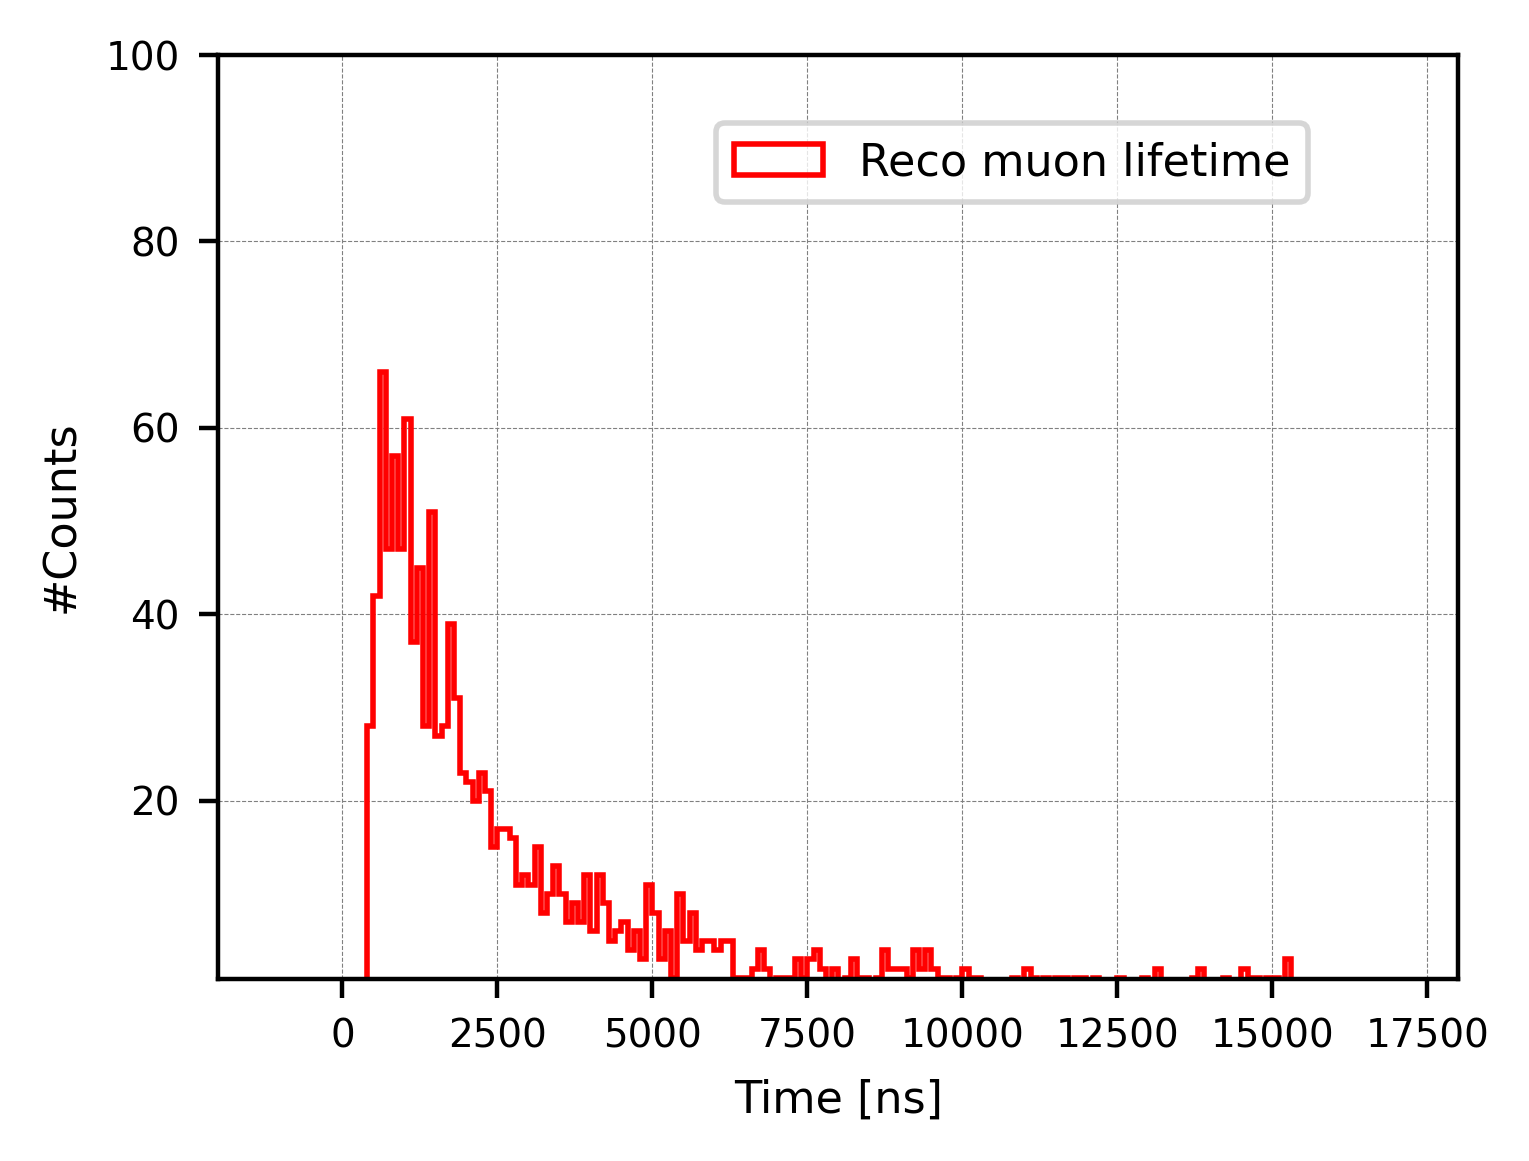

In [22]:

recoT_total_purify9 = [ev.reco_lifetime for ev in events_total_purify9]






#Shift +40ns=========================================
print("\n\n===================================")
print("For each event, +40ns for reco time")
recoT_total_purify9_shift40 = [x + 40 for x in recoT_total_purify9]


bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.figure(figsize=(4, 3), dpi=400)
#plt.hist(recoT_total_purify9, bins=bins, range=(range_min, range_max),
#         edgecolor='blue', histtype='step', linewidth=1.0,
#         label='Reco muon lifetime')

plt.hist(recoT_total_purify9_shift40, bins=bins, range=(range_min, range_max),
         edgecolor='red', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.xlim(-2000, 18000)
plt.ylim(0.9, 100)
#plt.yscale("log")
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()





<br />
<br />
<br />

### Apply detection efficiency:

Loaded efficiency ratio data.
[ 50. 150. 250. 350. 450.] [0.00556399 0.00838046 0.00828341 0.01603666 0.07741596] [0.00068297 0.00075247 0.00077946 0.00113625 0.0025038 ]


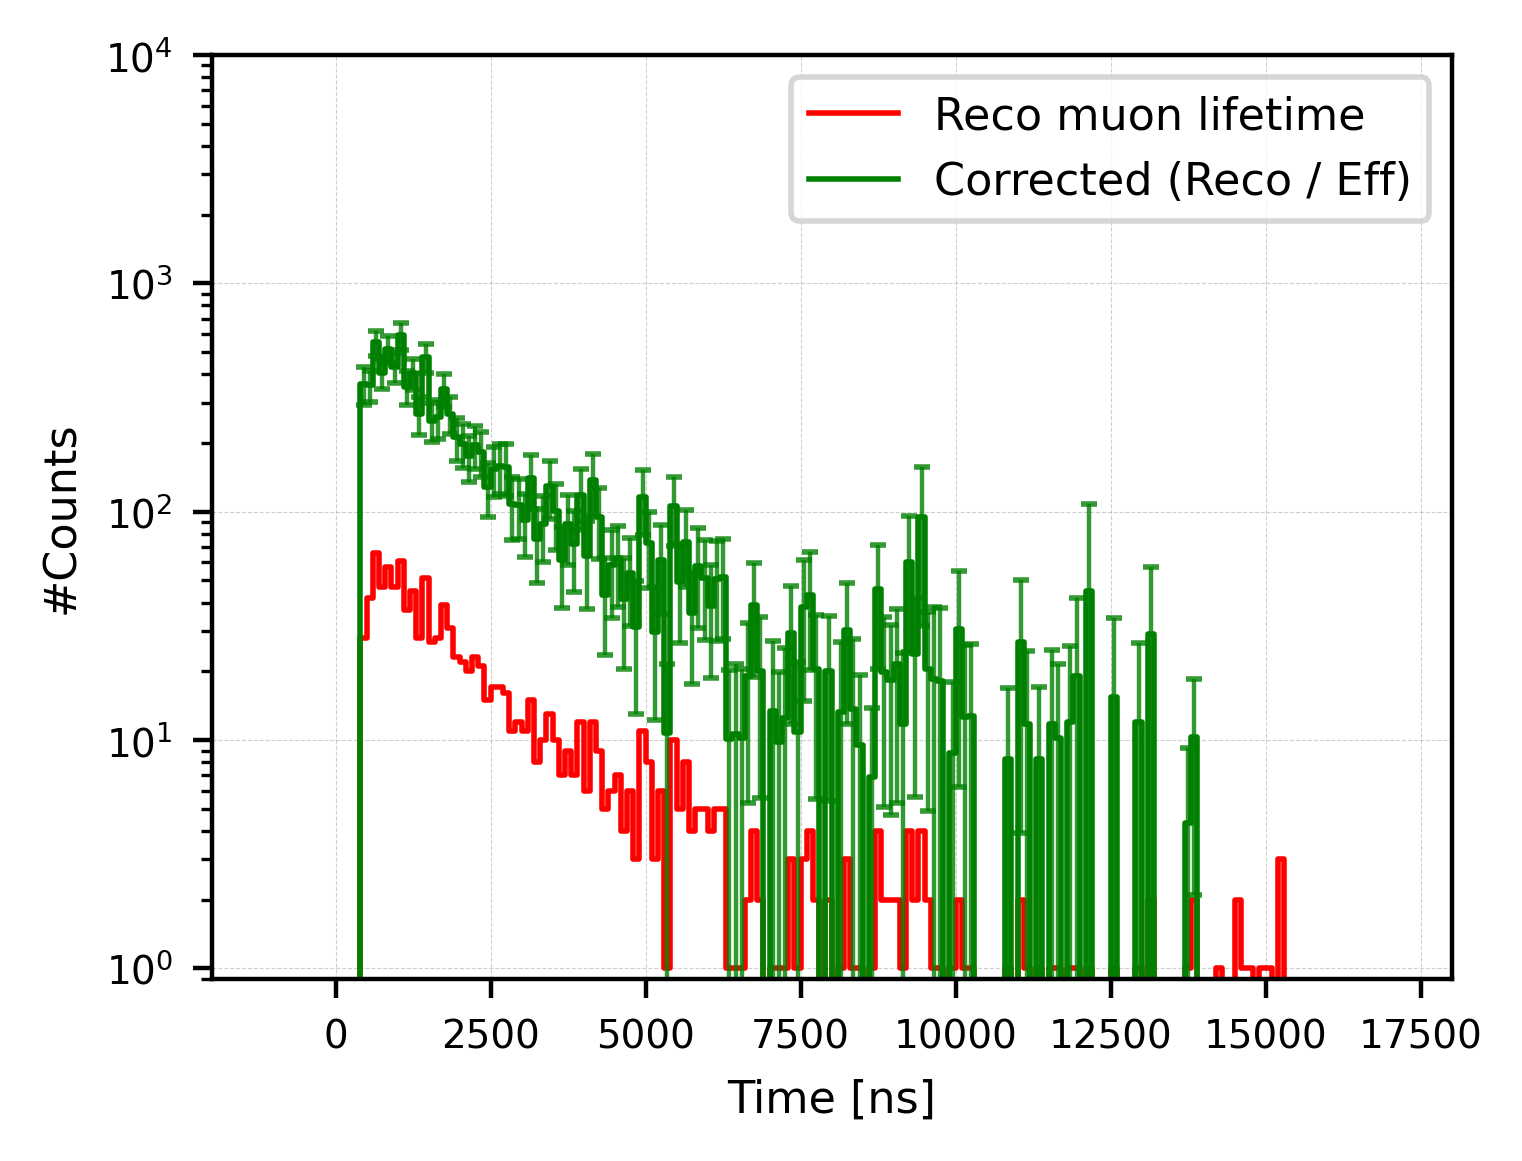

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Define bins (simple because range_min = 0)
# ============================================================
bin_width  = 100
range_min  = 0
range_max  = 16000

bins    = np.arange(range_min, range_max + bin_width, bin_width)
centers = (bins[:-1] + bins[1:]) / 2
nbins   = len(centers)

# ============================================================
# 2. Load lifetime efficiency values
# ============================================================
data = np.load("../../MC_new20251070s/michel_efficiency_ratios.npz")

eff_bins  = data["bins"]     # e.g. [50,150,250,...]
eff_ratio = data["ratio"]    # Final / Initial
eff_err   = data["error"]    # Uncertainty

print("Loaded efficiency ratio data.")
print(eff_bins[:5], eff_ratio[:5], eff_err[:5])

# ============================================================
# 3. Reco histogram (before correction)
# ============================================================
counts_reco, _ = np.histogram(
    recoT_total_purify9_shift40,
    bins=bins,
    range=(range_min, range_max)
)

sigma_reco = np.sqrt(counts_reco)

# ============================================================
# 4. Align efficiency values with histogram bins
# ============================================================
eff_full     = np.zeros(nbins)
eff_err_full = np.zeros(nbins)

# Direct index matching (valid because centers begin at 50,150,...)
for i, c in enumerate(centers):
    idx = np.where(eff_bins == c)[0]
    if len(idx) > 0:
        eff_full[i]     = eff_ratio[idx[0]]
        eff_err_full[i] = eff_err[idx[0]]

# ============================================================
# 5. Efficiency correction with full A/B error propagation
# ============================================================
R_corr       = np.zeros(nbins)
sigma_R_corr = np.zeros(nbins)

valid = eff_full > 0

R_corr[valid] = counts_reco[valid] / eff_full[valid]

sigma_R_corr[valid] = np.sqrt(
    (sigma_reco[valid] / eff_full[valid])**2 +
    ((counts_reco[valid] * eff_err_full[valid]) /
     eff_full[valid]**2)**2
)

# ============================================================
# 6. Plot raw and corrected histograms
# ============================================================
plt.figure(figsize=(4, 3), dpi=400)

# -- Raw reco histogram --
plt.step(bins, np.append(counts_reco, counts_reco[-1]),
         where='post', color='red', lw=1.0, label='Reco muon lifetime')

# -- Corrected histogram --
plt.step(bins, np.append(R_corr, R_corr[-1]),
         where='post', color='green', lw=1.0, label='Corrected (Reco / Eff)')

plt.errorbar(
    centers, R_corr, sigma_R_corr,
    fmt='none', ecolor='green', elinewidth=0.8, capsize=1.5, alpha=0.8
)

# Style
plt.xlim(-2000, 18000)
plt.ylim(0.9, 10000)
plt.yscale('log')
plt.xlabel("Time [ns]", fontsize=8)
plt.ylabel("#Counts", fontsize=8)
plt.grid(ls="--", lw=0.2, alpha=0.6)
plt.tick_params(labelsize=7)
plt.legend(fontsize=8, loc='upper right')

plt.show()




<br />
<br />
<br />
<br />

## Apply fitting:

### Fitting function (I):

$$
f(t) = \frac{N}{\tau_1} e^{-t/\tau_1} \;+\; \frac{N r}{\tau_2} e^{-t/\tau_2}
$$

#### For bin [a, b]:
$$
\mu(a,b) = 
N \left( e^{-a/\tau_1} - e^{-b/\tau_1} \right)
+ N r \left( e^{-a/\tau_2} - e^{-b/\tau_2} \right)
$$

##### Combined fitting (fluctuating $r$) (Current MAIN result):

##### minuit minimization model applied

#### Define function:

In [33]:
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 3. Define model and fitting helper
# ============================================================
def exp2_integrated(bin_edges, N, tau1, ratio, tau2=2197.0):
    """
    Expected bin counts for the model:
        f(t) = N * [ exp(-t/tau1)/tau1 + ratio * exp(-t/tau2)/tau2 ]
    Integrated over each bin [a,b]:
        mu = N * [ (e^{-a/tau1} - e^{-b/tau1}) + ratio*(e^{-a/tau2} - e^{-b/tau2}) ]
    Here N is the normalization of the PDF component (not simply total counts).
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)


#### MINUIT minimization model:

In [34]:
from iminuit import Minuit

# Binned maximum-likelihood (Poisson deviance) fitting using MINUIT (MIGRAD) ===
def fit_and_draw_binnedML_minuit(ax, ax_resid, sample, label_prefix,
                                fit_range=(400, 10000),
                                hist_color="black", fit_color="red",
                                tau1_init=1000.0, ratio_init=4.0, tau2=2197.0):

    # Histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fitting window
    m = (centers >= fit_range[0]) & (centers <= fit_range[1])
    y = counts[m].astype(float)  # n_i
    if len(y) < 3:
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color)
        return None

    edges_fit = bin_edges[m.nonzero()[0][0] : m.nonzero()[0][-1] + 2]

    # --- Binned Poisson deviance (PDG Eq. 40.16) ---
    # D(theta) = 2 * sum_i [ mu_i - n_i + n_i * ln(n_i/mu_i) ]
    # convention: n_i ln(n_i/mu_i) = 0 for n_i = 0
    eps = 1e-12

    def mu_model(N, tau1, ratio):
        mu = exp2_integrated(edges_fit, N, tau1, ratio, tau2=tau2)
        return np.maximum(mu, eps)

    def deviance(N, tau1, ratio):
        mu = mu_model(N, tau1, ratio)
        n = y
        term = np.zeros_like(n, dtype=float)
        nz = n > 0
        term[nz] = n[nz] * np.log(n[nz] / mu[nz])
        return 2.0 * np.sum(mu - n + term)


    # Initial guesses--------------------------------------------
    N0 = float(np.sum(y)) / (1.0 + ratio_init)
    tau1_0 = float(tau1_init)
    ratio_0 = float(ratio_init)
    # -----------------------------------------------------------

    # --- MINUIT minimization (MIGRAD) ---
    mnt = Minuit(deviance, N=N0, tau1=tau1_0, ratio=ratio_0)

    # Limits (bounds)
    mnt.limits["N"] = (0.0, None)
    mnt.limits["tau1"] = (1e-6, None)
    mnt.limits["ratio"] = (0.0, None)

    # Recommended in HEP for -2 ln L functions:
    # errordef = 1 means 1-sigma corresponds to Δf = 1
    # Here f = D = -2 ln L, so errordef should be 1.
    mnt.errordef = 1.0

    migrad_res = mnt.migrad()
    if not migrad_res.valid:
        print(f"[{label_prefix}] MINUIT MIGRAD failed or not valid.")
        ax.hist(sample, bins=bins, range=(range_min, range_max),
                histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")
        return None

    # Covariance / HESSE errors
    mnt.hesse()

    # Fitted values and errors
    N_fit = float(mnt.values["N"])
    tau1_fit = float(mnt.values["tau1"])
    ratio_fit = float(mnt.values["ratio"])

    N_err = float(mnt.errors["N"]) if mnt.errors["N"] is not None else np.nan
    tau1_err = float(mnt.errors["tau1"]) if mnt.errors["tau1"] is not None else np.nan
    ratio_err = float(mnt.errors["ratio"]) if mnt.errors["ratio"] is not None else np.nan

    # Goodness-of-fit-like number: deviance at min
    D_min = float(mnt.fval)
    ndf = len(y) - 3

    # Residuals: signed deviance residuals (Poisson-appropriate)
    mu_fit_bins = mu_model(N_fit, tau1_fit, ratio_fit)
    n = y
    di = np.zeros_like(n, dtype=float)
    nz = n > 0
    di[nz] = 2.0 * (mu_fit_bins[nz] - n[nz] + n[nz] * np.log(n[nz] / mu_fit_bins[nz]))
    di[~nz] = 2.0 * mu_fit_bins[~nz]
    pulls = np.sign(n - mu_fit_bins) * np.sqrt(np.maximum(di, 0.0))

    # Smooth curve for visualization (consistent with integrated model)
    x_edges_plot = bins  # use the SAME bin edges as the histogram
    mu_plot = exp2_integrated(x_edges_plot, N_fit, tau1_fit, ratio_fit, tau2=tau2)
    x_centers_plot = 0.5 * (x_edges_plot[:-1] + x_edges_plot[1:])

    # Components (pdf-like * bin width; OK for visualization)
    # If you want fully consistent "integrated components", tell me and I’ll provide that version.
    x_dense = np.linspace(fit_range[0], fit_range[1], 400)
    y_fast = (N_fit / tau1_fit) * np.exp(-x_dense / tau1_fit) * bin_width
    y_slow = (N_fit * ratio_fit / tau2) * np.exp(-x_dense / tau2) * bin_width

    # Draw histogram + fit
    ax.hist(sample, bins=bins, range=(range_min, range_max),
            histtype='step', linewidth=0.8, color=hist_color, label=f"{label_prefix} data")

    fit_min, fit_max = fit_range
    mask_plot = (x_centers_plot >= fit_min) & (x_centers_plot <= fit_max)
    ax.plot(x_centers_plot[mask_plot], mu_plot[mask_plot],
            color=fit_color, linestyle="--", linewidth=1.2,
            label=(rf"$N={N_fit:.1f}\pm{N_err:.1f}$" + "\n"
                   + rf"$\tau_1={tau1_fit:.1f}\pm{tau1_err:.1f}$ ns" + "\n"
                   + rf"$r={ratio_fit:.2f}\pm{ratio_err:.2f}$" + "\n"
                   + rf"$\tau_2={tau2}$ ns (fixed)" + "\n"
                   + rf"$D/\mathrm{{ndf}} = {D_min:.1f}/{ndf}$"))

    ax.plot(x_dense, y_fast,
            color=fit_color, linestyle=":", linewidth=1.0,
            label=rf"$\mu^-$ term: $(N/\tau_1)e^{{-t/\tau_1}}$")

    ax.plot(x_dense, y_slow,
            color=fit_color, linestyle="-.", linewidth=1.0,
            label=rf"$\mu^+$ term: $(Nr/\tau_2)e^{{-t/\tau_2}}$")

    # Residuals panel
    x = centers[m]
    ax_resid.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax_resid.errorbar(x, pulls, yerr=np.ones_like(pulls), fmt='o',
                      color=fit_color, markersize=3, elinewidth=0.7, capsize=1.5)

    # Print results
    n_in_fit = np.sum((np.asarray(sample) >= fit_range[0]) & (np.asarray(sample) <= fit_range[1]))
    print(f"\n[{label_prefix}] Fit range = ({fit_range[0]}, {fit_range[1]}) ns")
    print(f"  Number of events in fit range: {n_in_fit}")
    print(f"  Fit results (MINUIT/MIGRAD + HESSE):")
    print(f"    τ₁ = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"    r  = {ratio_fit:.3f} ± {ratio_err:.3f}")
    print(f"    D/ndf = {D_min:.1f}/{ndf}")

    return tau1_fit, tau1_err, ratio_fit, ratio_err, D_min, ndf

#### Fitting & drawing:

In [ ]:
# ============================================================
# 4. Run the fit and draw
# ============================================================
bin_width = 100
range_min, range_max = -2000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

fig = plt.figure(figsize=(5, 4), dpi=400, constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax)



# Maximum Likelihood Method------------------
fit_and_draw_binnedML_minuit(ax, ax_resid, np.asarray(lifetime_trueMichel_initial), "Combined",
             fit_range=(400, 12500), #Fitting range================================================
             hist_color="black", fit_color="red",
             tau1_init=1000.0, ratio_init=5.0, tau2=2197.0)





# ============================================================
# 5. Style and display
# ============================================================
ax.set_yscale("log")
ax.set_ylim(0.9, 100000)
ax.set_ylabel("#Counts", fontsize=8)
ax.tick_params(labelbottom=False)
ax.legend(fontsize=7)
ax.grid(linestyle="--", linewidth=0.3, alpha=0.6)

ax_resid.set_xlim(-2000, 18000)
ax_resid.set_xlabel("Lifetime [ns]", fontsize=8)
ax_resid.set_ylabel(r"$(\mathrm{data} - \mathrm{fit})/\sigma$", fontsize=8)
ax_resid.grid(linestyle="--", linewidth=0.3, alpha=0.6)

plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Integrated double exponential model
# ============================================================
def exp2_integrated(bin_edges, N, tau1, ratio, tau2=2197.0):
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)

# ============================================================
# χ² least-squares fit with custom range
# ============================================================
def fit_double_exp(bin_edges, y, yerr, fit_range=(400, 10000), tau2=2197.0):
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width   = bin_edges[1] - bin_edges[0]

    # Select χ² fit region
    mask = (
        (bin_centers >= fit_range[0]) &
        (bin_centers <= fit_range[1]) &
        (y > 0) & np.isfinite(y)
    )

    if not np.any(mask):
        raise RuntimeError("❌ No valid bins in selected fit range.")

    i0, i1 = np.where(mask)[0][[0, -1]]
    edges_fit = bin_edges[i0 : i1 + 2]
    y_fit     = y[mask]
    sigma_fit = np.clip(yerr[mask], 1.0, None)

    # Initial guesses
    N0 = np.sum(y_fit)
    tau1_0 = 1000.0
    ratio_0 = 4.5

    # Perform fit
    popt, pcov = curve_fit(
        lambda edges, N, tau1, ratio: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y_fit,
        p0=[N0, tau1_0, ratio_0],
        sigma=sigma_fit,
        absolute_sigma=True,
        bounds=([0, 1e-6, 0], [np.inf, np.inf, 20.0])
    )

    N_fit, tau1_fit, ratio_fit = popt
    N_err, tau1_err, ratio_err = np.sqrt(np.diag(pcov))

    # Compute χ²
    model_fit = exp2_integrated(edges_fit, *popt, tau2)
    chi2 = np.sum(((y_fit - model_fit) / sigma_fit)**2)
    ndf = len(y_fit) - len(popt)

    # ---------------- Plot ----------------
    plt.figure(figsize=(4,3), dpi=400)

    # Data
    centers = bin_centers
    plt.step(bin_edges, np.append(y, y[-1]),
             where='post', color='green', lw=1.0, label='Corrected μ lifetime')
    plt.errorbar(centers, y, yerr, fmt='none', ecolor='green', alpha=0.7)

    # Fit curve
    xs = np.linspace(fit_range[0], fit_range[1], 500)
    ys = (
        (N_fit/tau1_fit)*np.exp(-xs/tau1_fit)*bin_width +
        (N_fit*ratio_fit/tau2)*np.exp(-xs/tau2)*bin_width
    )

    plt.plot(xs, ys, 'r--', lw=1.2,
             label=(r"Fit: $N(e^{-t/\tau_1} + r e^{-t/\tau_2})$" "\n"
                    + rf"$\tau_1 = {tau1_fit:.1f} \pm {tau1_err:.1f}$ ns" "\n"
                    + rf"$r = {ratio_fit:.2f} \pm {ratio_err:.2f}$" "\n"
                    + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"))

    plt.xlim(0, 10000)
    plt.ylim(0.9, 1000)
    #plt.yscale("log")
    plt.grid(ls='--', lw=0.3, alpha=0.6)
    plt.xlabel("Time [ns]")
    plt.ylabel("#Counts")
    plt.legend(fontsize=8)
    plt.show()

    # Return results
    return {
        "N": (N_fit, N_err),
        "tau1": (tau1_fit, tau1_err),
        "ratio": (ratio_fit, ratio_err),
        "tau2": tau2,
        "chi2": chi2,
        "ndf": ndf,
        "chi2_ndf": chi2/ndf
    }


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Integrated double exponential model
# ============================================================
def exp2_integrated(bin_edges, N, tau1, ratio, tau2=2197.0):
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)

# ============================================================
# χ² least-squares fit with robust bin/edge masking
# ============================================================
def fit_double_exp(bin_edges, y, yerr, fit_range=(400, 10000), tau2=2197.0):

    # --- basic definitions
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width   = bin_edges[1] - bin_edges[0]

    # --- clean inputs
    valid_global = (y > 0) & np.isfinite(y)
    y_clean = y.astype(float).copy()
    yerr_clean = yerr.astype(float).copy()

    # Clean invalid bins:
    y_clean[~valid_global] = np.nan
    yerr_clean[~valid_global] = np.nan

    # --- mask for *fit* region
    mask = (
        (bin_centers >= fit_range[0]) &
        (bin_centers <= fit_range[1]) &
        valid_global
    )

    idx = np.where(mask)[0]
    if len(idx) == 0:
        raise RuntimeError("❌ No valid bins in selected fit range.")

    # ============================================================
    # Robust edges: choose edges matching exactly selected bins
    # ============================================================
    # left edges of each selected bin
    edges_left = bin_edges[idx]
    # right edge of the last selected bin
    last_right_edge = bin_edges[idx[-1] + 1]
    # full edges array (length = N_bins + 1)
    edges_fit = np.concatenate([edges_left, [last_right_edge]])

    y_fit = y_clean[idx]
    sigma_fit = np.clip(yerr_clean[idx], 1.0, None)

    # Safety check
    if len(edges_fit) != len(y_fit) + 1:
        raise RuntimeError(
            f"Edge/bin mismatch: edges={len(edges_fit)}, bins={len(y_fit)}"
        )

    # ============================================================
    # Initial guesses
    # ============================================================
    N0      = np.sum(y_fit)
    tau1_0  = 1000.0
    ratio_0 = 4.5

    # ============================================================
    # Perform fit
    # ============================================================
    popt, pcov = curve_fit(
        lambda edges, N, tau1, ratio: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y_fit,
        p0=[N0, tau1_0, ratio_0],
        sigma=sigma_fit,
        absolute_sigma=True,
        bounds=([0, 1e-6, 0], [np.inf, np.inf, 20.0])
    )

    N_fit, tau1_fit, ratio_fit = popt
    N_err, tau1_err, ratio_err = np.sqrt(np.diag(pcov))

    # Compute χ²
    model_fit = exp2_integrated(edges_fit, *popt, tau2)
    chi2 = np.sum(((y_fit - model_fit) / sigma_fit) ** 2)
    ndf  = len(y_fit) - len(popt)

    # ============================================================
    # Plot
    # ============================================================
    plt.figure(figsize=(4,3), dpi=400)

    # Plot corrected histogram
    plt.step(bin_edges, np.append(y, y[-1]),
             where='post', color='green', lw=1.0, label='Corrected μ lifetime')
    plt.errorbar(bin_centers, y, yerr,
                 fmt='none', ecolor='green', alpha=0.6)

    # Fit curve (smooth)
    xs = np.linspace(fit_range[0], fit_range[1], 500)
    ys = (
        (N_fit/tau1_fit)*np.exp(-xs/tau1_fit)*bin_width +
        (N_fit*ratio_fit/tau2)*np.exp(-xs/tau2)*bin_width
    )

    plt.plot(xs, ys, 'r--', lw=1.1,
             label=(r"Fit: $N(e^{-t/\tau_1} + r e^{-t/\tau_2})$" "\n"
                    + rf"$\tau_1 = {tau1_fit:.1f} \pm {tau1_err:.1f}$ ns" "\n"
                    + rf"$r = {ratio_fit:.2f} \pm {ratio_err:.2f}$" "\n"
                    + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"))

    plt.xlim(0, 10000)
    plt.ylim(0.9, max(y_fit) * 1.4)
    plt.grid(ls='--', lw=0.3, alpha=0.6)
    plt.xlabel("Time [ns]")
    plt.ylabel("#Counts")
    plt.legend(fontsize=8)
    plt.show()

    # ============================================================
    # Return results
    # ============================================================
    return {
        "N": (N_fit, N_err),
        "tau1": (tau1_fit, tau1_err),
        "ratio": (ratio_fit, ratio_err),
        "tau2": tau2,
        "chi2": chi2,
        "ndf": ndf,
        "chi2_ndf": chi2 / ndf
    }


####  Apply fitting:

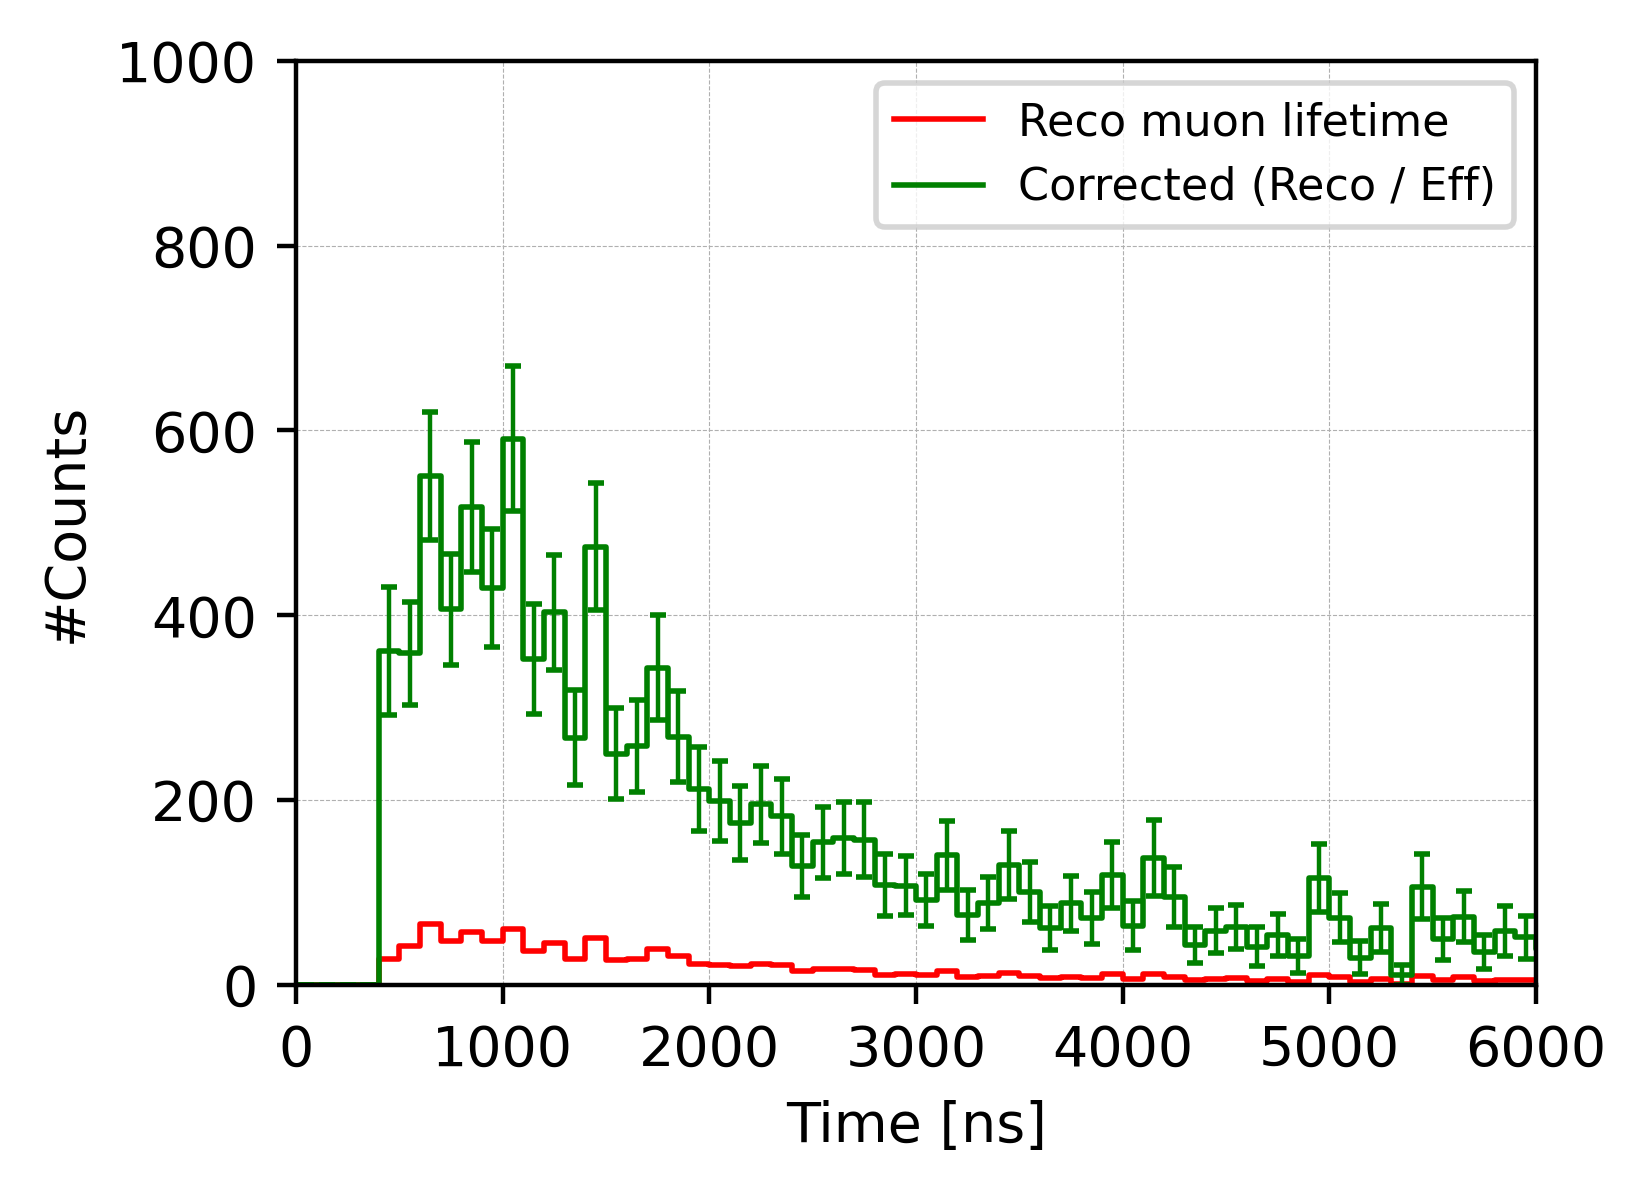

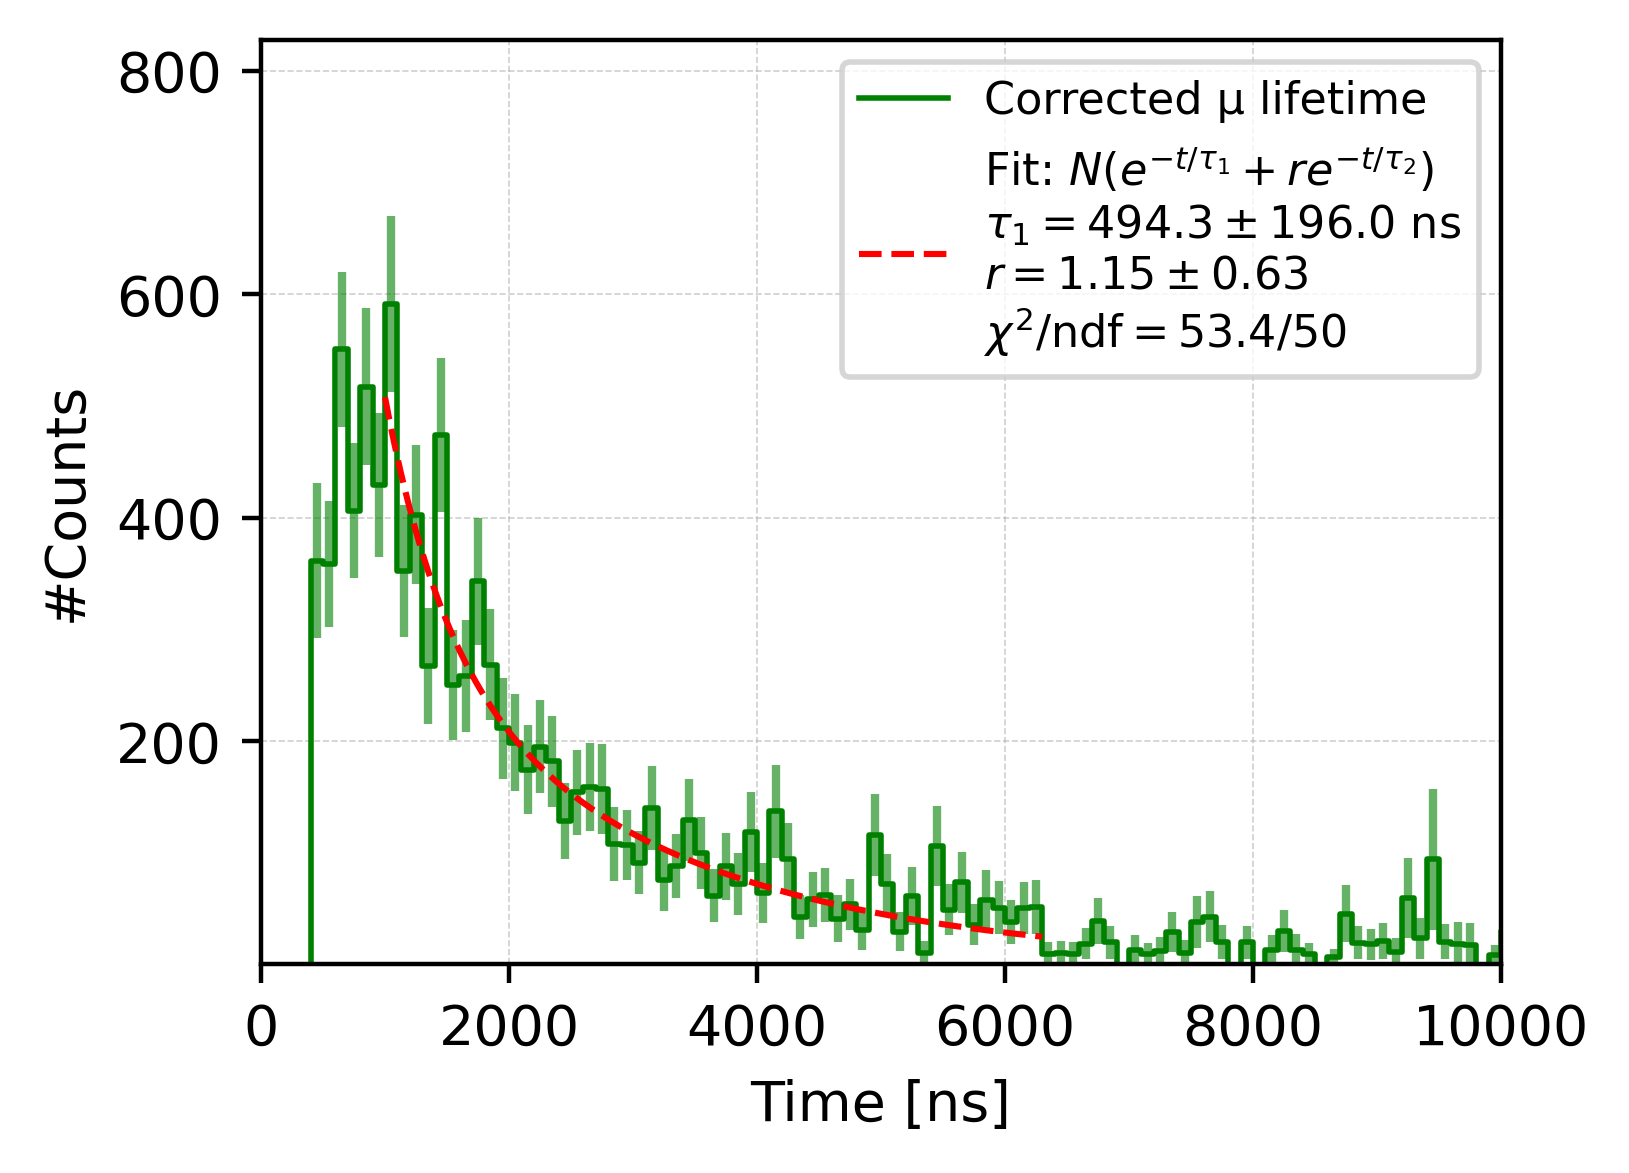


Fit summary:
N: (8455.03437194968, 4861.045422345407)
tau1: (494.2573625599896, 195.95657153974406)
ratio: (1.1544814079606098, 0.6262775267247389)
tau2: 2197.0
chi2: 53.37623723771057
ndf: 50
chi2_ndf: 1.0675247447542113


In [26]:
# --------------------------------------------------------------
# 1. Plot raw vs corrected histogram (your existing code)
# --------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

plt.step(bins, np.append(counts_reco, counts_reco[-1]),
         where='post', color='red', lw=1.0, label='Reco muon lifetime')

plt.step(bins, np.append(R_corr, R_corr[-1]),
         where='post', color='green', lw=1.0, label='Corrected (Reco / Eff)')

plt.errorbar(centers, R_corr, sigma_R_corr,
             fmt='none', ecolor='green', lw=0.8, capsize=1.5)

plt.xlim(0, 6000)
plt.ylim(0.0, 1000)
#plt.yscale("log")
plt.xlabel("Time [ns]")
plt.ylabel("#Counts")
plt.grid(ls='--', lw=0.2)
plt.legend(fontsize=8)
plt.show()


# --------------------------------------------------------------
# 2. Perform least-squares fit to corrected spectrum
# --------------------------------------------------------------
results = fit_double_exp(
    bin_edges=bins,
    y=R_corr,
    yerr=sigma_R_corr,
    fit_range=(1000, 6300),   # adjust as needed
    tau2=2197.0
)

print("\nFit summary:")
for key, val in results.items():
    print(f"{key}: {val}")


<br />
<br />

### Apply new fitting function  (physics-motivated):


Fit results:
  N⁺        = 9439 ± 1470
  τ(μ⁻)     = 971.8 ± 427.0 ns
  χ²/ndf    = 67.2/61 = 1.10


/var/folders/c9/547_2pf11mv74b226lzvqwj00000gn/T/ipykernel_99007/985882190.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


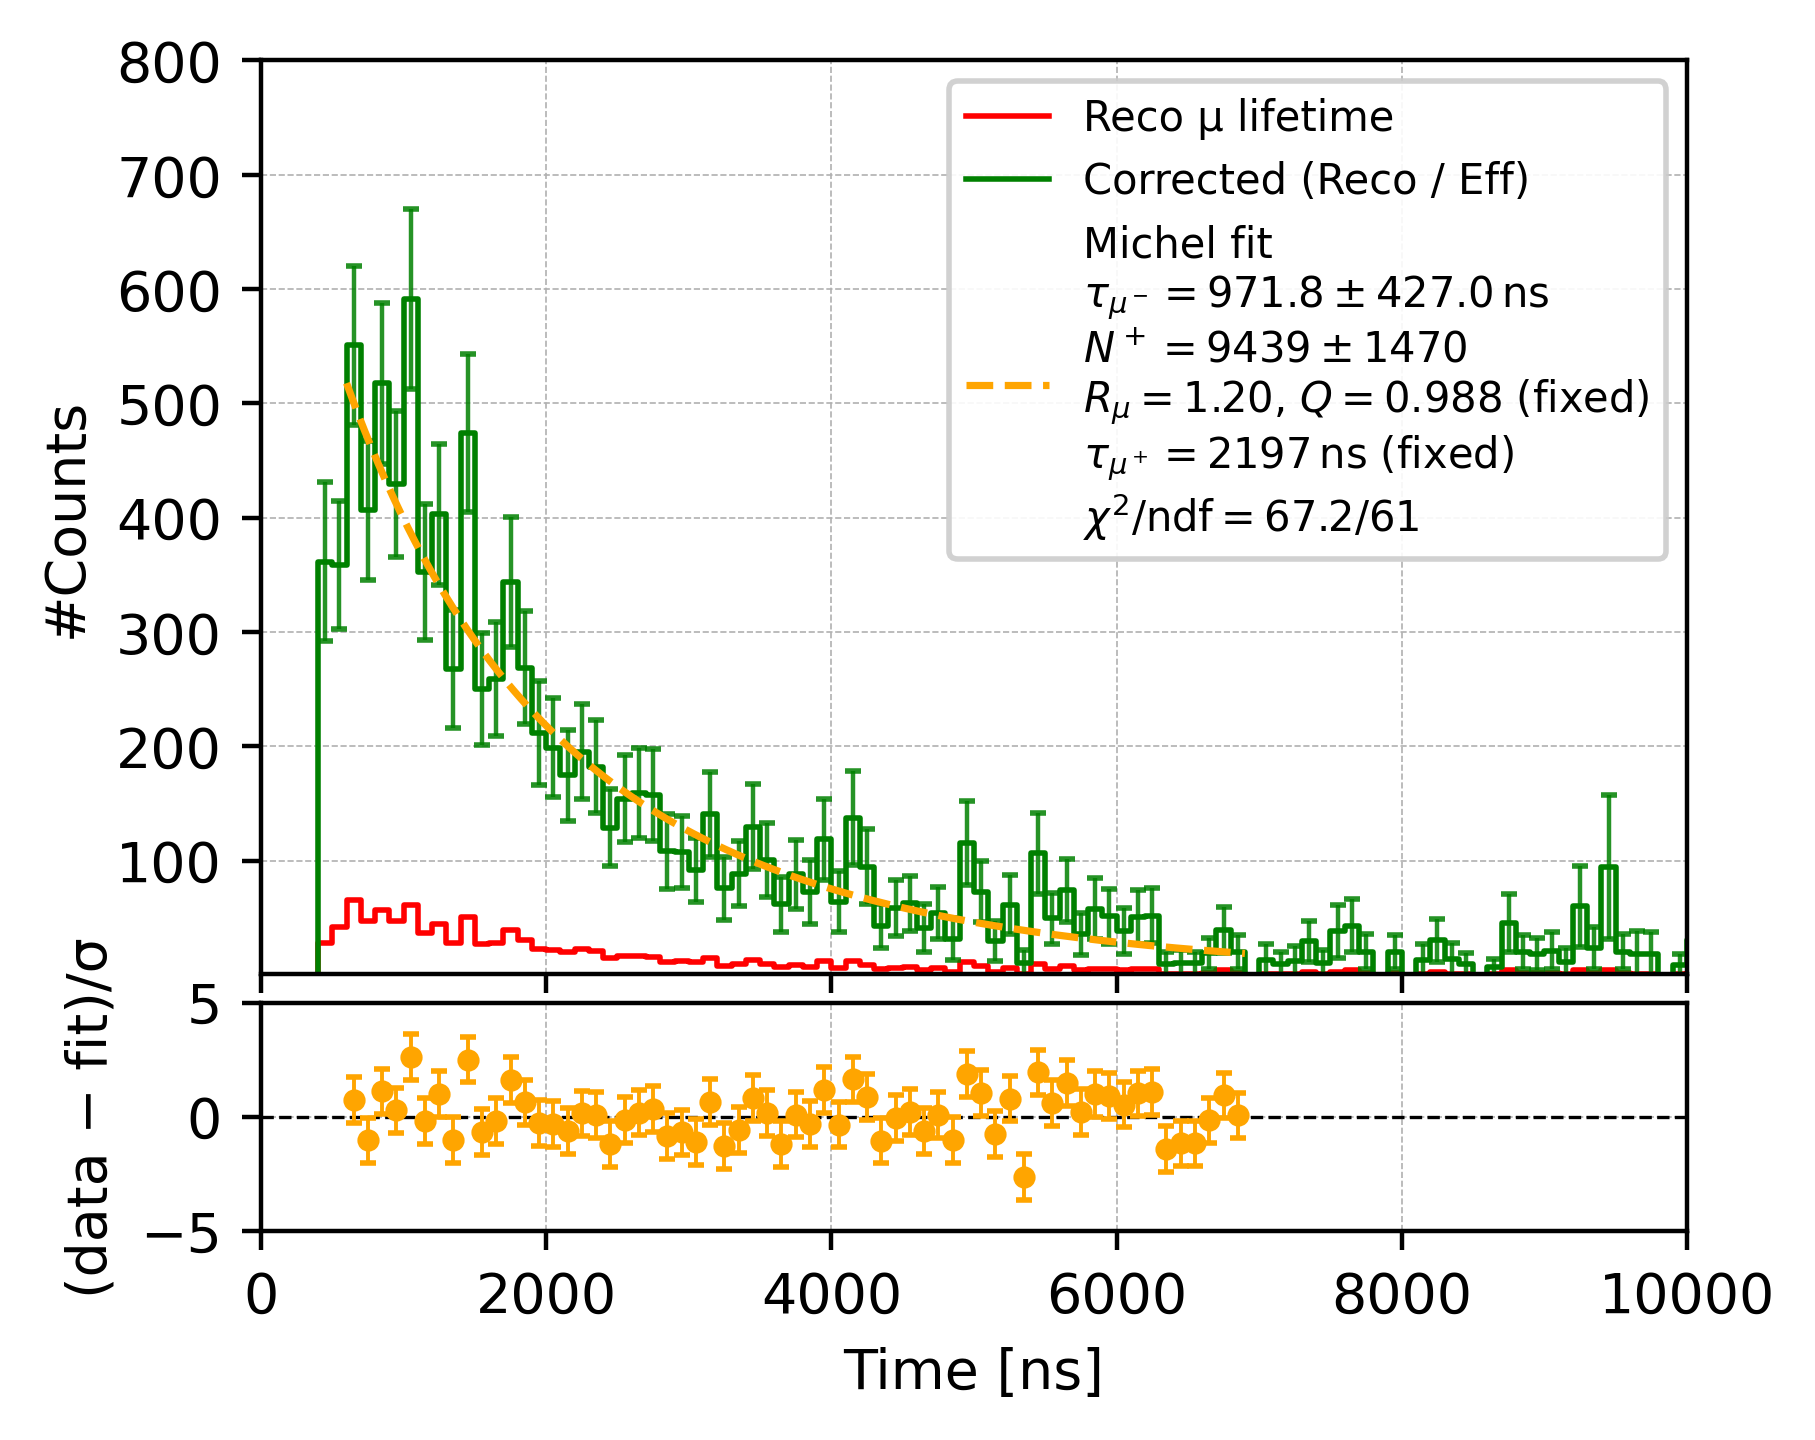

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Physics constants (FIXED)
# ============================================================
tau_mu_plus = 2197.0   # ns
Q = 0.988
R_mu = 1.2

# ============================================================
# Integrated Michel model (bin-integrated)
# ============================================================
def michel_integrated(bin_edges, N_plus, tau_mu_minus):
    """
    Bin-integrated Michel lifetime model.

    Returns expected counts per bin.
    """
    a = bin_edges[:-1]
    b = bin_edges[1:]

    term_plus  = np.exp(-a / tau_mu_plus)  - np.exp(-b / tau_mu_plus)
    term_minus = np.exp(-a / tau_mu_minus) - np.exp(-b / tau_mu_minus)

    prefactor = (Q * tau_mu_minus) / (R_mu * tau_mu_plus)

    return N_plus * (term_plus + prefactor * term_minus)

# ============================================================
# Inputs assumed to exist from previous notebook cells
# ============================================================
# bins            : bin edges (length N+1)
# centers         : bin centers (length N)
# counts_reco     : reco histogram
# R_corr          : efficiency-corrected histogram
# sigma_R_corr    : uncertainties on R_corr

# ============================================================
# 1. Define CONTIGUOUS fit window (critical!)
# ============================================================
fit_range = (600, 6900)  # ns===============================================================

mask_window = (
    (centers >= fit_range[0]) &
    (centers <= fit_range[1])
)

idx = np.where(mask_window)[0]
if len(idx) < 2:
    raise RuntimeError("Fit window too small or empty.")

i0, i1 = idx[0], idx[-1]

# Slice CONTIGUOUS bins
edges_fit = bins[i0 : i1 + 2]         # N+1
y_fit     = R_corr[i0 : i1 + 1]        # N
sigma_fit = sigma_R_corr[i0 : i1 + 1]  # N

# Safety check (now always true)
assert len(edges_fit) == len(y_fit) + 1

# Down-weight invalid bins instead of removing them
valid = (y_fit > 0) & np.isfinite(y_fit)
sigma_fit = np.where(valid, sigma_fit, 1e9)

# ============================================================
# 2. Perform χ² fit
# ============================================================
N0 = np.sum(y_fit[valid])
tau_minus_0 = 600.0  # ns

popt, pcov = curve_fit(
    michel_integrated,
    edges_fit, y_fit,
    p0=[N0, tau_minus_0],
    sigma=sigma_fit,
    absolute_sigma=True,
    bounds=([0.0, 50.0], [np.inf, 3000.0])
)

N_fit, tau_mu_minus_fit = popt
N_err, tau_mu_minus_err = np.sqrt(np.diag(pcov))

# χ² / ndf
y_model_fit = michel_integrated(edges_fit, *popt)
chi2 = np.sum(((y_fit - y_model_fit) / sigma_fit) ** 2)
ndf  = len(y_fit) - len(popt)

print("\nFit results:")
print(f"  N⁺        = {N_fit:.0f} ± {N_err:.0f}")
print(f"  τ(μ⁻)     = {tau_mu_minus_fit:.1f} ± {tau_mu_minus_err:.1f} ns")
print(f"  χ²/ndf    = {chi2:.1f}/{ndf} = {chi2/ndf:.2f}")

# ============================================================
# 3. Plot: data + fit + residuals
# ============================================================
fig, (ax, ax_resid) = plt.subplots(
    2, 1, figsize=(4.6, 3.8), dpi=400,
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05},
    sharex=True
)

# ------------------------------------------------------------
# Main panel
# ------------------------------------------------------------
ax.step(
    bins, np.append(counts_reco, counts_reco[-1]),
    where='post', color='red', lw=1.0,
    label='Reco μ lifetime'
)

ax.step(
    bins, np.append(R_corr, R_corr[-1]),
    where='post', color='green', lw=1.0,
    label='Corrected (Reco / Eff)'
)

ax.errorbar(
    centers, R_corr, yerr=sigma_R_corr,
    fmt='none', ecolor='green',
    elinewidth=0.8, capsize=1.5, alpha=0.85
)

# Smooth fitted curve (visual only)
bin_width = bins[1] - bins[0]
x_smooth = np.linspace(fit_range[0], fit_range[1], 600)

y_smooth = (
    (N_fit / tau_mu_plus) * np.exp(-x_smooth / tau_mu_plus)
    + (N_fit * Q / (R_mu * tau_mu_plus)) * np.exp(-x_smooth / tau_mu_minus_fit)
) * bin_width

ax.plot(
    x_smooth, y_smooth,
    color='orange', ls='--', lw=1.3,
    label=(
        r"Michel fit" "\n"
        + rf"$\tau_{{\mu^-}} = {tau_mu_minus_fit:.1f} \pm {tau_mu_minus_err:.1f}\,\mathrm{{ns}}$" "\n"
        + rf"$N^+ = {N_fit:.0f} \pm {N_err:.0f}$" "\n"
        + rf"$R_\mu = {R_mu:.2f}$, $Q = {Q:.3f}$ (fixed)" "\n"
        + rf"$\tau_{{\mu^+}} = {tau_mu_plus:.0f}\,\mathrm{{ns}}$ (fixed)" "\n"
        + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$"
    )
)

#ax.set_yscale('log')
ax.set_ylim(0.9, 800)
ax.set_ylabel('#Counts')
ax.set_xlim(0.0, 10000)
ax.grid(ls='--', lw=0.3)
ax.legend(fontsize=7.5, framealpha=0.9)

# ------------------------------------------------------------
# Residuals panel (ONLY fit region)
# ------------------------------------------------------------
pulls = (y_fit - y_model_fit) / sigma_fit

ax_resid.axhline(0, color='black', lw=0.6, ls='--')
ax_resid.errorbar(
    centers[i0 : i1 + 1], pulls,
    yerr=np.ones_like(pulls),
    fmt='o', color='orange',
    markersize=3, elinewidth=0.7, capsize=1.5
)

ax_resid.set_xlabel('Time [ns]')
ax_resid.set_ylabel('(data − fit)/σ')
ax_resid.set_ylim(-5, 5)
ax_resid.grid(ls='--', lw=0.3)

plt.tight_layout()
plt.show()


<br />
<br />
<br />
<br />

### Comparison of different measurements:

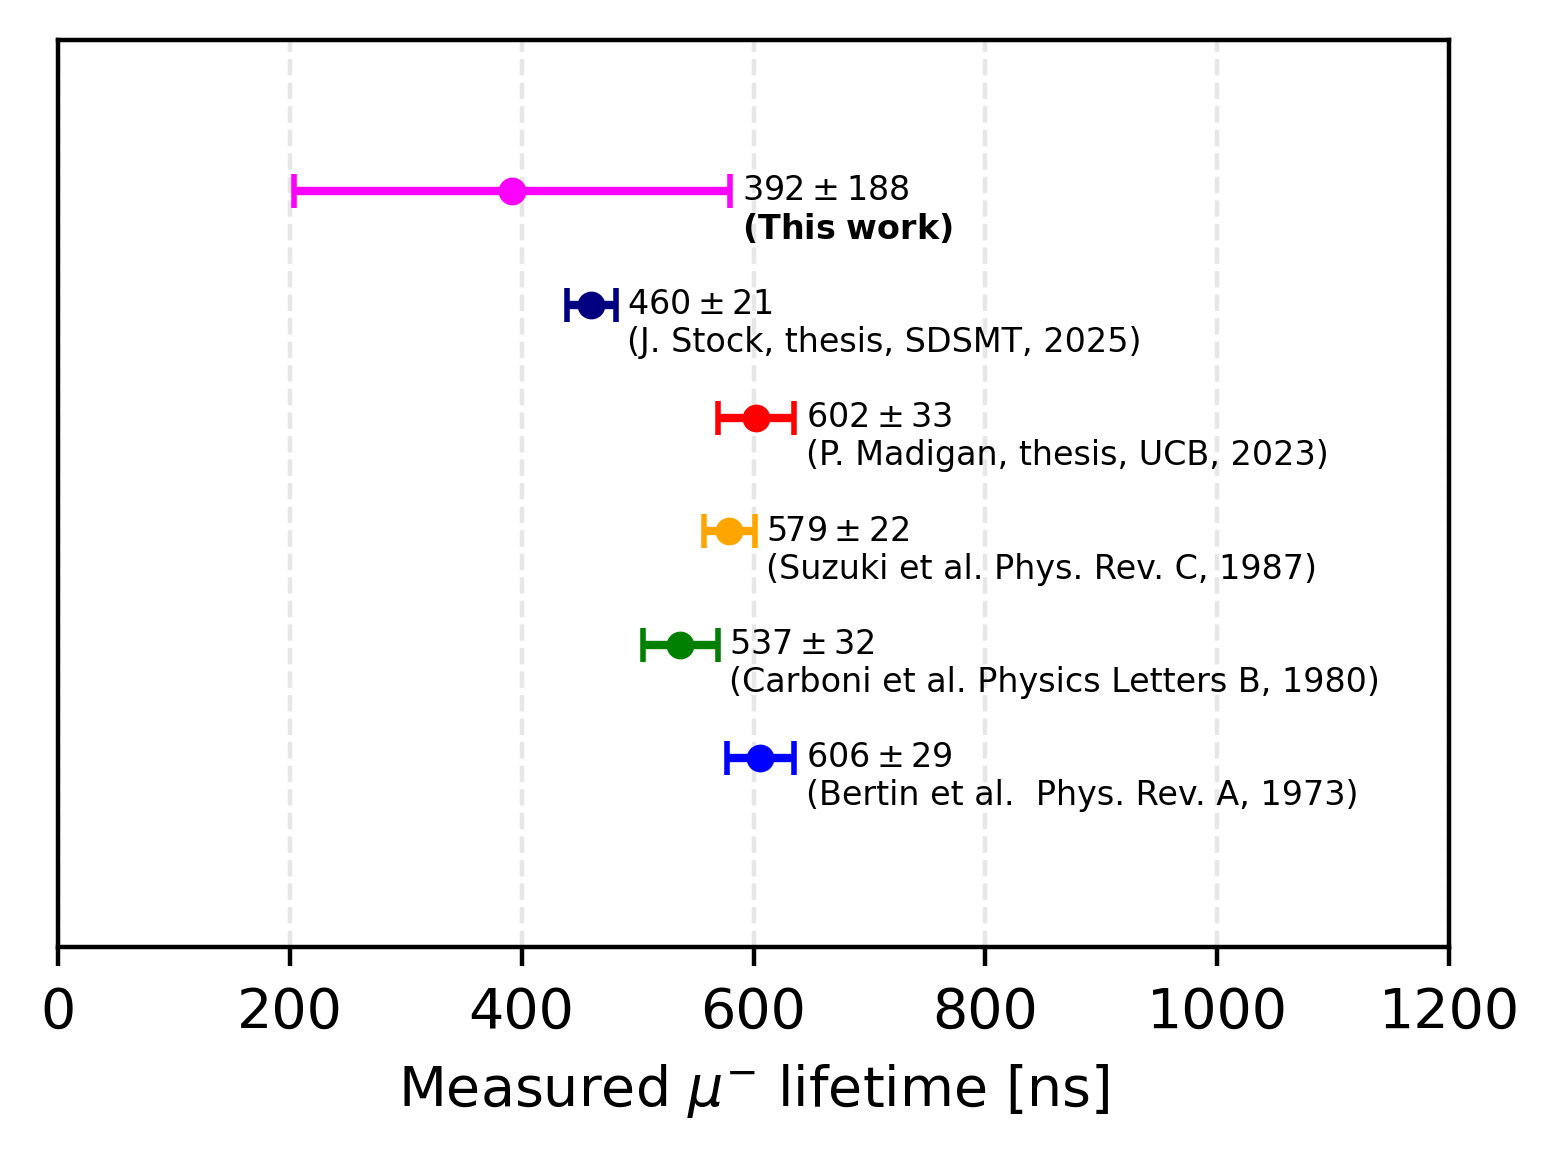

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Measurements
# -----------------------

values = np.array([606, 537, 579, 602, 460, 392])
errors = np.array([29, 32, 22, 33, 21, 188])

y_positions = np.array([0.5, 2, 3.5, 5, 6.5, 8])

labels = [
    "$606 \\pm 29$\n(Bertin et al.  Phys. Rev. A, 1973)",
    "$537 \\pm 32$\n(Carboni et al. Physics Letters B, 1980)",
    "$579 \\pm 22$\n(Suzuki et al. Phys. Rev. C, 1987)",
    "$602 \\pm 33$\n(P. Madigan, thesis, UCB, 2023)",
    "$460 \\pm 21$\n(J. Stock, thesis, SDSMT, 2025)",
    
    "$392 \\pm 188$\n$\\mathbf{(This\ work)}$"
]


# Point colors
point_colors = ["blue", "green", "orange", "red", "navy", "magenta"]

# (dx, dy) offsets for each label
label_offsets = [
    (39, -0.25),
    (42, -0.25),
    (32, -0.25),
    (43, -0.25),
    (31, -0.25),
    (198, -0.25)
]

plt.figure(figsize=(4, 3), dpi=400)

for val, err, y, lab, col, (dx, dy) in zip(values, errors, y_positions, labels, point_colors, label_offsets):
    
    plt.errorbar(
        val, y, xerr=err,
        fmt='o', color=col,
        ecolor=col, capsize=3, markersize=4
    )
    
    # Multi-line label + size control
    plt.text(
        val + dx, y + dy,
        lab,
        fontsize=6,         # <<< set label size here
        va='center'
    )

plt.xlabel(r"Measured $\mu^{-}$ lifetime [ns]")
plt.xlim(0, 1200)
plt.yticks([])
plt.ylim(-2, 10)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()
